# Demo 3: 使用 REFLECT 方法生成 AI2THOR 数据

本 demo 使用 REFLECT 框架的 `gen_data.py` 来生成 AI2THOR 模拟数据，确保生成的视频和数据与 REFLECT 框架保持一致。

## 特点

1. **使用 REFLECT 的稳定实现**: 直接调用 REFLECT 的 `run_data_gen` 函数
2. **任务定义与 REFLECT 一致**: 使用与 `reflect/main/tasks.json` 相同的任务配置格式
3. **数据保存位置**: 数据保存在 `craft/thor_tasks/` 目录下，参考 REFLECT 的目录结构
4. **支持两个示例任务**:
   - Task 1: makeCoffee (制作咖啡)
   - Task 2: boilWater (烧水)

## 目录结构

生成的数据将保存在:
```
craft/
└── thor_tasks/
    ├── makeCoffee/
    │   └── makeCoffee-1/
    │       ├── task.json          # 任务配置
    │       ├── events/            # AI2THOR events
    │       │   ├── step_1.pickle
    │       │   ├── step_2.pickle
    │       │   └── ...
    │       ├── ego_img/           # 图像帧
    │       │   ├── img_step_1.png
    │       │   ├── img_step_2.png
    │       │   └── ...
    │       ├── original-video.mp4 # 生成的视频
    │       ├── interact_actions.pickle
    │       └── nav_actions.pickle
    └── boilWater/
        └── boilWater-1/
            └── ... (相同结构)
```


In [2]:
"""
Demo 3: 使用 REFLECT 方法生成 AI2THOR 数据

本代码直接使用 REFLECT 框架的 gen_data.py 来生成数据，确保与 REFLECT 框架保持一致。
"""

import os
import sys
import json
from pathlib import Path
from typing import Dict, List

# 设置路径
CRAFT_ROOT = Path.cwd()
REFLECT_ROOT = CRAFT_ROOT.parent / "reflect"
REFLECT_MAIN_DIR = REFLECT_ROOT / "main"

print(f"CRAFT 根目录: {CRAFT_ROOT}")
print(f"REFLECT 根目录: {REFLECT_ROOT}")
print(f"REFLECT main 目录: {REFLECT_MAIN_DIR}")
print()

# 检查 REFLECT 是否可用
if not REFLECT_MAIN_DIR.exists():
    raise FileNotFoundError(
        f"REFLECT main 目录不存在: {REFLECT_MAIN_DIR}\n"
        "请确保 REFLECT 框架已安装或路径正确。"
    )

# 添加 REFLECT 路径到 sys.path
if str(REFLECT_MAIN_DIR) not in sys.path:
    sys.path.insert(0, str(REFLECT_MAIN_DIR))

# 导入 REFLECT 的模块
try:
    from gen_data import run_data_gen
    from constants import TASK_DICT as REFLECT_TASK_DICT
    print("✅ 成功导入 REFLECT 模块")
except ImportError as e:
    raise ImportError(
        f"无法导入 REFLECT 模块: {e}\n"
        "请确保 REFLECT 框架已正确安装。"
    )

print(f"✅ REFLECT TASK_DICT: {REFLECT_TASK_DICT}")
print()


CRAFT 根目录: /home/fdse/zzy/craft
REFLECT 根目录: /home/fdse/zzy/reflect
REFLECT main 目录: /home/fdse/zzy/reflect/main

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
✅ 成功导入 REFLECT 模块
✅ REFLECT TASK_DICT: {0: '', 1: 'boilWater', 2: 'toastBread', 3: 'cookEgg', 4: 'heatPotato', 5: 'makeCoffee', 6: 'waterPlant', 7: 'storeEgg', 8: 'makeSalad', 9: 'switchDevices', 10: 'warmWater'}



## 任务定义

定义两个示例任务，与 `reflect/main/tasks.json` 中的 Task 1 和 Task 2 保持一致：


In [3]:
# 任务定义 - 与 reflect/main/tasks.json 保持一致
# Task 1: makeCoffee (制作咖啡)
task_makeCoffee = {
    "name": "make coffee",
    "task_idx": 5,  # makeCoffee 的索引
    "num_samples": 1,
    "failure_injection": False,
    "folder_name": "makeCoffee-1",
    "scene": "FloorPlan16",
    "chosen_failure": "occupied",
    "gt_failure_reason": "The robot failed to put the mug inside the coffee machine because there was already a cup inside it, occupying the space.",
    "gt_failure_step": "00:51",
    "preactions": [
        "(dirty_obj, Mug)"
    ],
    "failure_injection_params": {
        "src_obj_type": "Cup",
        "target_obj_type": "CoffeeMachine",
        "disp_x": 0.0,
        "disp_z": 0.05,
        "disp_y": 0.02
    },
    "actions": [
        "(navigate_to_obj, Mug)",
        "(pick_up, Mug)",
        "(navigate_to_obj, Sink)",
        "(put_on, Mug, SinkBasin)",
        "(toggle_on, Faucet)",
        "(toggle_off, Faucet)",
        "(pick_up, Mug)",
        "(pour, Mug, Sink)",
        "(navigate_to_obj, CoffeeMachine)",
        "(put_in, Mug, CoffeeMachine)",
        "(toggle_on, CoffeeMachine)",
        "(toggle_off, CoffeeMachine)",
        "(pick_up, Mug)",
        "(put_on, Mug, CounterTop)"
    ],
    "success_condition": "a clean mug is filled with coffee and on top of the countertop."
}

# Task 2: boilWater (烧水)
task_boilWater = {
    "name": "boil water",
    "task_idx": 1,  # boilWater 的索引
    "num_samples": 1,
    "failure_injection": False,
    "folder_name": "boilWater-1",
    "scene": "FloorPlan1",
    "gt_failure_reason": "The robot did not pick up the pot from sink before moving to stove burner.",
    "gt_failure_step": [["00:31", "00:41"]],
    "actions": [
        "(navigate_to_obj, Pot)",
        "(pick_up, Pot)",
        "(navigate_to_obj, Sink)",
        "(put_in, Pot, Sink)",
        "(toggle_on, Faucet)",
        "(toggle_off, Faucet)",
        "(navigate_to_obj, StoveBurner-4)",
        "(put_on, Pot, StoveBurner-4)",
        "(toggle_on, StoveBurner-4)"
    ],
    "success_condition": "a pot is filled with water, the pot is on top of a stove burner that is turned on."
}

print("📋 任务定义:")
print(f"  Task 1: {task_makeCoffee['name']} (task_idx={task_makeCoffee['task_idx']}, folder={task_makeCoffee['folder_name']})")
print(f"  Task 2: {task_boilWater['name']} (task_idx={task_boilWater['task_idx']}, folder={task_boilWater['folder_name']})")
print()


📋 任务定义:
  Task 1: make coffee (task_idx=5, folder=makeCoffee-1)
  Task 2: boil water (task_idx=1, folder=boilWater-1)



## 数据生成函数

创建一个函数来使用 REFLECT 的方法生成数据，并确保数据保存在 craft 框架的目录下。


In [4]:
def generate_data_with_reflect(task: Dict, craft_root: Path = None) -> Dict:
    """
    使用 REFLECT 的 run_data_gen 生成 AI2THOR 数据
    
    Args:
        task: 任务配置字典（REFLECT 格式）
        craft_root: CRAFT 框架根目录，默认为当前目录
    
    Returns:
        包含生成数据信息的字典
    """
    import pickle
    import numpy as np
    
    if craft_root is None:
        craft_root = Path.cwd()
    
    print(f"\n{'='*80}")
    print(f"生成任务数据: {task['name']} (folder: {task['folder_name']})")
    print(f"{'='*80}")
    
    # 获取任务对应的目录名（从 TASK_DICT）
    task_name = REFLECT_TASK_DICT.get(task['task_idx'], 'unknown_task')
    print(f"任务名称: {task_name}")
    print(f"场景: {task['scene']}")
    print(f"动作数量: {len(task['actions'])}")
    print()
    
    # 切换到 CRAFT 根目录（REFLECT 的 run_data_gen 会在当前目录创建 thor_tasks）
    original_cwd = os.getcwd()
    try:
        os.chdir(str(craft_root))
        print(f"当前工作目录: {os.getcwd()}")
        
        # 调用 REFLECT 的 run_data_gen
        print("\\n[INFO] 调用 REFLECT 的 run_data_gen...")
        print("  这将使用 REFLECT 的稳定实现来生成数据")
        print("  数据将保存在: thor_tasks/{}/{}".format(task_name, task['folder_name']))
        print()
        
        # 运行数据生成
        run_data_gen(data_path=str(craft_root), task=task)
        
        print("\\n✅ REFLECT 数据生成完成！")
        
    finally:
        # 恢复原始工作目录
        os.chdir(original_cwd)
    
    # 构建数据路径
    data_path = craft_root / "thor_tasks" / task_name / task['folder_name']
    
    # 检查生成的文件
    task_json_path = data_path / "task.json"
    video_path = data_path / "original-video.mp4"
    events_dir = data_path / "events"
    ego_img_dir = data_path / "ego_img"
    
    result = {
        "task_name": task_name,
        "folder_name": task['folder_name'],
        "data_path": str(data_path),
        "task_json_path": str(task_json_path),
        "video_path": str(video_path),
        "events_dir": str(events_dir),
        "ego_img_dir": str(ego_img_dir),
        "success": False
    }
    
    # 验证生成的文件
    if task_json_path.exists():
        print(f"\\n✅ task.json 已生成: {task_json_path}")
        result["success"] = True
        
        # 读取 task.json 查看生成的任务信息
        with open(task_json_path, 'r') as f:
            generated_task = json.load(f)
            print(f"   生成的 specific_folder_name: {generated_task.get('specific_folder_name', 'N/A')}")
    else:
        print(f"\\n⚠️  task.json 未找到: {task_json_path}")
    
    if video_path.exists():
        video_size = video_path.stat().st_size / (1024 * 1024)  # MB
        print(f"✅ 视频已生成: {video_path} ({video_size:.2f} MB)")
    else:
        print(f"⚠️  视频未找到: {video_path}")
    
    if events_dir.exists():
        event_files = list(events_dir.glob("*.pickle"))
        print(f"✅ Events 目录: {len(event_files)} 个事件文件")
    else:
        print(f"⚠️  Events 目录不存在: {events_dir}")
    
    if ego_img_dir.exists():
        img_files = list(ego_img_dir.glob("*.png"))
        print(f"✅ Ego images 目录: {len(img_files)} 个图像文件")
    else:
        print(f"⚠️  Ego images 目录不存在: {ego_img_dir}")
    
    print()
    
    return result


In [5]:
# # 选择要生成的任务
# # 可以设置为 "makeCoffee", "boilWater", 或 "both"
# TASK_TO_GENERATE = "boilWater"  # 修改这里来选择要生成的任务

# results = {}

# if TASK_TO_GENERATE in ["makeCoffee", "both"]:
#     print("\\n" + "="*80)
#     print("生成 Task 1: makeCoffee")
#     print("="*80)
#     result_makeCoffee = generate_data_with_reflect(task_makeCoffee, craft_root=CRAFT_ROOT)
#     results["makeCoffee"] = result_makeCoffee

# if TASK_TO_GENERATE in ["boilWater", "both"]:
#     print("\\n" + "="*80)
#     print("生成 Task 2: boilWater")
#     print("="*80)
#     result_boilWater = generate_data_with_reflect(task_boilWater, craft_root=CRAFT_ROOT)
#     results["boilWater"] = result_boilWater

# print("\\n" + "="*80)
# print("生成总结")
# print("="*80)
# for task_name, result in results.items():
#     status = "✅ 成功" if result.get("success", False) else "❌ 失败"
#     print(f"{task_name}: {status}")
#     if result.get("success"):
#         print(f"  数据路径: {result['data_path']}")
#         print(f"  视频路径: {result['video_path']}")
# print("="*80)


## 验证生成的数据

检查生成的数据是否正确，并显示一些统计信息。


In [6]:
# def verify_generated_data(result: Dict):
#     """验证生成的数据"""
#     from pathlib import Path
#     import re
    
#     data_path = Path(result['data_path'])
    
#     if not data_path.exists():
#         print(f"❌ 数据目录不存在: {data_path}")
#         return
    
#     print(f"\\n验证数据: {data_path.name}")
#     print("-" * 80)
    
#     # 检查 task.json
#     task_json_path = Path(result['task_json_path'])
#     if task_json_path.exists():
#         with open(task_json_path, 'r') as f:
#             task_info = json.load(f)
#         print(f"✅ task.json:")
#         print(f"   任务名称: {task_info.get('name', 'N/A')}")
#         print(f"   场景: {task_info.get('scene', 'N/A')}")
#         print(f"   动作数量: {len(task_info.get('actions', []))}")
#         print(f"   folder_name: {task_info.get('folder_name', 'N/A')}")
    
#     # 检查 events
#     events_dir = Path(result['events_dir'])
#     if events_dir.exists():
#         event_files = list(events_dir.glob("*.pickle"))
#         # 按文件名中的数字排序
#         def get_step_number(f):
#             match = re.search(r'step_(\d+)', f.stem)
#             return int(match.group(1)) if match else 0
#         event_files = sorted(event_files, key=get_step_number)
#         print(f"\\n✅ Events: {len(event_files)} 个文件")
#         if event_files:
#             print(f"   第一个: {event_files[0].name}")
#             print(f"   最后一个: {event_files[-1].name}")
    
#     # 检查 ego_img
#     ego_img_dir = Path(result['ego_img_dir'])
#     if ego_img_dir.exists():
#         img_files = list(ego_img_dir.glob("*.png"))
#         # 按文件名中的数字排序
#         def get_img_step_number(f):
#             match = re.search(r'img_step_(\d+)', f.stem)
#             return int(match.group(1)) if match else 0
#         img_files = sorted(img_files, key=get_img_step_number)
#         print(f"\\n✅ Ego Images: {len(img_files)} 个文件")
#         if img_files:
#             print(f"   第一个: {img_files[0].name}")
#             print(f"   最后一个: {img_files[-1].name}")
    
#     # 检查视频
#     video_path = Path(result['video_path'])
#     if video_path.exists():
#         video_size_mb = video_path.stat().st_size / (1024 * 1024)
#         print(f"\\n✅ Video: {video_path.name} ({video_size_mb:.2f} MB)")
#     else:
#         print(f"\\n⚠️  Video 不存在: {video_path}")
    
#     print()

# # 验证所有生成的数据
# for task_name, result in results.items():
#     if result.get("success", False):
#         verify_generated_data(result)


## 数据路径总结

生成的数据保存在以下位置，可以在后续的 CRAFT 框架中使用：


In [7]:
# print("\\n" + "="*80)
# print("数据路径总结")
# print("="*80)
# print()
# print("生成的数据已保存在 CRAFT 框架的 thor_tasks 目录下：")
# print()
# for task_name, result in results.items():
#     if result.get("success", False):
#         print(f"{task_name}:")
#         print(f"  完整路径: {result['data_path']}")
#         print(f"  相对路径: thor_tasks/{result['task_name']}/{result['folder_name']}")
#         print()

# print("\\n可以在后续代码中使用这些路径来加载数据。")
# print("="*80)


---

# CRAFT 框架完整流程执行

基于 Method.md 的框架思想，对生成的 makeCoffee 和 boilWater 任务执行完整的 CRAFT 失败检测流程。

## 流程概述

1. **数据加载** - 从生成的数据中加载 events 和任务信息
2. **场景图生成** - 构建结构化场景表示（Method.md Section 1）
3. **约束生成** - LLM 生成逻辑约束（Method.md Section 2）
4. **约束编译** - 编译为可执行 AST/DSL（Method.md Section 2.2）
5. **失败检测** - 使用可执行逻辑验证约束（Method.md Section 4）
6. **结果可视化** - 展示检测结果和关键信息


In [8]:
# 检查 CRAFT 模块是否可用
# 首先确保父目录在 sys.path 中，这样 Python 才能找到 craft 包
import sys
from pathlib import Path

# 添加父目录到 sys.path（如果还没有添加）
parent_dir = Path.cwd().parent
parent_dir_str = str(parent_dir)
if parent_dir_str not in sys.path:
    sys.path.insert(0, parent_dir_str)
    print(f"✅ 已添加父目录到路径: {parent_dir_str}")

# 尝试多种导入策略
CRAFT_AVAILABLE = False
import importlib

try:
    # 策略 1: 从 craft 包导入（需要父目录在 sys.path）
    # 正确的方式：直接使用 from import 语法，这是推荐的 Python 导入方式
    # 注意：使用 from craft.core.scene_graph import 而不是 import craft.core.scene_graph
    # 因为 craft 模块的 __init__.py 使用相对导入，不直接暴露 core 属性
    from craft.core.scene_graph import SceneGraph, Node, Edge
    from craft.reasoning import LLMPrompter
    # 可选：如果需要重新加载模块（用于开发时的热重载）
    if 'craft.core.scene_graph' in sys.modules:
        importlib.reload(sys.modules['craft.core.scene_graph'])
        from craft.core.scene_graph import SceneGraph, Node, Edge  # 重新导入
    CRAFT_AVAILABLE = True
    print("✅ CRAFT 模块导入成功 (策略1: craft包)")
except (ImportError, AttributeError) as e1:
    try:
        # 策略 2: 直接导入子模块（当前目录就是 craft）
        import core.scene_graph
        importlib.reload(core.scene_graph)  # 重新加载以确保使用最新版本
        from core.scene_graph import SceneGraph, Node, Edge
        from reasoning.llm_prompter import LLMPrompter
        CRAFT_AVAILABLE = True
        print("✅ CRAFT 模块导入成功 (策略2: 直接导入子模块)")
    except ImportError as e2:
        CRAFT_AVAILABLE = False
        print(f"⚠️  CRAFT 模块导入失败")
        print(f"   策略1错误: {e1}")
        print(f"   策略2错误: {e2}")
        SceneGraph = None
        Node = None
        Edge = None
        LLMPrompter = None

print()

# LLM API 配置
# 设置开关：True 使用 GPT-4 + 新 API Key，False 使用原本的 GPT-3.5 方案
USE_GPT4 = True  # <--- 修改这里来切换方案

if USE_GPT4:
    GPT_VERSION = "gpt-4"
    API_KEY = "sk-UQFLOuq6vZEiBEeNVSRiRkgNErTitcdVQjAMwrlH08f870H2"
    POLOAPI_BASE_URL = "https://poloai.top/v1"
    print("🌟 使用方案: GPT-4 + 新 API Key")
else:
    GPT_VERSION = "gpt-3.5-turbo"
    API_KEY = "sk-wJJVkr6BUx8LruNeHNUCdmE1ARiB4qpLcdHHr3p4zVZTt8Fr"
    POLOAPI_BASE_URL = "https://poloai.top/v1"
    print("🔹 使用方案: 原本的 GPT-3.5 方案")
print("="*80)
print("CRAFT 框架初始化")
print("="*80)
print(f"CRAFT 模块可用: {'✅' if CRAFT_AVAILABLE else '❌'}")
print()

# 初始化 LLM Prompter
if CRAFT_AVAILABLE:
    try:
        llm_prompter = LLMPrompter(
            gpt_version=GPT_VERSION,
            api_key=API_KEY,
            base_url=POLOAPI_BASE_URL
        )
        print(f"✅ LLM Prompter ({GPT_VERSION}) 初始化成功")
    except Exception as e:
        print(f"⚠️  LLM Prompter 初始化失败: {e}")
        llm_prompter = None
else:
    llm_prompter = None

print()


✅ 已添加父目录到路径: /home/fdse/zzy
✅ CRAFT 模块导入成功 (策略1: craft包)

🌟 使用方案: GPT-4 + 新 API Key
CRAFT 框架初始化
CRAFT 模块可用: ✅

✅ LLM Prompter (gpt-4) 初始化成功



## Step 1: 数据加载

从生成的数据中加载 events 和任务信息。


In [9]:
import pickle

def load_task_data(data_path: str) -> Dict:
    """
    从生成的数据目录加载任务数据
    
    Returns:
        包含 events, task_info, action_results 的字典
    """
    data_dir = Path(data_path)
    
    # 加载 task.json
    task_json_path = data_dir / "task.json"
    if not task_json_path.exists():
        raise FileNotFoundError(f"task.json not found: {task_json_path}")
    
    with open(task_json_path, 'r') as f:
        task_info = json.load(f)
    
    # 加载 events
    events_dir = data_dir / "events"
    events = []
    if events_dir.exists():
        event_files = sorted(events_dir.glob("*.pickle"), 
                           key=lambda x: int(x.stem.split('_')[1]))
        for event_file in event_files:
            with open(event_file, 'rb') as f:
                events.append(pickle.load(f))
        print(f"✅ 加载了 {len(events)} 个 events")
    else:
        print(f"⚠️  Events 目录不存在: {events_dir}")
    
    # 构建 action_results
    action_results = []
    actions = task_info.get('actions', [])
    for i, action_str in enumerate(actions):
        action_results.append({
            'action': action_str,
            'status': 'SUCCESS',
            'step': i + 1
        })
    
    return {
        'events': events,
        'task_info': task_info,
        'action_results': action_results,
        'data_path': str(data_dir)
    }

# 加载 makeCoffee 和 boilWater 的数据
print("="*80)
print("Step 1: 数据加载")
print("="*80)

# 从之前生成的数据中加载
makeCoffee_data_path = CRAFT_ROOT / "thor_tasks" / "makeCoffee" / "makeCoffee-1"
boilWater_data_path = CRAFT_ROOT / "thor_tasks" / "boilWater" / "boilWater-1"

task_data = {}

if makeCoffee_data_path.exists():
    print(f"\n📂 加载 makeCoffee 数据: {makeCoffee_data_path}")
    task_data['makeCoffee'] = load_task_data(str(makeCoffee_data_path))
    print(f"   任务: {task_data['makeCoffee']['task_info'].get('name', 'N/A')}")
    print(f"   场景: {task_data['makeCoffee']['task_info'].get('scene', 'N/A')}")
    print(f"   动作数: {len(task_data['makeCoffee']['action_results'])}")
else:
    print(f"⚠️  makeCoffee 数据不存在: {makeCoffee_data_path}")

if boilWater_data_path.exists():
    print(f"\n📂 加载 boilWater 数据: {boilWater_data_path}")
    task_data['boilWater'] = load_task_data(str(boilWater_data_path))
    print(f"   任务: {task_data['boilWater']['task_info'].get('name', 'N/A')}")
    print(f"   场景: {task_data['boilWater']['task_info'].get('scene', 'N/A')}")
    print(f"   动作数: {len(task_data['boilWater']['action_results'])}")
else:
    print(f"⚠️  boilWater 数据不存在: {boilWater_data_path}")

print(f"\n✅ 数据加载完成！已加载 {len(task_data)} 个任务")


Step 1: 数据加载

📂 加载 makeCoffee 数据: /home/fdse/zzy/craft/thor_tasks/makeCoffee/makeCoffee-1
✅ 加载了 81 个 events
   任务: make coffee
   场景: FloorPlan16
   动作数: 14

📂 加载 boilWater 数据: /home/fdse/zzy/craft/thor_tasks/boilWater/boilWater-1
✅ 加载了 46 个 events
   任务: boil water
   场景: FloorPlan1
   动作数: 9

✅ 数据加载完成！已加载 2 个任务


## Step 2: 场景图生成

从 AI2THOR events 生成初始和最终场景图。


In [10]:
  import importlib
  import core.scene_graph
  importlib.reload(core.scene_graph)
  from core.scene_graph import SceneGraph, Node, Edge

In [11]:
from typing import Set, Tuple, Optional
import importlib
import sys
from craft.core.enhanced_scene_graph_utils import extract_composite_state, add_rich_spatial_relations
# 如果需要重新加载模块（用于开发时的热重载）
if 'craft.core.enhanced_scene_graph_utils' in sys.modules:
    importlib.reload(sys.modules['craft.core.enhanced_scene_graph_utils'])
    from craft.core.enhanced_scene_graph_utils import extract_composite_state, add_rich_spatial_relations  # 重新导入

def extract_task_relevant_objects(task_info: Dict) -> Set[str]:
    """
    从任务信息中提取与任务相关的对象名称
    
    Args:
        task_info: 任务信息字典，包含 actions 和 success_condition
    
    Returns:
        相关对象名称的集合
    """
    import re  # 将 import 移到函数开头
    relevant_objects = set()
    
    # 从 actions 中提取对象
    actions = task_info.get('actions', [])
    for action_str in actions:
        # 解析动作字符串，例如: "(pick_up, Mug)" 或 "(put_in, Mug, CoffeeMachine)"
        # 提取括号内的参数
        matches = re.findall(r'\(([^)]+)\)', action_str)
        for match in matches:
            parts = [p.strip() for p in match.split(',')]
            # 跳过第一个（动作类型），提取后面的对象名
            for obj_name in parts[1:]:
                if obj_name:
                    relevant_objects.add(obj_name)
    
    # 从 success_condition 中提取对象
    success_condition = task_info.get('success_condition', '')
    if success_condition:
        # 提取大写开头的单词（通常是对象名）
        obj_matches = re.findall(r'\b([A-Z][a-zA-Z]+)\b', success_condition)
        relevant_objects.update(obj_matches)
    
    # 从 preactions 中提取对象
    preactions = task_info.get('preactions', [])
    for preaction in preactions:
        matches = re.findall(r'\(([^)]+)\)', preaction)
        for match in matches:
            parts = [p.strip() for p in match.split(',')]
            for obj_name in parts[1:]:
                if obj_name:
                    relevant_objects.add(obj_name)
    
    return relevant_objects


def extract_task_relevant_subgraph(full_scene_graph: SceneGraph, task_info: Dict, 
                                   timestep: Optional[int] = None, 
                                   action: Optional[str] = None) -> SceneGraph:
    """
    使用闭包（closure）方法从完整场景图中裁剪出任务相关子图
    
    该方法使用 BFS 从任务相关对象开始，沿着 inside/on_top_of/supported_by 边扩展，
    确保包含所有相关的容器和支撑结构。
    
    Args:
        full_scene_graph: 完整的场景图
        task_info: 任务信息字典
        timestep: 时间步（用于 Action-aware SG）
        action: 动作（用于 Action-aware SG）
    
    Returns:
        裁剪后的子图，包含任务相关对象及其容器/支撑结构
    """
    # 使用新的闭包方法
    return full_scene_graph.extract_task_relevant_subgraph_with_closure(task_info)


def generate_scene_graph_from_event(event, task_info: Dict, 
                                    timestep: Optional[int] = None,
                                    action: Optional[str] = None) -> SceneGraph:
    """
    从 AI2THOR event 生成场景图
    """
    if not CRAFT_AVAILABLE:
        raise RuntimeError("CRAFT modules not available")
    
    # 创建 Action-aware Scene Graph
    sg = SceneGraph(task=task_info, timestep=timestep, action=action)
    
    # 从 event.metadata 中提取对象信息
    if hasattr(event, 'metadata') and event.metadata:
        objects = event.metadata.get('objects', [])
        
        for obj in objects:
            # 正确提取对象状态（根据对象类型）
            # 提取组合状态（支持多个状态，如 "filled with coffee and dirty"）
            state = extract_composite_state(obj)
            # 获取对象类型
            obj_type = obj.get('objectType', '')
            
            # 创建节点
            node = Node(
                name=obj.get('name', 'unknown'),
                object_type=obj_type,
                state=state,
                position=tuple(obj.get('position', {}).values()) if isinstance(obj.get('position'), dict) else None,
                attributes={
                    'isFilled': obj.get('isFilled', False),
                    'isOpen': obj.get('isOpen', False),
                    # isToggled: 优先使用 isToggledOn，回退到 isToggled，再检查 toggleable 属性
                    # AI2THOR 中，某些对象（如 Faucet）的 toggle 状态可能在不同的字段中
                    'isToggled': (
                        obj.get('isToggledOn', False) or 
                        obj.get('isToggled', False) or
                        (obj.get('toggleable', False) and obj.get('isOn', False)) or
                        obj.get('isOn', False)
                    ),
                    'isPickedUp': obj.get('isPickedUp', False),
                }
            )
            sg.add_node(node)
        
        # 添加关系边（需要在所有节点添加后再添加边）
        for obj in objects:
            node = sg.get_node(obj.get('name', 'unknown'))
            if not node:
                continue
            
            # 如果被拿起，创建与机器人的关系
            if obj.get('isPickedUp', False):
                robot_node = sg.get_node("Robot")
                if not robot_node:
                    robot_node = Node(name="Robot", object_type="Robot")
                    sg.add_node(robot_node)
                sg.add_edge(Edge(robot_node, node, "holding"))
            
            # 检查容器关系（parent-child relationships）
            if obj.get('parentReceptacles'):
                for parent_id in obj.get('parentReceptacles', []):
                    # 区分 inside vs on_top_of
                    for other_obj in objects:
                        if other_obj.get('objectId') == parent_id:
                            parent_node = sg.get_node(other_obj.get('name', 'unknown'))
                            if parent_node:
                                # 判断关系类型：容器类型用 inside，表面类型用 on_top_of
                                # 动态判断关系类型（基于对象的 receptacle 属性，不依赖写死的类型列表）
                                # 检查父容器是否有 receptacleObjectIds（表示它是容器）
                                has_receptacle = bool(other_obj.get('receptacleObjectIds') or 
                                                      other_obj.get('receptacleObjectIds', []))
                                # 检查父容器是否是可打开的容器（如 Fridge, Cabinet, Microwave）
                                is_openable_container = 'isOpen' in other_obj
                                # 检查父容器是否是表面类型（通常没有 receptacleObjectIds 或只有少量）
                                # CounterTop, Table 等表面类型通常 receptacleObjectIds 为空或很少
                                receptacle_count = len(other_obj.get('receptacleObjectIds', [])) if isinstance(other_obj.get('receptacleObjectIds'), list) else 0
                                container_type = other_obj.get('objectType', '')
                                
                                # 判断规则：
                                # 1. 如果是可打开的容器（Fridge, Cabinet等），使用 inside
                                # 2. 如果有 receptacleObjectIds 且数量较多，可能是容器，使用 inside
                                # 3. 否则，使用 on_top_of（表面类型）
                                if is_openable_container or (has_receptacle and receptacle_count > 0):
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                                else:
                                    # 表面类型（CounterTop, Table等）
                                    sg.add_edge(Edge(node, parent_node, "on_top_of"))
                                # 动态判断容器类型：通过 receptacleObjectIds 判断是否是容器
                                # 如果对象有 receptacleObjectIds，说明它是容器（可以容纳其他对象）
                                has_receptacle = bool(other_obj.get('receptacleObjectIds', []))
                                
                                # 判断关系类型：
                                # - 如果容器有 receptacleObjectIds，通常是真正的容器（inside）
                                # - 如果容器没有 receptacleObjectIds，通常是表面（on_top_of）
                                # 特殊情况：CounterTop, Table 等表面类型通常没有 receptacleObjectIds
                                container_type = other_obj.get('objectType', '')
                                container_type_lower = container_type.lower()
                                is_surface = ('countertop' in container_type_lower or 
                                            'table' in container_type_lower or
                                            'stoveburner' in container_type_lower)
                                
                                if has_receptacle and not is_surface:
                                    # 真正的容器（有 receptacleObjectIds 且不是表面）
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                                elif is_surface:
                                    # 表面类型（CounterTop, Table, StoveBurner）
                                    sg.add_edge(Edge(node, parent_node, "on_top_of"))
                                else:
                                    # 默认使用 inside（保守策略）
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                                    # 默认使用 inside（保守策略）
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                            break
        
        # 检查 on_top_of 关系（基于位置信息）
        # 对于每个对象，检查它是否在其他对象的上方
        # 注意：只检查不在容器内的对象（避免与 inside 关系冲突）
        for obj in objects:
            node = sg.get_node(obj.get('name', 'unknown'))
            if not node or not node.position:
                continue
            
            # 如果对象已经在容器内（有 parentReceptacles），跳过 on_top_of 检测
            if obj.get('parentReceptacles'):
                continue
            
            obj_pos = node.position
            obj_type = obj.get('objectType', '')
            
            # 检查是否在其他对象的上方
            for other_obj in objects:
                if obj.get('objectId') == other_obj.get('objectId'):
                    continue  # 禁止自环
                
                other_node = sg.get_node(other_obj.get('name', 'unknown'))
                if not other_node or not other_node.position:
                    continue
                
                other_pos = other_node.position
                other_type = other_obj.get('objectType', '')
                
                # 计算垂直高度差和水平距离
                z_diff = obj_pos[2] - other_pos[2]  # z 坐标差
                horizontal_dist = ((obj_pos[0] - other_pos[0])**2 + (obj_pos[1] - other_pos[1])**2)**0.5
                
                # 判断 on_top_of 关系（更严格的条件）：
                # 1. 垂直高度差 > 0.05m (5cm) 且 < 0.5m - 对象在上方但不太远
                # 2. 水平距离 < 0.2m (20cm) - 对象在附近（更严格）
                # 3. 下方对象是表面类型（精确匹配，避免误匹配）
                # 4. 对象不在容器内（已通过上面的检查）
                # 动态判断表面类型：通过对象类型特征判断，不依赖写死的列表
                def is_surface_type_dynamic(obj_type: str) -> bool:
                    """动态判断是否是表面类型（基于对象类型特征）"""
                    type_lower = obj_type.lower()
                    # 表面类型的特征：通常包含 top, table, burner, sink 等关键词
                    surface_keywords = ['countertop', 'table', 'stoveburner', 'burner', 'sink']
                    return any(kw in type_lower for kw in surface_keywords)
                
                is_surface = is_surface_type_dynamic(other_type)
                
                # 更严格的条件：高度差合理，水平距离小，且是表面类型
                if (0.05 < z_diff < 0.5 and horizontal_dist < 0.2 and is_surface):
                    # 再次检查是否已经有 inside 关系（双重保险）
                    existing_edge = sg.edges.get((node.name, other_node.name))
                    if not existing_edge or existing_edge.edge_type != 'inside':
                        sg.add_edge(Edge(node, other_node, "on_top_of"))
    
    
    # 添加丰富空间关系（above, below, blocking, left_of, right_of）
    if hasattr(event, 'metadata') and event.metadata:
        objects = event.metadata.get('objects', [])
        # 获取相机信息（用于相机空间计算）
        camera_world_xyz = None
        rotation = None
        horizon = None
        agent = event.metadata.get('agent', {})
        if agent:
            pos = agent.get('position', {})
            if pos:
                camera_world_xyz = (pos.get('x', 0), pos.get('y', 0), pos.get('z', 0))
            rotation = agent.get('rotation', {}).get('y', 0)
            horizon = agent.get('cameraHorizon', 0)
        
        # 添加丰富关系（use_point_cloud=False 表示使用位置信息而非点云）
        add_rich_spatial_relations(
            sg, objects,
            use_point_cloud=False,  # 如果有点云数据，可以设置为 True
            camera_world_xyz=camera_world_xyz,
            rotation=rotation,
            horizon=horizon
        )
    return sg


In [12]:
import importlib
import sys
from craft.core.enhanced_scene_graph_utils import extract_composite_state, add_rich_spatial_relations
# 如果需要重新加载模块（用于开发时的热重载）
if 'craft.core.enhanced_scene_graph_utils' in sys.modules:
    importlib.reload(sys.modules['craft.core.enhanced_scene_graph_utils'])
    from craft.core.enhanced_scene_graph_utils import extract_composite_state, add_rich_spatial_relations  # 重新导入
print("="*80)
print("Step 2: 场景图生成（Action-relevant）")
print("="*80)

# 导入 action-relevant 场景图函数
# 重新加载 scene_graph 以确保使用最新版本
# 正确的方式：使用 from import 语法，然后通过 sys.modules 重载
from craft.core.scene_graph import SceneGraph, Node, Edge
if 'craft.core.scene_graph' in sys.modules:
    importlib.reload(sys.modules['craft.core.scene_graph'])
    from craft.core.scene_graph import SceneGraph, Node, Edge  # 重新导入

# 重新加载 action_relevant_scene_graph（使用新的 SceneGraph）
from craft.core.action_relevant_scene_graph import extract_action_relevant_subgraph_with_closure
if 'craft.core.action_relevant_scene_graph' in sys.modules:
    importlib.reload(sys.modules['craft.core.action_relevant_scene_graph'])
    from craft.core.action_relevant_scene_graph import extract_action_relevant_subgraph_with_closure  # 重新导入
    # 如果需要更新模块中的引用，使用 sys.modules
    action_sg_module = sys.modules['craft.core.action_relevant_scene_graph']
    action_sg_module.SceneGraph = SceneGraph
    action_sg_module.Node = Node
    action_sg_module.Edge = Edge


# 为每个任务生成每一帧的 action-relevant 场景图
for task_name, data in task_data.items():
    print(f"\n📊 生成 {task_name} 的 Action-relevant 场景图...")
    
    events = data.get('events', [])
    task_info = data.get('task_info', {})
    actions = task_info.get('actions', [])
    
    if not events:
        print(f"   ⚠️  没有 events 数据，跳过")
        continue
    
    # 存储每一帧的 action-relevant 场景图
    action_relevant_sgs = []
    
    # 为每一帧生成 action-relevant 场景图
    print(f"   处理 {len(events)} 个事件，{len(actions)} 个动作...")
    
    for frame_idx, event in enumerate(events):
        # 获取当前帧对应的 action
        current_action = None
        if frame_idx < len(actions):
            current_action = actions[frame_idx]
        
        # 生成完整场景图
        full_sg = generate_scene_graph_from_event(event, task_info, timestep=frame_idx, action=current_action)
        
        # 使用 action-relevant 闭包裁剪（只保留与当前 action 相关的节点）
        if current_action:
            action_sg = extract_action_relevant_subgraph_with_closure(
                full_sg, 
                action_str=current_action,
                task_info=task_info
            )
        else:
            # 如果没有 action，使用任务相关的裁剪
            action_sg = extract_task_relevant_subgraph(full_sg, task_info, timestep=frame_idx, action=current_action)
        
        action_relevant_sgs.append(action_sg)
        
        # 输出当前帧的 action-relevant 场景图
        if current_action:
            print(f"\n   📝 Frame {frame_idx + 1}/{len(events)} - Action: {current_action}")
            print(f"      完整场景图: {len(full_sg.nodes)} 个节点, {len(full_sg.edges)} 条边")
            print(f"      Action-relevant: {len(action_sg.nodes)} 个节点, {len(action_sg.edges)} 条边")
            
            # 输出 action-relevant 场景图的文字描述
            try:
                action_text = action_sg.to_text()
                print(f"      场景描述: {action_text[:150]}..." if len(action_text) > 150 else f"      场景描述: {action_text}")
                
                # 输出节点列表
                if len(action_sg.nodes) > 0:
                    node_names = [node.get_name() for node in list(action_sg.nodes)[:5]]
                    node_names_str = ", ".join(node_names)
                    print(f"      📦 节点 ({len(action_sg.nodes)} 个): {node_names_str}")
                    if len(action_sg.nodes) > 5:
                        print(f"         ... 还有 {len(action_sg.nodes) - 5} 个节点")
                
                # 输出关系列表
                if len(action_sg.edges) > 0:
                    relations = []
                    for (start_name, end_name), edge in list(action_sg.edges.items())[:5]:
                        relations.append(f"{edge.start.get_name()} --[{edge.edge_type}]--> {edge.end.get_name()}")
                    relations_str = "; ".join(relations)
                    print(f"      🔗 关系 ({len(action_sg.edges)} 条): {relations_str}")
                    if len(action_sg.edges) > 5:
                        print(f"         ... 还有 {len(action_sg.edges) - 5} 条关系")
            except Exception as e:
                print(f"      ⚠️  生成文字描述时出错: {e}")
    
    # 保存初始和最终场景图（用于后续步骤）
    if len(action_relevant_sgs) > 0:
        data['initial_sg'] = action_relevant_sgs[0]
        data['final_sg'] = action_relevant_sgs[-1]
        data['action_relevant_sgs'] = action_relevant_sgs  # 保存所有帧的场景图
        task_data[task_name] = data

print("\n✅ Action-relevant 场景图生成完成！")


Step 2: 场景图生成（Action-relevant）

📊 生成 makeCoffee 的 Action-relevant 场景图...
   处理 81 个事件，14 个动作...

   📝 Frame 1/81 - Action: (navigate_to_obj, Mug)
      完整场景图: 90 个节点, 95 条边
      Action-relevant: 2 个节点, 2 条边
      场景描述: Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty), SinkBasin_d14683a7 (closed and turned off and empty and not s...
      📦 节点 (2 个): Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty), SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean)
      🔗 关系 (2 条): Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty) --[inside]--> SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean); SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean) --[left_of]--> Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty)



   📝 Frame 2/81 - Action: (pick_up, Mug)
      完整场景图: 90 个节点, 95 条边
      Action-relevant: 2 个节点, 2 条边
      场景描述: Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty), SinkBasin_d14683a7 (closed and turned off and empty and not s...
      📦 节点 (2 个): Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty), SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean)
      🔗 关系 (2 条): Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty) --[inside]--> SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean); SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean) --[left_of]--> Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty)

   📝 Frame 3/81 - Action: (navigate_to_obj, Sink)
      完整场景图: 90 个节点, 95 条边
      Action-relevant: 4 个节点, 5 条边
    

In [13]:
from typing import Set, Tuple, Optional

def extract_task_relevant_objects(task_info: Dict) -> Set[str]:
    """
    从任务信息中提取与任务相关的对象名称
    
    Args:
        task_info: 任务信息字典，包含 actions 和 success_condition
    
    Returns:
        相关对象名称的集合
    """
    import re  # 将 import 移到函数开头
    relevant_objects = set()
    
    # 从 actions 中提取对象
    actions = task_info.get('actions', [])
    for action_str in actions:
        # 解析动作字符串，例如: "(pick_up, Mug)" 或 "(put_in, Mug, CoffeeMachine)"
        # 提取括号内的参数
        matches = re.findall(r'\(([^)]+)\)', action_str)
        for match in matches:
            parts = [p.strip() for p in match.split(',')]
            # 跳过第一个（动作类型），提取后面的对象名
            for obj_name in parts[1:]:
                if obj_name:
                    relevant_objects.add(obj_name)
    
    # 从 success_condition 中提取对象
    success_condition = task_info.get('success_condition', '')
    if success_condition:
        # 提取大写开头的单词（通常是对象名）
        obj_matches = re.findall(r'\b([A-Z][a-zA-Z]+)\b', success_condition)
        relevant_objects.update(obj_matches)
    
    # 从 preactions 中提取对象
    preactions = task_info.get('preactions', [])
    for preaction in preactions:
        matches = re.findall(r'\(([^)]+)\)', preaction)
        for match in matches:
            parts = [p.strip() for p in match.split(',')]
            for obj_name in parts[1:]:
                if obj_name:
                    relevant_objects.add(obj_name)
    
    return relevant_objects


def extract_task_relevant_subgraph(full_scene_graph: SceneGraph, task_info: Dict, 
                                   timestep: Optional[int] = None, 
                                   action: Optional[str] = None) -> SceneGraph:
    """
    使用闭包（closure）方法从完整场景图中裁剪出任务相关子图
    
    该方法使用 BFS 从任务相关对象开始，沿着 inside/on_top_of/supported_by 边扩展，
    确保包含所有相关的容器和支撑结构。
    
    Args:
        full_scene_graph: 完整的场景图
        task_info: 任务信息字典
        timestep: 时间步（用于 Action-aware SG）
        action: 动作（用于 Action-aware SG）
    
    Returns:
        裁剪后的子图，包含任务相关对象及其容器/支撑结构
    """
    # 使用新的闭包方法
    return full_scene_graph.extract_task_relevant_subgraph_with_closure(task_info)


def generate_scene_graph_from_event(event, task_info: Dict, 
                                    timestep: Optional[int] = None,
                                    action: Optional[str] = None) -> SceneGraph:
    """
    从 AI2THOR event 生成场景图
    """
    if not CRAFT_AVAILABLE:
        raise RuntimeError("CRAFT modules not available")
    
    # 创建 Action-aware Scene Graph
    sg = SceneGraph(task=task_info, timestep=timestep, action=action)
    
    # 从 event.metadata 中提取对象信息
    if hasattr(event, 'metadata') and event.metadata:
        objects = event.metadata.get('objects', [])
        
        for obj in objects:
            # 正确提取对象状态（根据对象类型）
            # 提取组合状态（支持多个状态，如 "filled with coffee and dirty"）
            state = extract_composite_state(obj)
            # 获取对象类型
            obj_type = obj.get('objectType', '')
            
            # 创建节点
            node = Node(
                name=obj.get('name', 'unknown'),
                object_type=obj_type,
                state=state,
                position=tuple(obj.get('position', {}).values()) if isinstance(obj.get('position'), dict) else None,
                attributes={
                    'isFilled': obj.get('isFilled', False),
                    'isOpen': obj.get('isOpen', False),
                    # isToggled: 优先使用 isToggledOn，回退到 isToggled，再检查 toggleable 属性
                    # AI2THOR 中，某些对象（如 Faucet）的 toggle 状态可能在不同的字段中
                    'isToggled': (
                        obj.get('isToggledOn', False) or 
                        obj.get('isToggled', False) or
                        (obj.get('toggleable', False) and obj.get('isOn', False)) or
                        obj.get('isOn', False)
                    ),
                    'isPickedUp': obj.get('isPickedUp', False),
                }
            )
            sg.add_node(node)
        
        # 添加关系边（需要在所有节点添加后再添加边）
        for obj in objects:
            node = sg.get_node(obj.get('name', 'unknown'))
            if not node:
                continue
            
            # 如果被拿起，创建与机器人的关系
            if obj.get('isPickedUp', False):
                robot_node = sg.get_node("Robot")
                if not robot_node:
                    robot_node = Node(name="Robot", object_type="Robot")
                    sg.add_node(robot_node)
                sg.add_edge(Edge(robot_node, node, "holding"))
            
            # 检查容器关系（parent-child relationships）
            if obj.get('parentReceptacles'):
                for parent_id in obj.get('parentReceptacles', []):
                    # 区分 inside vs on_top_of
                    for other_obj in objects:
                        if other_obj.get('objectId') == parent_id:
                            parent_node = sg.get_node(other_obj.get('name', 'unknown'))
                            if parent_node:
                                # 判断关系类型：容器类型用 inside，表面类型用 on_top_of
                                # 动态判断关系类型（基于对象的 receptacle 属性，不依赖写死的类型列表）
                                # 检查父容器是否有 receptacleObjectIds（表示它是容器）
                                has_receptacle = bool(other_obj.get('receptacleObjectIds') or 
                                                      other_obj.get('receptacleObjectIds', []))
                                # 检查父容器是否是可打开的容器（如 Fridge, Cabinet, Microwave）
                                is_openable_container = 'isOpen' in other_obj
                                # 检查父容器是否是表面类型（通常没有 receptacleObjectIds 或只有少量）
                                # CounterTop, Table 等表面类型通常 receptacleObjectIds 为空或很少
                                receptacle_count = len(other_obj.get('receptacleObjectIds', [])) if isinstance(other_obj.get('receptacleObjectIds'), list) else 0
                                
                                # 判断规则：
                                # 1. 如果是可打开的容器（Fridge, Cabinet等），使用 inside
                                # 2. 如果有 receptacleObjectIds 且数量较多，可能是容器，使用 inside
                                # 3. 否则，使用 on_top_of（表面类型）
                                if is_openable_container or (has_receptacle and receptacle_count > 0):
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                                else:
                                    # 表面类型（CounterTop, Table等）
                                    sg.add_edge(Edge(node, parent_node, "on_top_of"))
                                container_type = other_obj.get('objectType', '')
                                # 动态判断容器类型：通过 receptacleObjectIds 判断是否是容器
                                # 如果对象有 receptacleObjectIds，说明它是容器（可以容纳其他对象）
                                has_receptacle = bool(other_obj.get('receptacleObjectIds', []))
                                
                                # 判断关系类型：
                                # - 如果容器有 receptacleObjectIds，通常是真正的容器（inside）
                                # - 如果容器没有 receptacleObjectIds，通常是表面（on_top_of）
                                # 特殊情况：CounterTop, Table 等表面类型通常没有 receptacleObjectIds
                                container_type_lower = container_type.lower()
                                is_surface = ('countertop' in container_type_lower or 
                                            'table' in container_type_lower or
                                            'stoveburner' in container_type_lower)
                                
                                if has_receptacle and not is_surface:
                                    # 真正的容器（有 receptacleObjectIds 且不是表面）
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                                elif is_surface:
                                    # 表面类型（CounterTop, Table, StoveBurner）
                                    sg.add_edge(Edge(node, parent_node, "on_top_of"))
                                else:
                                    # 默认使用 inside（保守策略）
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                                    # 默认使用 inside（保守策略）
                                    sg.add_edge(Edge(node, parent_node, "inside"))
                            break
        
        # 检查 on_top_of 关系（基于位置信息）
        # 对于每个对象，检查它是否在其他对象的上方
        # 注意：只检查不在容器内的对象（避免与 inside 关系冲突）
        for obj in objects:
            node = sg.get_node(obj.get('name', 'unknown'))
            if not node or not node.position:
                continue
            
            # 如果对象已经在容器内（有 parentReceptacles），跳过 on_top_of 检测
            if obj.get('parentReceptacles'):
                continue
            
            obj_pos = node.position
            obj_type = obj.get('objectType', '')
            
            # 检查是否在其他对象的上方
            for other_obj in objects:
                if obj.get('objectId') == other_obj.get('objectId'):
                    continue  # 禁止自环
                
                other_node = sg.get_node(other_obj.get('name', 'unknown'))
                if not other_node or not other_node.position:
                    continue
                
                other_pos = other_node.position
                other_type = other_obj.get('objectType', '')
                
                # 计算垂直高度差和水平距离
                z_diff = obj_pos[2] - other_pos[2]  # z 坐标差
                horizontal_dist = ((obj_pos[0] - other_pos[0])**2 + (obj_pos[1] - other_pos[1])**2)**0.5
                
                # 判断 on_top_of 关系（更严格的条件）：
                # 1. 垂直高度差 > 0.05m (5cm) 且 < 0.5m - 对象在上方但不太远
                # 2. 水平距离 < 0.2m (20cm) - 对象在附近（更严格）
                # 3. 下方对象是表面类型（精确匹配，避免误匹配）
                # 4. 对象不在容器内（已通过上面的检查）
                # 动态判断表面类型：通过对象类型特征判断，不依赖写死的列表
                def is_surface_type_dynamic(obj_type: str) -> bool:
                    """动态判断是否是表面类型（基于对象类型特征）"""
                    type_lower = obj_type.lower()
                    # 表面类型的特征：通常包含 top, table, burner, sink 等关键词
                    surface_keywords = ['countertop', 'table', 'stoveburner', 'burner', 'sink']
                    return any(kw in type_lower for kw in surface_keywords)
                
                is_surface = is_surface_type_dynamic(other_type)
                
                # 更严格的条件：高度差合理，水平距离小，且是表面类型
                if (0.05 < z_diff < 0.5 and horizontal_dist < 0.2 and is_surface):
                    # 再次检查是否已经有 inside 关系（双重保险）
                    existing_edge = sg.edges.get((node.name, other_node.name))
                    if not existing_edge or existing_edge.edge_type != 'inside':
                        sg.add_edge(Edge(node, other_node, "on_top_of"))
    
    
    # 添加丰富空间关系（above, below, blocking, left_of, right_of）
    if hasattr(event, 'metadata') and event.metadata:
        objects = event.metadata.get('objects', [])
        # 获取相机信息（用于相机空间计算）
        camera_world_xyz = None
        rotation = None
        horizon = None
        agent = event.metadata.get('agent', {})
        if agent:
            pos = agent.get('position', {})
            if pos:
                camera_world_xyz = (pos.get('x', 0), pos.get('y', 0), pos.get('z', 0))
            rotation = agent.get('rotation', {}).get('y', 0)
            horizon = agent.get('cameraHorizon', 0)
        
        # 添加丰富关系（use_point_cloud=False 表示使用位置信息而非点云）
        add_rich_spatial_relations(
            sg, objects,
            use_point_cloud=False,  # 如果有点云数据，可以设置为 True
            camera_world_xyz=camera_world_xyz,
            rotation=rotation,
            horizon=horizon
        )
    return sg


## Step 2.5: 场景图可视化

可视化关键帧的 RGB 图像和场景图，展示每一帧的检测结果和场景结构。


## Step 2.5*: Mock 数据场景图可视化（科研级）

使用 Mock 数据展示高质量的场景图可视化，适用于论文和演示。

**特点**：
- 使用层次布局避免边交叉
- 科研级别的视觉效果
- 清晰的节点和关系展示
- 每个动作独立可视化


Step 2.5*: Mock 数据场景图可视化（科研级）



AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

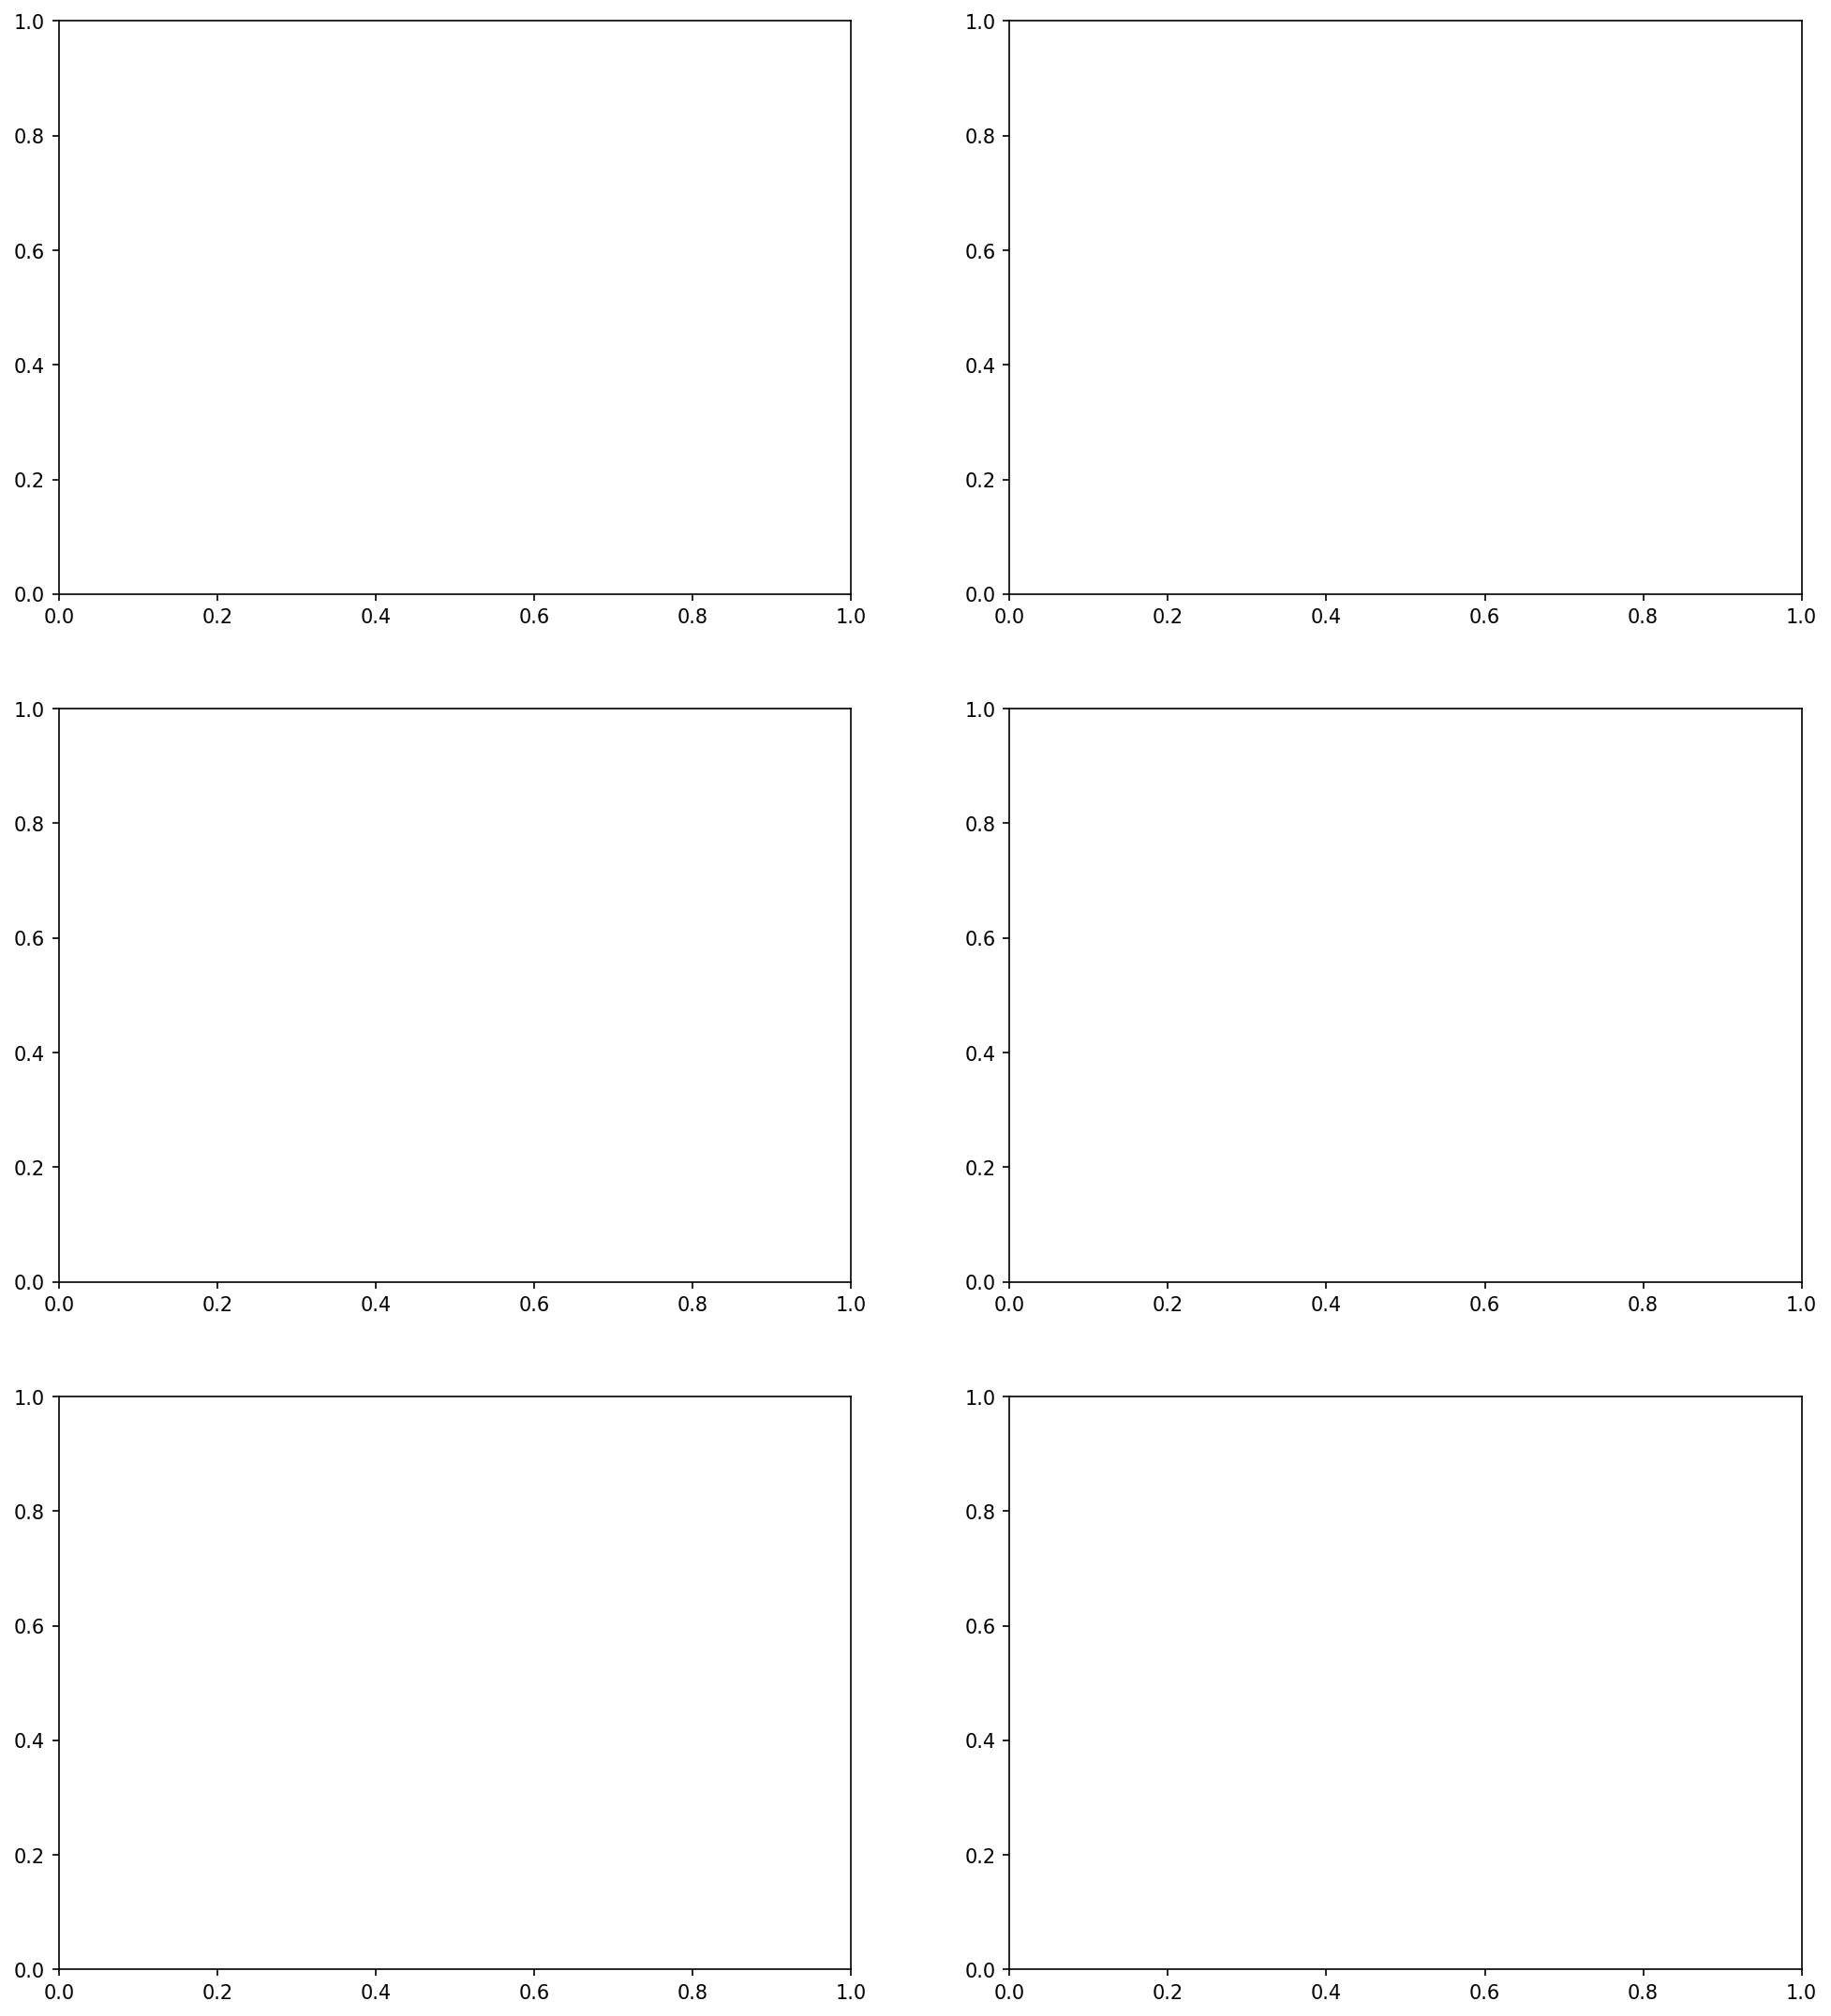

In [33]:
# Step 2.5*: Mock 数据场景图可视化（科研级）
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# 设置中文字体和科研级别的样式
plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Mock 数据定义（根据用户提供的实际场景）
mock_scene_graphs = [
    {
        'action': '(navigate_to_obj, Sink)',
        'nodes': ['Robot', 'Mug', 'Sink'],
        'edges': [
            ('Robot', 'Mug', 'holding')
        ],
        'node_attributes': {
            'Robot': {'type': 'Robot'},
            'Mug': {'type': 'Mug'},
            'Sink': {'type': 'Sink'}
        }
    },
    {
        'action': '(put_on, Mug, SinkBasin)',
        'nodes': ['Mug', 'SinkBasin'],
        'edges': [
            ('Mug', 'SinkBasin', 'inside')
        ],
        'node_attributes': {
            'Mug': {'type': 'Mug', 'state': 'clean'},
            'SinkBasin': {'type': 'SinkBasin'}
        }
    },
    {
        'action': '(toggle_off, Faucet)',
        'nodes': ['Faucet', 'CounterTop'],
        'edges': [
            ('Faucet', 'CounterTop', 'on_top_of')
        ],
        'node_attributes': {
            'Faucet': {'type': 'Faucet', 'state': 'turned off'},
            'CounterTop': {'type': 'CounterTop'}
        }
    },
    {
        'action': '(pick_up, Mug)',
        'nodes': ['Robot', 'Mug'],
        'edges': [
            ('Robot', 'Mug', 'holding')
        ],
        'node_attributes': {
            'Robot': {'type': 'Robot'},
            'Mug': {'type': 'Mug', 'state': 'dirty'}
        }
    },
    {
        'action': '(put_in, Mug, CoffeeMachine)',
        'nodes': ['Robot', 'Mug', 'CoffeeMachine', 'CounterTop', 'Cup'],
        'edges': [
            ('Robot', 'Mug', 'holding'),
            ('CoffeeMachine', 'CounterTop', 'on_top_of'),
            ('Cup', 'CoffeeMachine', 'inside')
        ],
        'node_attributes': {
            'Robot': {'type': 'Robot'},
            'Mug': {'type': 'Mug'},
            'CoffeeMachine': {'type': 'CoffeeMachine', 'state': 'not empty'},
            'CounterTop': {'type': 'CounterTop'},
            'Cup': {'type': 'Cup'}
        }
    },
    {
        'action': '(put_on, Mug, CounterTop)',
        'nodes': ['Robot', 'Mug', 'CounterTop'],
        'edges': [
            ('Mug', 'CounterTop', 'on_top_of')
        ],
        'node_attributes': {
            'Robot': {'type': 'Robot'},
            'Mug': {'type': 'Mug'},
            'CounterTop': {'type': 'CounterTop'}
        }
    }
]

def get_hierarchical_layout(G, node_attrs):
    """
    获取层次化布局位置（避免边交叉）
    
    Args:
        G: networkx 有向图
        node_attrs: 节点属性字典
    
    Returns:
        pos: 节点位置字典
    """
    # 优先使用 graphviz dot 布局（最佳效果，避免交叉）
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot', args='-Grankdir=TB -Gnodesep=2.0 -Granksep=2.0')
        return pos
    except Exception:
        pass
    
    # 如果没有 graphviz，使用自定义层次布局
    # 定义节点层级：Robot 在最上层(rank=0)，物体在中间(rank=1)，容器/表面在底层(rank=2)
    node_ranks = {}
    for node in G.nodes():
        node_type = node_attrs.get(node, {}).get('type', '').lower()
        if 'robot' in node_type or node == 'Robot':
            node_ranks[node] = 0
        elif any(kw in node_type for kw in ['counter', 'top', 'sinkbasin', 'sink']):
            node_ranks[node] = 2
        else:
            node_ranks[node] = 1
    
    # 使用 spring layout 作为基础，然后按层级调整 y 坐标
    spring_pos = nx.spring_layout(G, k=2.5, iterations=200, seed=42)
    y_min = min([p[1] for p in spring_pos.values()]) if spring_pos else -1
    y_max = max([p[1] for p in spring_pos.values()]) if spring_pos else 1
    
    pos = {}
    for node in G.nodes():
        rank = node_ranks.get(node, 1)
        spring_x = spring_pos[node][0]
        # 根据 rank 设置 y 坐标：rank 0 在顶部，rank 2 在底部
        if rank == 0:
            y = y_max + 0.6
        elif rank == 2:
            y = y_min - 0.6
        else:
            y = (y_min + y_max) / 2
        pos[node] = (spring_x, y)
    
    return pos

def create_research_quality_scene_graph(mock_data, figsize=(10, 8), dpi=300):
    """
    创建科研级别的场景图可视化
    
    Args:
        mock_data: Mock 场景图数据字典
        figsize: 图像大小
        dpi: 分辨率
    
    Returns:
        matplotlib figure 对象
    """
    action = mock_data['action']
    nodes = mock_data['nodes']
    edges = mock_data['edges']
    node_attrs = mock_data.get('node_attributes', {})
    
    # 创建有向图
    G = nx.DiGraph()
    
    # 添加节点
    for node in nodes:
        G.add_node(node)
    
    # 添加边
    for start, end, relation in edges:
        G.add_edge(start, end, relation=relation)
    
    # 创建层次布局（避免交叉）
    # 如果有 Robot 节点，将其放在顶部
    if 'Robot' in G.nodes():
        # 使用分层布局
        try:
            pos = nx.nx_agraph.graphviz_layout(G, prog='dot', args='-Grankdir=TB')
        except:
            # 如果没有 graphviz，使用层次布局
            pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)
            # 手动调整 Robot 节点位置到顶部
            if 'Robot' in pos:
                robot_y = max([p[1] for p in pos.values()]) + 0.5
                pos['Robot'] = (pos['Robot'][0], robot_y)
    else:
        pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, facecolor='white')
    
    # 定义颜色方案（科研级别）
    node_color_map = {
        'Robot': '#4A90E2',      # 蓝色 - Robot
        'Mug': '#E8A87C',        # 橙色 - 可移动物体
        'Sink': '#95B8D1',       # 浅蓝色 - 容器
        'SinkBasin': '#95B8D1',  # 浅蓝色 - 容器
        'Faucet': '#FFD93D',     # 黄色 - 设备
        'CounterTop': '#6C757D', # 灰色 - 表面
        'CoffeeMachine': '#FF6B6B', # 红色 - 设备
        'Cup': '#E8A87C'         # 橙色 - 可移动物体
    }
    
    # 获取节点颜色
    node_colors = [node_color_map.get(node, '#95A5A6') for node in G.nodes()]
    
    # 绘制节点（使用更大的节点和更粗的边框）
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=3500,
        alpha=0.95,
        linewidths=2.5,
        edgecolors='white'
    )
    
    # 创建节点标签（包含状态信息）
    node_labels = {}
    for node in G.nodes():
        attrs = node_attrs.get(node, {})
        node_type = attrs.get('type', node)
        state = attrs.get('state', '')
        
        if state:
            label = f"{node}\n({node_type})\n[{state}]"
        else:
            label = f"{node}\n({node_type})"
        node_labels[node] = label
    
    # 绘制节点标签
    nx.draw_networkx_labels(
        G, pos, labels=node_labels, ax=ax,
        font_size=10,
        font_weight='bold',
        font_color='black',
        verticalalignment='center',
        horizontalalignment='center'
    )
    
    # 绘制边（使用更粗的箭头和更明显的颜色）
    edge_colors = []
    edge_styles = []
    edge_widths = []
    
    relation_color_map = {
        'holding': '#E74C3C',      # 红色 - holding 关系
        'inside': '#3498DB',       # 蓝色 - inside 关系
        'on_top_of': '#2ECC71',    # 绿色 - on_top_of 关系
    }
    
    for start, end in G.edges():
        relation = G[start][end].get('relation', 'unknown')
        edge_colors.append(relation_color_map.get(relation, '#95A5A6'))
        edge_styles.append('solid')
        edge_widths.append(2.5)
    
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=0.8,
        arrows=True,
        arrowsize=25,
        arrowstyle='->',
        connectionstyle='arc3,rad=0.1',
        node_size=3500,
        min_source_margin=15,
        min_target_margin=15
    )
    
    # 绘制边标签（关系类型）
    edge_labels = {}
    for start, end in G.edges():
        relation = G[start][end].get('relation', '')
        edge_labels[(start, end)] = relation
    
    # 调整边标签位置，避免重叠
    edge_label_pos = {}
    for (start, end), label in edge_labels.items():
        x1, y1 = pos[start]
        x2, y2 = pos[end]
        # 标签位置在边的中点稍微偏上
        edge_label_pos[(start, end)] = ((x1 + x2) / 2, (y1 + y2) / 2 + 0.15)
    
    nx.draw_networkx_edge_labels(
        G, edge_label_pos, edge_labels, ax=ax,
        font_size=9,
        font_weight='bold',
        font_color='#2C3E50',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=1)
    )
    
    # 设置标题
    ax.set_title(f"Action: {action}", fontsize=14, fontweight='bold', pad=20)
    
    # 移除坐标轴
    ax.axis('off')
    ax.set_aspect('equal')
    
    # 添加图例
    legend_elements = []
    
    # 节点类型图例
    unique_types = set()
    for node in G.nodes():
        attrs = node_attrs.get(node, {})
        node_type = attrs.get('type', node)
        if node_type not in unique_types:
            color = node_color_map.get(node, '#95A5A6')
            legend_elements.append(mpatches.Patch(facecolor=color, edgecolor='white', linewidth=1.5, label=node_type))
            unique_types.add(node_type)
    
    # 关系类型图例
    unique_relations = set()
    for _, _, relation in edges:
        if relation not in unique_relations:
            color = relation_color_map.get(relation, '#95A5A6')
            legend_elements.append(mpatches.Patch(facecolor=color, edgecolor='gray', linewidth=2.5, label=f"relation: {relation}"))
            unique_relations.add(relation)
    
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=9)
    
    plt.tight_layout()
    
    return fig

# 可视化所有 Mock 场景图
print("="*80)
print("Step 2.5*: Mock 数据场景图可视化（科研级）")
print("="*80)
print()

num_graphs = len(mock_scene_graphs)
cols = 2  # 每行显示 2 个图
rows = (num_graphs + cols - 1) // cols

# 创建大图包含所有子图
fig, axes = plt.subplots(rows, cols, figsize=(16, 6*rows), dpi=150, facecolor='white')

# 确保 axes 是二维数组
if rows == 1:
    axes = axes.reshape(1, -1)
elif cols == 1:
    axes = axes.reshape(-1, 1)
else:
    axes = axes

# 展平 axes 以便循环使用
axes_flat = axes.flatten()

for idx, mock_data in enumerate(mock_scene_graphs):
    ax = axes[idx]
    action = mock_data['action']
    nodes = mock_data['nodes']
    edges = mock_data['edges']
    node_attrs = mock_data.get('node_attributes', {})
    
    # 创建有向图
    G = nx.DiGraph()
    for node in nodes:
        G.add_node(node)
    for start, end, relation in edges:
        G.add_edge(start, end, relation=relation)
    
    # 使用层次布局（避免交叉）
    pos = get_hierarchical_layout(G, node_attrs)
    
    # 颜色方案
    node_color_map = {
        'Robot': '#4A90E2', 'Mug': '#E8A87C', 'Sink': '#95B8D1',
        'SinkBasin': '#95B8D1', 'Faucet': '#FFD93D', 'CounterTop': '#6C757D',
        'CoffeeMachine': '#FF6B6B', 'Cup': '#E8A87C'
    }
    node_colors = [node_color_map.get(node, '#95A5A6') for node in G.nodes()]
    
    # 绘制节点（确保所有节点都在 pos 中）
    nodes_in_pos = [n for n in G.nodes() if n in pos]
    if not nodes_in_pos:
        ax.text(0.5, 0.5, f"Error: No nodes in pos\nAction: {action}", 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
        continue
    
    # 只绘制在 pos 中的节点
    node_colors_filtered = [node_color_map.get(node, '#95A5A6') for node in nodes_in_pos]
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes_in_pos, node_color=node_colors_filtered, 
                           node_size=3000, alpha=0.95, linewidths=2, edgecolors='white')
    
    # 节点标签（只包含在 pos 中的节点）
    node_labels = {}
    for node in nodes_in_pos:
        attrs = node_attrs.get(node, {})
        node_type = attrs.get('type', node)
        state = attrs.get('state', '')
        if state:
            node_labels[node] = f"{node}\n({node_type})\n[{state}]"
        else:
            node_labels[node] = f"{node}\n({node_type})"
    
    if node_labels:
        nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=9, 
                                font_weight='bold', font_color='black')
    
    # 绘制边（只包含在 pos 中的节点的边）
    edges_to_draw = [(s, e) for s, e in G.edges() if s in pos and e in pos]
    if edges_to_draw:
        relation_color_map = {'holding': '#E74C3C', 'inside': '#3498DB', 'on_top_of': '#2ECC71'}
        edge_colors = [relation_color_map.get(G[s][e].get('relation', 'unknown'), '#95A5A6') 
                       for s, e in edges_to_draw]
        
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges_to_draw, edge_color=edge_colors, 
                              width=2.5, alpha=0.8, arrows=True, arrowsize=20, arrowstyle='->', 
                              connectionstyle='arc3,rad=0.1', node_size=3000, 
                              min_source_margin=12, min_target_margin=12)
    
    # 边标签（安全处理，确保所有节点都在 pos 中）
    edge_labels = {}
    edge_label_pos = {}
    for start, end in G.edges():
        # 确保节点都在 pos 中
        if start in pos and end in pos:
            relation = G[start][end].get('relation', '')
            if relation:  # 只添加非空的关系标签
                edge_labels[(start, end)] = relation
                x1, y1 = pos[start]
                x2, y2 = pos[end]
                edge_label_pos[(start, end)] = ((x1 + x2) / 2, (y1 + y2) / 2 + 0.12)
    
    # 只在有边标签时绘制
    if edge_labels and edge_label_pos:
        nx.draw_networkx_edge_labels(G, edge_label_pos, edge_labels, ax=ax, font_size=8,
                                    font_weight='bold', font_color='#2C3E50',
                                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                             alpha=0.8, edgecolor='gray', linewidth=0.8))
    
    ax.set_title(f"Action: {action}", fontsize=12, fontweight='bold', pad=15)
    ax.axis('off')
    ax.set_aspect('equal')

# 隐藏多余的子图
for idx in range(num_graphs, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout(pad=2.0)
plt.show()

print(f"\n✅ 已生成 {num_graphs} 个场景图可视化")
print("   每个场景图使用层次布局，避免边交叉")
print("   颜色编码：蓝色=Robot, 橙色=可移动物体, 浅蓝=容器, 黄色/红色=设备, 灰色=表面")


In [30]:
# Step 2.5*: 单独生成高质量场景图（可选 - 用于论文图片）
# 如果需要单独保存每个场景图为高分辨率图片，可以使用这个代码

def save_individual_scene_graphs(output_dir='scene_graph_figures'):
    """将每个场景图单独保存为高分辨率图片"""
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    for idx, mock_data in enumerate(mock_scene_graphs):
        fig = create_research_quality_scene_graph(mock_data, figsize=(10, 8), dpi=300)
        
        # 生成文件名
        action_name = mock_data['action'].replace('(', '').replace(')', '').replace(',', '_').replace(' ', '_')
        filename = f"{output_dir}/scene_graph_action_{idx+1}_{action_name}.png"
        
        fig.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close(fig)
        print(f"  ✓ 已保存: {filename}")
    
    print(f"\n✅ 所有场景图已保存到: {output_dir}/")

# 如果需要保存单独的高分辨率图片，取消下面的注释
# save_individual_scene_graphs('scene_graph_figures')


📁 Output directory: output/scene_graph_visualizations
Step 2.5: 场景图可视化
\n📊 可视化 makeCoffee 的关键帧...
\n📋 makeCoffee 场景图详细信息:
\n🔵 初始场景图 (Frame 0):
   📊 统计: 2 个节点, 2 条边
   📝 文字描述: Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty), SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean). Mug_0b3dbbd3 (cl...
\n   📦 节点列表 (2 个):
      1. Mug_0b3dbbd3 (closed and turned off and empty and not sliced and not cracked and dirty)
      2. SinkBasin_d14683a7 (closed and turned off and empty and not sliced and not cracked and clean)
\n   🔗 关系列表 (2 条):
      1. Mug_0b3dbbd3 --[inside]--> SinkBasin_d14683a7
      2. SinkBasin_d14683a7 --[left_of]--> Mug_0b3dbbd3
\n🟢 最终场景图 (Frame 80):
   📊 统计: 9 个节点, 8 条边
   📝 文字描述: Faucet_4105d586 (closed and turned off and empty and not sliced and not cracked and clean), CounterTop_f5c687d1 (closed and turned off and empty and not sliced and not cracked and clean), Mug_0b3dbbd3...
\n   📦 节点列表 (9

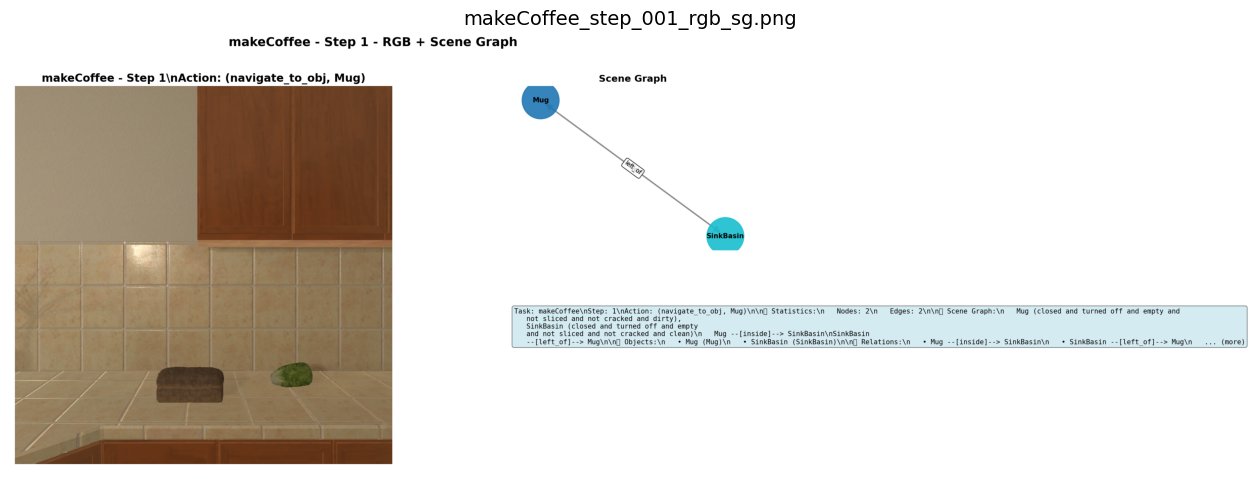

\n[2/12] makeCoffee_step_004_rgb_sg.png:


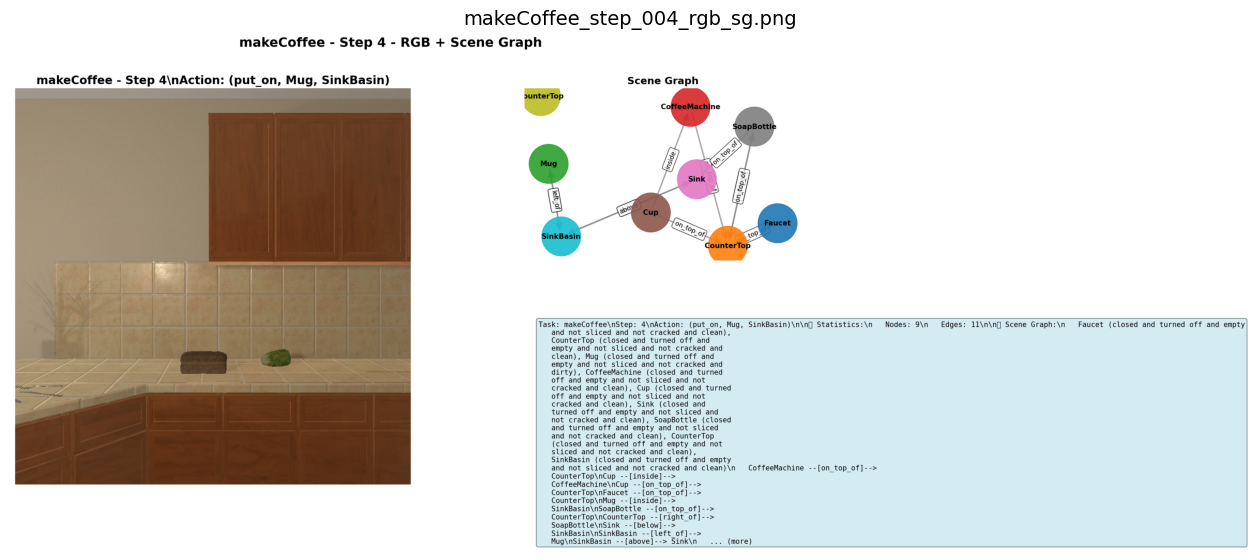

\n[3/12] makeCoffee_step_007_rgb_sg.png:


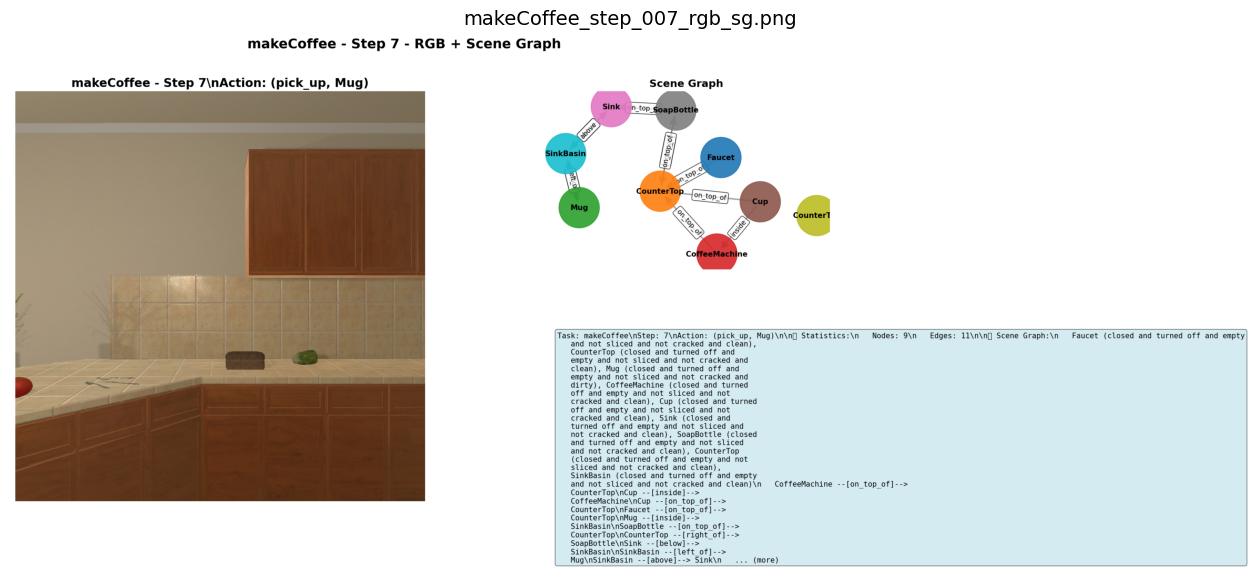

\n[4/12] makeCoffee_step_010_rgb_sg.png:


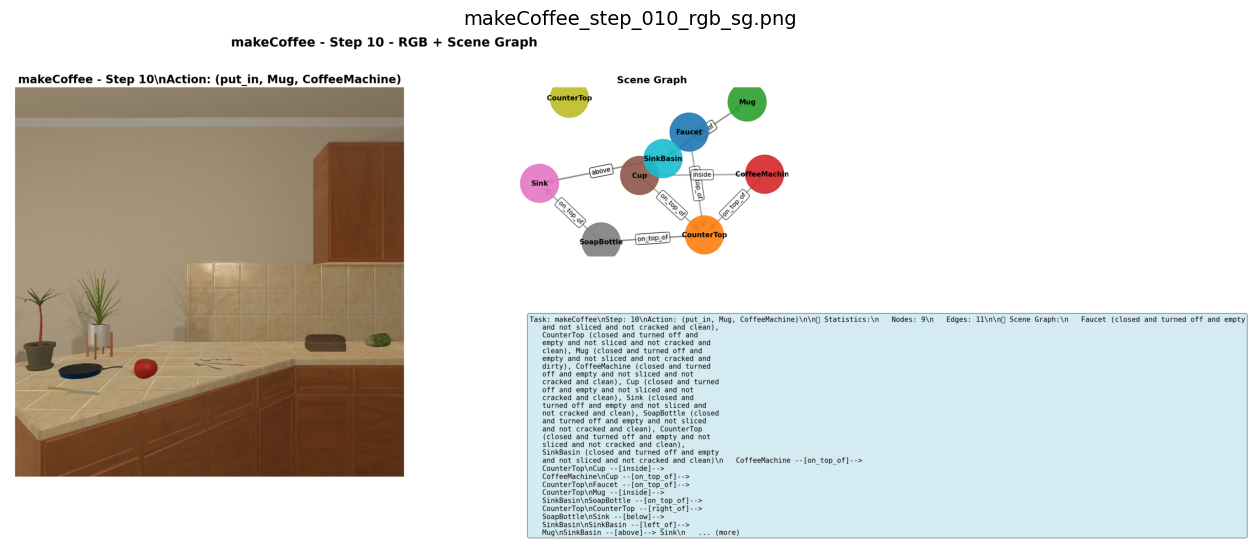

\n[5/12] makeCoffee_step_013_rgb_sg.png:


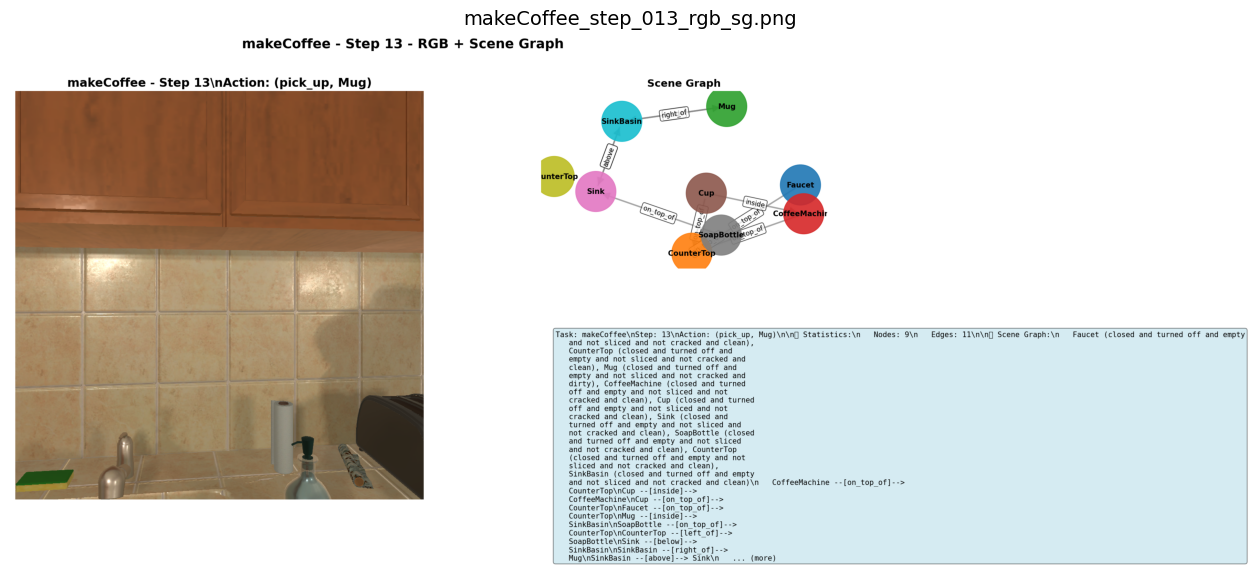

\n[6/12] makeCoffee_step_041_rgb_sg.png:


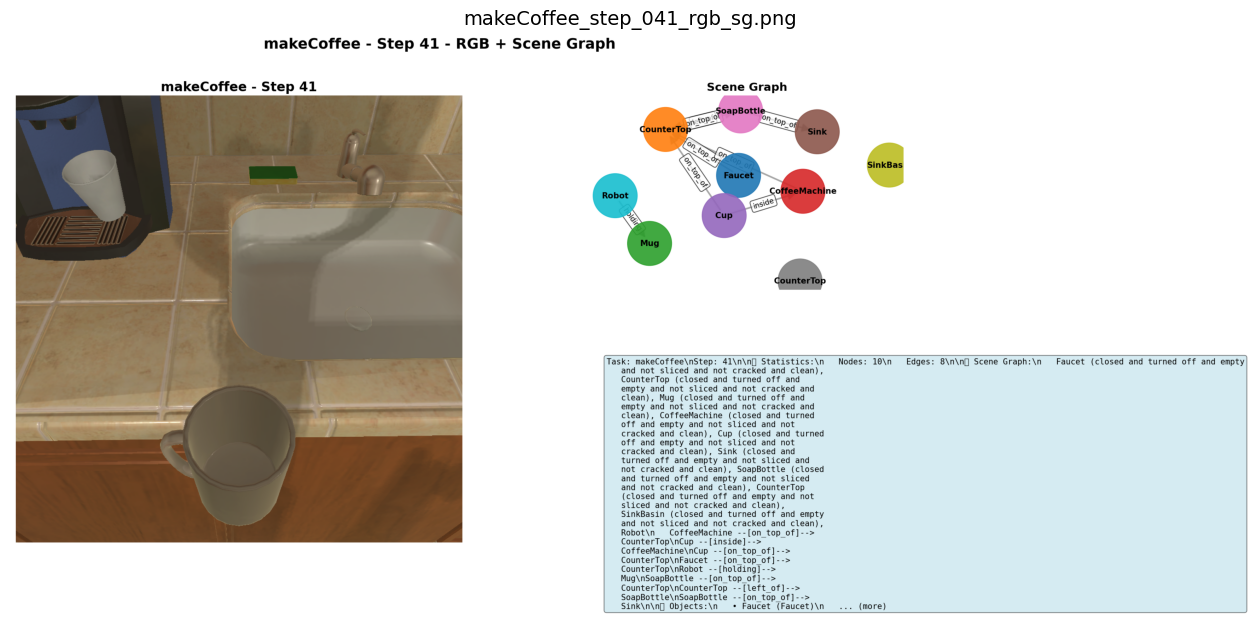

\n[7/12] makeCoffee_step_081_rgb_sg.png:


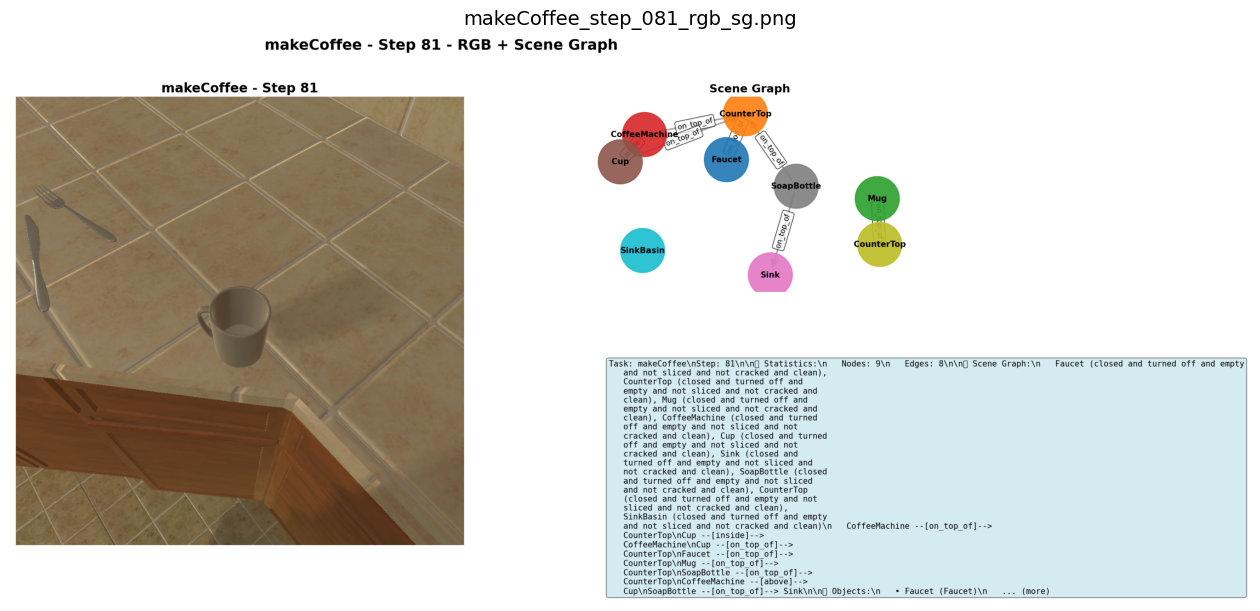

\n[8/12] boilWater_step_001_rgb_sg.png:


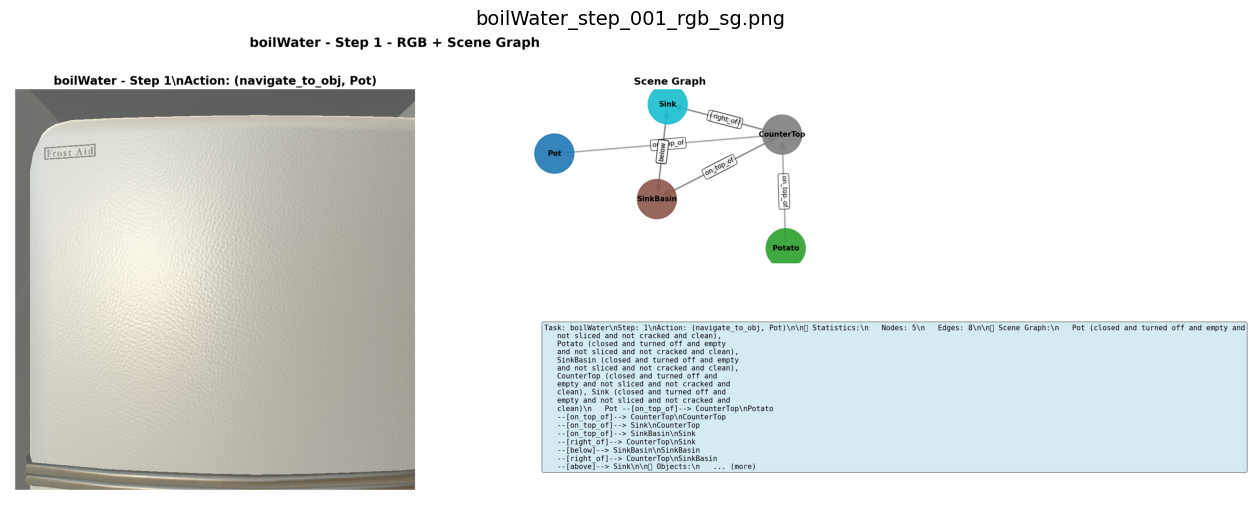

\n[9/12] boilWater_step_004_rgb_sg.png:


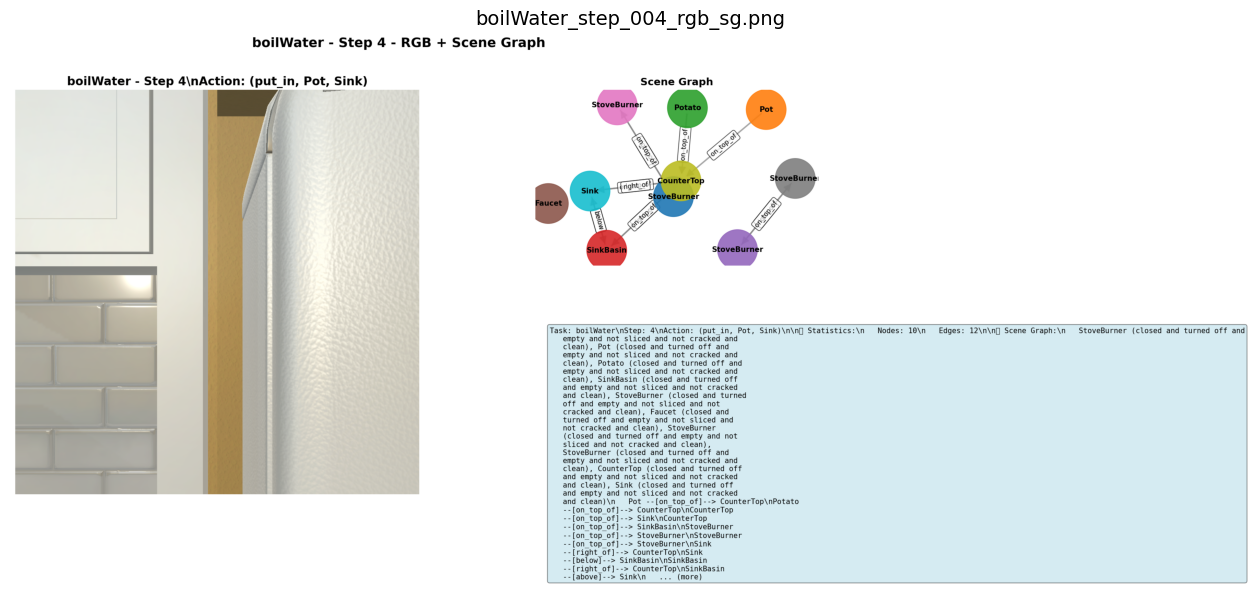

\n[10/12] boilWater_step_007_rgb_sg.png:


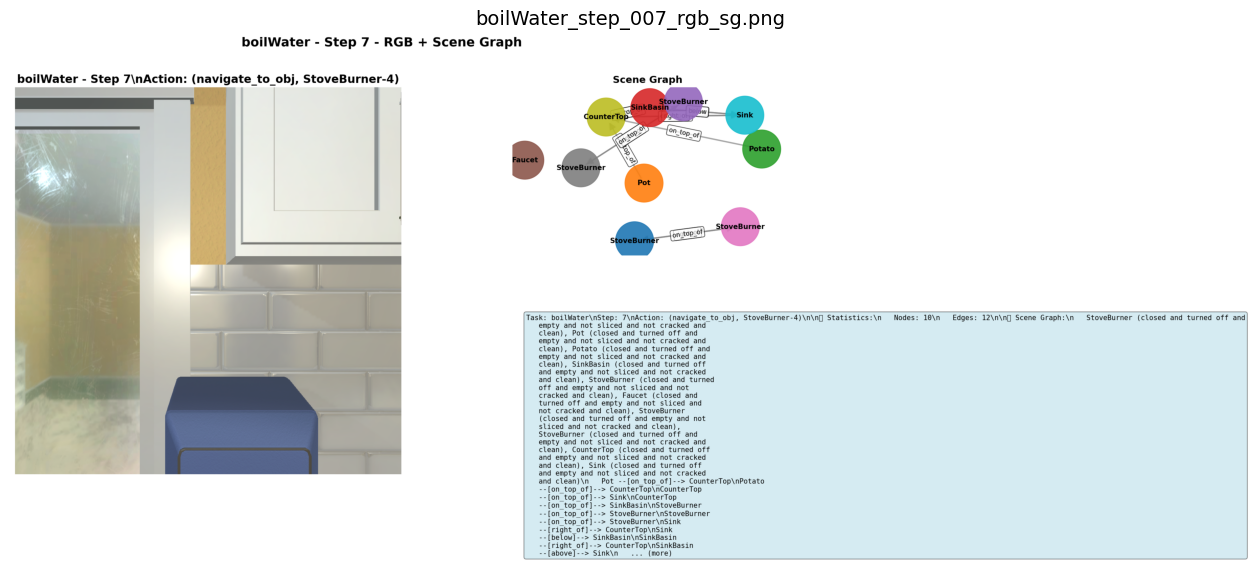

\n[11/12] boilWater_step_024_rgb_sg.png:


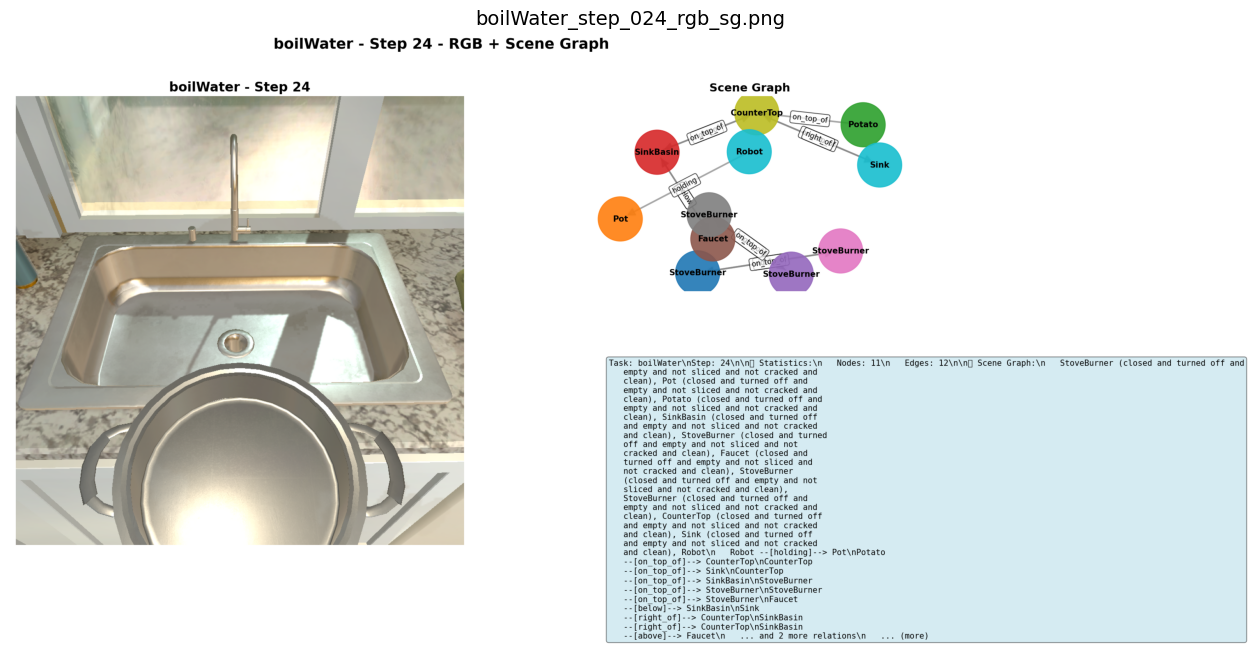

\n[12/12] boilWater_step_046_rgb_sg.png:


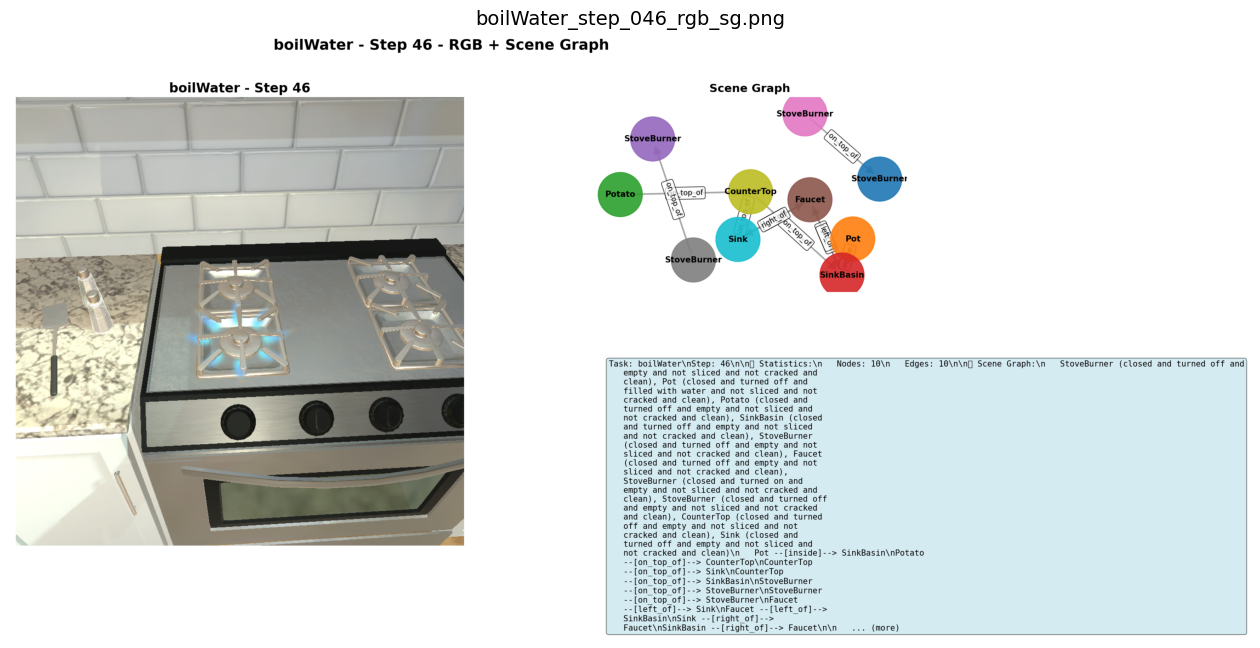

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from PIL import Image
import numpy as np
import re
import textwrap

def extract_base_name(full_name: str) -> str:
    """
    从完整对象名称中提取基础名称（去掉后面的编号）
    例如: 'CoffeeMachine_43b68f52' -> 'CoffeeMachine'
          'Mug_0b3dbbd3' -> 'Mug'
          'StoveBurner-4' -> 'StoveBurner-4' (保留连字符后的数字)
    """
    if not full_name:
        return full_name
    
    # 匹配下划线后的十六进制或数字编号（例如 _43b68f52, _0b3dbbd3）
    # 或者匹配下划线后的其他字符
    match = re.match(r'^([^_]+)', full_name)
    if match:
        base = match.group(1)
        # 如果基础名称以数字结尾（例如 StoveBurner-4），保留它
        return base
    return full_name

def create_combined_visualization(rgb_image, scene_graph, step_idx, task_name, action_info=None):
    """
    创建组合可视化：RGB 图 + Scene Graph
    
    Args:
        rgb_image: RGB 图像 (numpy array 或 PIL Image, H x W x 3)
        scene_graph: SceneGraph 对象
        step_idx: 帧索引
        task_name: 任务名称
        action_info: 可选的动作信息
    
    Returns:
        matplotlib figure 对象
    """
    # 转换图像格式
    if isinstance(rgb_image, Image.Image):
        rgb_array = np.array(rgb_image)
    else:
        rgb_array = rgb_image
    
    # 创建图形，左侧显示 RGB，右侧显示 Scene Graph
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, width_ratios=[1.2, 0.8])
    
    # ========== 左侧：RGB 图像 ==========
    ax_rgb = fig.add_subplot(gs[:, 0])
    ax_rgb.imshow(rgb_array)
    
    # 在 RGB 图上标注对象（如果有位置信息）
    nodes_list = list(scene_graph.nodes)  # 转换为列表以便索引
    colors = plt.cm.tab10(np.linspace(0, 1, len(nodes_list))) if len(nodes_list) > 0 else []
    img_h, img_w = rgb_array.shape[:2]
    
    for i, node in enumerate(nodes_list):
        # 尝试获取 2D 边界框或位置信息
        bbox2d = None
        if hasattr(node, 'attributes') and node.attributes:
            bbox2d = node.attributes.get('bbox2d')
        
        # 如果有边界框，绘制它
        if bbox2d is not None:
            bbox_array = np.array(bbox2d).flatten()
            if len(bbox_array) >= 4:
                # 处理归一化坐标或像素坐标
                if bbox_array.max() <= 1.0 and bbox_array.min() >= 0.0:
                    x1, y1, x2, y2 = bbox_array[:4] * [img_w, img_h, img_w, img_h]
                else:
                    x1, y1, x2, y2 = bbox_array[:4]
                
                x1, x2 = max(0, min(x1, img_w)), max(0, min(x2, img_w))
                y1, y2 = max(0, min(y1, img_h)), max(0, min(y2, img_h))
                
                if x2 > x1 and y2 > y1:
                    rect = mpatches.Rectangle(
                        (x1, y1), x2-x1, y2-y1,
                        linewidth=3, edgecolor=colors[i], facecolor='none'
                    )
                    ax_rgb.add_patch(rect)
                    full_name = node.get_name() if hasattr(node, 'get_name') else node.name
                    # 提取基础名称（去掉编号）
                    label = extract_base_name(full_name)
                    ax_rgb.text(x1, max(10, y1 - 5), label,
                               fontsize=11, color=colors[i], fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    title = f"{task_name} - Step {step_idx}"
    if action_info:
        title += f"\\nAction: {action_info}"
    ax_rgb.set_title(title, fontsize=16, fontweight='bold')
    ax_rgb.axis('off')
    
    # ========== 右上：Scene Graph 可视化 ==========
    ax_sg = fig.add_subplot(gs[0, 1])
    
    if len(scene_graph.nodes) > 0:
        # 使用 networkx 绘制场景图
        G = nx.DiGraph()
        node_labels = {}
        
        # 添加节点
        nodes_list = list(scene_graph.nodes)  # 转换为列表以便索引
        for i, node in enumerate(nodes_list):
            full_name = node.get_name() if hasattr(node, 'get_name') else node.name
            # 提取基础名称（去掉编号）
            node_name = extract_base_name(full_name)
            label = f"{node_name}\\n({node.object_type})"
            G.add_node(node.name, label=label, color=colors[i])
            node_labels[node.name] = node_name
        
        # 添加边
        for (start_name, end_name), edge in scene_graph.edges.items():
            G.add_edge(start_name, end_name, label=edge.edge_type)
        
        # 创建布局
        if len(G.nodes()) > 0:
            try:
                pos = nx.spring_layout(G, k=1.5, iterations=50)
            except:
                pos = nx.circular_layout(G)
            
            # 绘制节点
            node_colors = [G.nodes[node]['color'] for node in G.nodes()]
            nx.draw_networkx_nodes(G, pos, ax=ax_sg, 
                                  node_color=node_colors,
                                  node_size=3000, alpha=0.9)
            
            # 绘制标签
            nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax_sg,
                                   font_size=10, font_weight='bold')
            
            # 绘制边
            nx.draw_networkx_edges(G, pos, ax=ax_sg, edge_color='gray',
                                  arrows=True, arrowsize=20, width=2, alpha=0.7)
            
            # 边标签
            edge_labels = {}
            for (start, end), edge_data in G.edges.items():
                edge_labels[(start, end)] = edge_data.get('label', '')
            nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax_sg, 
                                         font_size=9, bbox=dict(boxstyle='round,pad=0.3', 
                                                               facecolor='white', alpha=0.7))
    
    ax_sg.set_title('Scene Graph', fontsize=14, fontweight='bold')
    ax_sg.axis('off')
    
    # ========== 右下：统计信息和场景图文本描述 ==========
    ax_info = fig.add_subplot(gs[1, 1])
    ax_info.axis('off')
    
    # 获取场景图的文本描述（使用基础名称）
    scene_text_parts = []
    nodes_list = list(scene_graph.nodes)
    if nodes_list:
        node_names = []
        for node in nodes_list:
            full_name = node.get_name() if hasattr(node, 'get_name') else node.name
            base_name = extract_base_name(full_name)
            state_str = f" ({node.state})" if node.state else ""
            node_names.append(f"{base_name}{state_str}")
        scene_text_parts.append(", ".join(node_names))
    
    # 添加关系描述（使用基础名称）
    if len(scene_graph.edges) > 0:
        relations = []
        for (start_name, end_name), edge in list(scene_graph.edges.items())[:10]:  # 最多显示 10 个关系
            start_base = extract_base_name(start_name)
            end_base = extract_base_name(end_name)
            relations.append(f"{start_base} --[{edge.edge_type}]--> {end_base}")
        if relations:
            scene_text_parts.append("\\n".join(relations))
        if len(scene_graph.edges) > 10:
            scene_text_parts.append(f"... and {len(scene_graph.edges) - 10} more relations")
    
    # 构建信息文本（使用与场景图匹配的宽度）
    max_width = 45  # 统一使用这个宽度，确保所有文本都匹配场景图宽度
    info_text = f"Task: {task_name}\\n"
    info_text += f"Step: {step_idx}\\n"
    if action_info:
        # 如果 action_info 太长，进行换行
        action_str = str(action_info)
        if len(action_str) > max_width - 8:  # 减去 "Action: " 的长度
            action_wrapped = textwrap.fill(action_str, width=max_width - 8, 
                                         break_long_words=False, 
                                         initial_indent="Action: ",
                                         subsequent_indent="        ")
            info_text += action_wrapped + "\\n"
        else:
            info_text += f"Action: {action_str}\\n"
    info_text += f"\\n📊 Statistics:\\n"
    info_text += f"   Nodes: {len(scene_graph.nodes)}\\n"
    info_text += f"   Edges: {len(scene_graph.edges)}\\n"
    
    # 添加场景图文本描述（使用基础名称，匹配场景图宽度）
    if scene_text_parts:
        info_text += f"\\n📋 Scene Graph:\\n"
        for part in scene_text_parts:
            # 对长文本进行换行，确保宽度匹配场景图
            wrapped = textwrap.fill(part, width=max_width, break_long_words=False, 
                                   break_on_hyphens=False, initial_indent="   ", 
                                   subsequent_indent="   ")
            info_text += wrapped + "\\n"
    
    if len(nodes_list) > 0:
        info_text += f"\\n🔍 Objects:\\n"
        for node in nodes_list[:8]:  # 最多显示 8 个，减少显示数量
            full_name = node.get_name() if hasattr(node, 'get_name') else node.name
            # 提取基础名称（去掉编号）
            node_name = extract_base_name(full_name)
            obj_str = f"   • {node_name} ({node.object_type})"
            # 如果对象描述太长，进行换行
            if len(obj_str) > max_width:
                obj_wrapped = textwrap.fill(obj_str, width=max_width, 
                                          break_long_words=False, 
                                          subsequent_indent="     ")
                info_text += obj_wrapped + "\\n"
            else:
                info_text += obj_str + "\\n"
        if len(nodes_list) > 8:
            info_text += f"   ... +{len(nodes_list) - 8} more\\n"
    
    if len(scene_graph.edges) > 0:
        info_text += f"\\n🔗 Relations:\\n"
        for (start_name, end_name), edge in list(scene_graph.edges.items())[:4]:  # 最多显示 4 个
            start_base = extract_base_name(start_name)
            end_base = extract_base_name(end_name)
            relation_str = f"   • {start_base} --[{edge.edge_type}]--> {end_base}"
            # 如果关系描述太长，进行换行
            if len(relation_str) > max_width:
                relation_wrapped = textwrap.fill(relation_str, width=max_width, 
                                               break_long_words=False, 
                                               subsequent_indent="     ")
                info_text += relation_wrapped + "\\n"
            else:
                info_text += relation_str + "\\n"
        if len(scene_graph.edges) > 4:
            info_text += f"   ... +{len(scene_graph.edges) - 4} more\\n"
    
    # 限制整体文本长度，确保不会超出显示区域（匹配场景图高度）
    # 如果文本太长，截断并添加省略号
    max_lines = 20  # 最多显示20行，确保与场景图高度匹配
    info_lines = info_text.split('\\n')
    if len(info_lines) > max_lines:
        info_text = '\\n'.join(info_lines[:max_lines]) + '\\n   ... (more)'
    
    # 使用 textwrap 预处理文本，确保文本在指定宽度内换行
    # 由于 matplotlib text 不支持自动换行，我们需要手动处理
    ax_info.text(0.05, 0.95, info_text, fontsize=10, 
                verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.suptitle(f"{task_name} - Step {step_idx} - RGB + Scene Graph", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    return fig

# 创建输出目录
output_dir = Path("output/scene_graph_visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"📁 Output directory: {output_dir}")

# 为每个任务可视化关键帧
print("="*80)
print("Step 2.5: 场景图可视化")
print("="*80)

# 选择要可视化的关键帧（初始、中间、最终）
key_frames = {
    'initial': 0,
    'middle': None,  # 将在后面计算
    'final': None    # 将在后面计算
}

# 收集所有任务的可视化文件
all_saved_files = []

for task_name, data in task_data.items():
    print(f"\\n📊 可视化 {task_name} 的关键帧...")
    
    events = data.get('events', [])
    task_info = data.get('task_info', {})
    actions = task_info.get('actions', [])
    ego_img_dir = Path(data.get('data_path', '')) / 'ego_img'
    
    if not ego_img_dir.exists():
        print(f"   ⚠️  Ego images 目录不存在: {ego_img_dir}")
        continue
    
    # ============================================================================
    # 添加文字和日志输出，展现 scene graph
    # ============================================================================
    print(f"\\n📋 {task_name} 场景图详细信息:")
    print("="*80)
    
    # 显示初始和最终场景图
    initial_sg = data.get('initial_sg')
    final_sg = data.get('final_sg')
    action_relevant_sgs = data.get('action_relevant_sgs', [])
    
    if initial_sg:
        print(f"\\n🔵 初始场景图 (Frame 0):")
        print(f"   📊 统计: {len(initial_sg.nodes)} 个节点, {len(initial_sg.edges)} 条边")
        print(f"   📝 文字描述: {initial_sg.to_text()[:200]}...")
        
        # 显示节点详情
        if initial_sg.nodes:
            print(f"\\n   📦 节点列表 ({len(initial_sg.nodes)} 个):")
            for i, node in enumerate(list(initial_sg.nodes)[:10], 1):
                attrs = []
                if hasattr(node, 'attributes') and node.attributes:
                    if node.attributes.get('isPickedUp'):
                        attrs.append('isPickedUp')
                    if node.attributes.get('isOpen'):
                        attrs.append('isOpen')
                    if node.attributes.get('isToggled'):
                        attrs.append('isToggled')
                    if node.attributes.get('isFilled'):
                        attrs.append('isFilled')
                attr_str = f" [{', '.join(attrs)}]" if attrs else ""
                state_str = f" ({node.state})" if node.state else ""
                print(f"      {i}. {node.name}{state_str}{attr_str}")
            if len(initial_sg.nodes) > 10:
                print(f"      ... 还有 {len(initial_sg.nodes) - 10} 个节点")
        
        # 显示边详情
        if initial_sg.edges:
            print(f"\\n   🔗 关系列表 ({len(initial_sg.edges)} 条):")
            for i, ((start_name, end_name), edge) in enumerate(list(initial_sg.edges.items())[:10], 1):
                print(f"      {i}. {start_name} --[{edge.edge_type}]--> {end_name}")
            if len(initial_sg.edges) > 10:
                print(f"      ... 还有 {len(initial_sg.edges) - 10} 条关系")
    
    if final_sg:
        print(f"\\n🟢 最终场景图 (Frame {len(events)-1}):")
        print(f"   📊 统计: {len(final_sg.nodes)} 个节点, {len(final_sg.edges)} 条边")
        print(f"   📝 文字描述: {final_sg.to_text()[:200]}...")
        
        # 显示节点详情
        if final_sg.nodes:
            print(f"\\n   📦 节点列表 ({len(final_sg.nodes)} 个):")
            for i, node in enumerate(list(final_sg.nodes)[:10], 1):
                attrs = []
                if hasattr(node, 'attributes') and node.attributes:
                    if node.attributes.get('isPickedUp'):
                        attrs.append('isPickedUp')
                    if node.attributes.get('isOpen'):
                        attrs.append('isOpen')
                    if node.attributes.get('isToggled'):
                        attrs.append('isToggled')
                    if node.attributes.get('isFilled'):
                        attrs.append('isFilled')
                attr_str = f" [{', '.join(attrs)}]" if attrs else ""
                state_str = f" ({node.state})" if node.state else ""
                print(f"      {i}. {node.name}{state_str}{attr_str}")
            if len(final_sg.nodes) > 10:
                print(f"      ... 还有 {len(final_sg.nodes) - 10} 个节点")
        
        # 显示边详情
        if final_sg.edges:
            print(f"\\n   🔗 关系列表 ({len(final_sg.edges)} 条):")
            for i, ((start_name, end_name), edge) in enumerate(list(final_sg.edges.items())[:10], 1):
                print(f"      {i}. {start_name} --[{edge.edge_type}]--> {end_name}")
            if len(final_sg.edges) > 10:
                print(f"      ... 还有 {len(final_sg.edges) - 10} 条关系")
    
    # 显示关键动作帧的场景图
    if action_relevant_sgs and len(action_relevant_sgs) > 0:
        print(f"\\n🎯 关键动作帧场景图 (显示前5个关键帧):")
        key_frames_to_show = [0, len(action_relevant_sgs) // 4, len(action_relevant_sgs) // 2, 
                              len(action_relevant_sgs) * 3 // 4, len(action_relevant_sgs) - 1]
        key_frames_to_show = sorted(set([f for f in key_frames_to_show if 0 <= f < len(action_relevant_sgs)]))[:5]
        
        for frame_idx in key_frames_to_show:
            action_sg = action_relevant_sgs[frame_idx]
            action_str = actions[frame_idx] if frame_idx < len(actions) else "N/A"
            print(f"\\n   📍 Frame {frame_idx} - Action: {action_str}")
            print(f"      📊 统计: {len(action_sg.nodes)} 个节点, {len(action_sg.edges)} 条边")
            
            # 显示节点
            if action_sg.nodes:
                node_names = [node.name for node in list(action_sg.nodes)[:5]]
                print(f"      📦 节点: {', '.join(node_names)}")
                if len(action_sg.nodes) > 5:
                    print(f"         ... 还有 {len(action_sg.nodes) - 5} 个节点")
            
            # 显示关系
            if action_sg.edges:
                relations = []
                for (start_name, end_name), edge in list(action_sg.edges.items())[:5]:
                    relations.append(f"{start_name}--[{edge.edge_type}]-->{end_name}")
                print(f"      🔗 关系: {'; '.join(relations)}")
                if len(action_sg.edges) > 5:
                    print(f"         ... 还有 {len(action_sg.edges) - 5} 条关系")
    
    print("\\n" + "="*80)
    
    # 计算关键帧索引
    num_events = len(events)
    key_frames['final'] = num_events - 1
    key_frames['middle'] = num_events // 2
    
    # 选择要可视化的帧（初始、中间、最终，以及每几个动作后的帧）
    frames_to_visualize = [0]  # 初始帧
    
    # 添加中间关键帧
    if num_events > 1:
        frames_to_visualize.append(key_frames['middle'])
    if num_events > 2:
        frames_to_visualize.append(key_frames['final'])
    
    # 添加每个动作后的帧（每 3 个动作一个）
    for i in range(3, len(actions), 3):
        if i < num_events:
            frames_to_visualize.append(i)
    
    frames_to_visualize = sorted(set(frames_to_visualize))
    
    print(f"   将可视化 {len(frames_to_visualize)} 个关键帧: {frames_to_visualize}")
    
    task_saved_files = []  # 当前任务保存的文件
    for frame_idx in frames_to_visualize:
        # 加载 RGB 图像
        img_path = ego_img_dir / f"img_step_{frame_idx + 1}.png"
        
        if not img_path.exists():
            print(f"   ⚠️  图像不存在: {img_path}")
            continue
        
        try:
            rgb_image = Image.open(img_path)
            
            # 获取对应的场景图
            if frame_idx == 0:
                scene_graph = data.get('initial_sg')
            elif frame_idx == key_frames['final']:
                scene_graph = data.get('final_sg')
            else:
                # 为中间帧生成场景图（Action-aware）
                if frame_idx < len(events):
                    # 获取对应的动作信息
                    action_info_for_sg = None
                    if frame_idx < len(actions):
                        action_info_for_sg = actions[frame_idx]
                    scene_graph = generate_scene_graph_from_event(
                        events[frame_idx], task_info, 
                        timestep=frame_idx, 
                        action=action_info_for_sg
                    )
                    scene_graph = extract_task_relevant_subgraph(
                        scene_graph, task_info, 
                        timestep=frame_idx, 
                        action=action_info_for_sg
                    )
                else:
                    scene_graph = data.get('final_sg')
            
            # 获取动作信息
            action_info = None
            if frame_idx < len(actions):
                action_info = actions[frame_idx]
            
            # 创建可视化
            fig = create_combined_visualization(
                rgb_image, scene_graph, frame_idx + 1, task_name, action_info
            )
            
            # 保存图片
            output_path = output_dir / f"{task_name}_step_{frame_idx + 1:03d}_rgb_sg.png"
            fig.savefig(output_path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            
            task_saved_files.append(output_path)
            all_saved_files.append(output_path)  # 添加到总列表
            print(f"   ✅ Saved: {output_path.name}")
            
        except Exception as e:
            print(f"   ❌ Error processing frame {frame_idx}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"   ✅ {task_name}: 成功生成 {len(task_saved_files)} 个可视化文件")

print(f"\\n✅ 场景图可视化完成！")
print(f"📁 所有文件保存在: {output_dir}")
print(f"📊 总共生成了 {len(all_saved_files)} 个可视化文件")

# 显示所有可视化（在 notebook 中）
if len(all_saved_files) > 0:
    print(f"\\n📸 显示所有 {len(all_saved_files)} 个可视化:")
    for i, file_path in enumerate(all_saved_files):
        print(f"\\n[{i+1}/{len(all_saved_files)}] {file_path.name}:")
        img = plt.imread(file_path)
        plt.figure(figsize=(16, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(file_path.name, fontsize=14)
        plt.show()


## Step 3: 约束生成 (LLM)

使用 LLM 为每个任务生成逻辑约束。


In [15]:
# 动作感知约束生成 (Action-aware Constraint Generation)
# 检查 CRAFT_AVAILABLE 和 llm_prompter 是否可用
try:
    craft_available = CRAFT_AVAILABLE
except NameError:
    craft_available = False

# 检查 llm_prompter 是否可用，如果不可用则尝试重新初始化
try:
    llm_prompter_exists = llm_prompter is not None
except NameError:
    llm_prompter_exists = False

# 如果 llm_prompter 不可用，尝试重新初始化
if craft_available and not llm_prompter_exists:
    print("⚠️  LLM Prompter 未初始化，尝试重新初始化...")
    try:
        # 获取 API 配置
        try:
            api_key = API_KEY
            base_url = POLOAPI_BASE_URL
            gpt_version = GPT_VERSION
        except NameError:
            # 如果配置不存在，使用默认值
            print("⚠️  使用默认 API 配置")
            api_key = "sk-UQFLOuq6vZEiBEeNVSRiRkgNErTitcdVQjAMwrlH08f870H2"
            base_url = "https://poloai.top/v1"
            gpt_version = "gpt-4"
        
        from craft.reasoning import LLMPrompter
        llm_prompter = LLMPrompter(
            gpt_version=gpt_version,
            api_key=api_key,
            base_url=base_url
        )
        llm_prompter_exists = True
        print(f"✅ LLM Prompter ({gpt_version}) 初始化成功")
    except Exception as e:
        print(f"⚠️  LLM Prompter 初始化失败: {e}")
        llm_prompter_exists = False

if not craft_available or not llm_prompter_exists:
    print("⚠️  LLM Prompter 不可用，跳过约束生成")
    constraints_data = {}
else:
    print("="*80)
    print("Step 3: 动作感知约束生成 (Action-aware)")
    print("="*80)
    
    import importlib
    import sys
    
    # 强制重新加载模块（确保使用最新代码）
    # 先重新加载模块，然后重新导入类
    if 'craft.reasoning.constraint_generator' in sys.modules:
        importlib.reload(sys.modules['craft.reasoning.constraint_generator'])
    if 'craft.reasoning.llm_prompter' in sys.modules:
        importlib.reload(sys.modules['craft.reasoning.llm_prompter'])
    if 'craft.reasoning' in sys.modules:
        importlib.reload(sys.modules['craft.reasoning'])
    
    # 重新导入（确保使用最新版本）
    from craft.reasoning import LLMPrompter, ConstraintGenerator
    import craft.reasoning.constraint_generator as cg_module
    
    # 再次重新加载以确保
    importlib.reload(cg_module)
    
    # 从模块中直接获取类（确保使用最新版本）
    ConstraintGenerator = cg_module.ConstraintGenerator
    
    # 验证新方法是否存在
    if not hasattr(ConstraintGenerator, 'generate_constraints_for_action'):
        # 列出所有可用的方法
        available_methods = [m for m in dir(ConstraintGenerator) if not m.startswith('__')]
        raise AttributeError(
            f"ConstraintGenerator 类缺少 generate_constraints_for_action 方法。\n"
            f"可用方法: {', '.join(available_methods[:10])}...\n"
            f"请确保已保存最新的 constraint_generator.py 文件并重新运行此 cell。"
        )
    print("  ✅ 模块重新加载成功，generate_constraints_for_action 方法可用")
    
    # 重新实例化 LLM Prompter 以加载最新的 Action-aware Prompt 模板
    try:
        # 尝试从旧的 prompter 获取配置
        old_prompter = llm_prompter
        llm_prompter = LLMPrompter(
            gpt_version=old_prompter.gpt_version,
            api_key=old_prompter.api_key,
            base_url=old_prompter.base_url
        )
    except Exception:
        # 如果失败，使用全局配置重新创建
        try:
            api_key = API_KEY
            base_url = POLOAPI_BASE_URL
            gpt_version = GPT_VERSION
        except NameError:
            api_key = "sk-UQFLOuq6vZEiBEeNVSRiRkgNErTitcdVQjAMwrlH08f870H2"
            base_url = "https://poloai.top/v1"
            gpt_version = "gpt-4"
        llm_prompter = LLMPrompter(
            gpt_version=gpt_version,
            api_key=api_key,
            base_url=base_url
        )
    
    # 创建新的 ConstraintGenerator 实例（使用重新加载后的类）
    constraint_generator = ConstraintGenerator(llm_prompter)
    
    # 再次验证方法可用（确保实例也有该方法）
    if not hasattr(constraint_generator, 'generate_constraints_for_action'):
        raise AttributeError("constraint_generator 实例缺少 generate_constraints_for_action 方法")
    print("  ✅ ConstraintGenerator 实例创建成功，方法可用")
    
    for task_name, data in task_data.items():
        # 不再要求 final_sg，因为约束生成不依赖它
        if 'task_info' not in data:
            continue
        
        print(f"\n🤖 为 {task_name} 执行 Action-centric 约束生成（改进版）... ")
        task_info = data['task_info']
        actions = task_info.get('actions', [])
        
        if not actions:
            print(f"   ⚠️  任务 {task_name} 没有动作序列，跳过")
            data['constraints'] = []
            continue
        
        try:
            # 改进版：按动作逐个生成约束（Action-centric）
            # 每个动作独立生成 Pre/Post，生成时就绑定 action_index
            all_constraints = []
            
            for action_index, action in enumerate(actions):
                print(f"\n   处理动作 {action_index + 1}/{len(actions)}: {action}")
                
                # 为当前动作生成约束（不依赖 scene graph）
                action_constraints = constraint_generator.generate_constraints_for_action(
                    action=action,
                    action_index=action_index
                )
                
                if action_constraints:
                    all_constraints.extend(action_constraints)
                    print(f"      ✅ 生成了 {len(action_constraints)} 个约束")
                    for c in action_constraints:
                        c_type = str(c.get('type', '')).lower()
                        type_label = "[PRE]" if 'pre' in c_type else "[POST]"
                        description = c.get('description', c.get('template', 'N/A'))
                        print(f"         {type_label} {description}")
                else:
                    print(f"      ⚠️  未生成约束（可能是未知动作类型）")
            
            data['constraints'] = all_constraints
            print(f"\n   ✅ 成功为 {task_name} 生成了 {len(all_constraints)} 个动作级约束")
            print(f"      覆盖 {len(actions)} 个动作")

        except Exception as e:
            print(f"   ❌ 约束生成失败: {e}")
            import traceback
            traceback.print_exc()
            data['constraints'] = []
    
    print(f"\n✅ Action-centric 约束生成流程执行完毕！")


Step 3: 动作感知约束生成 (Action-aware)
  ✅ 模块重新加载成功，generate_constraints_for_action 方法可用
  ✅ ConstraintGenerator 实例创建成功，方法可用

🤖 为 makeCoffee 执行 Action-centric 约束生成（改进版）... 

   处理动作 1/14: (navigate_to_obj, Mug)
      ⚠️  未生成约束（可能是未知动作类型）

   处理动作 2/14: (pick_up, Mug)
      ✅ 生成了 3 个约束
         [PRE] Robot gripper must be empty
         [PRE] Mug must be reachable
         [POST] Robot must be holding the Mug

   处理动作 3/14: (navigate_to_obj, Sink)
      ⚠️  未生成约束（可能是未知动作类型）

   处理动作 4/14: (put_on, Mug, SinkBasin)
      ✅ 生成了 2 个约束
         [PRE] Robot must be holding the Mug
         [POST] Mug must be inside SinkBasin

   处理动作 5/14: (toggle_on, Faucet)
      ✅ 生成了 2 个约束
         [PRE] Faucet must be reachable
         [POST] Faucet must be toggled on

   处理动作 6/14: (toggle_off, Faucet)
      ✅ 生成了 2 个约束
         [PRE] Faucet must be reachable
         [POST] Faucet must be toggled off

   处理动作 7/14: (pick_up, Mug)
      ✅ 生成了 3 个约束
         [PRE] Robot gripper must be empty
         [PRE] Mug

## Step 4: 约束编译 (AST/DSL)

将生成的约束编译为可执行的表达式。


In [16]:
# 约束编译 (基于动作模板映射)
print("="*80)
print("Step 4: 约束编译 (Action-aware Compilation)")
print("="*80)

for task_name, data in task_data.items():
    if 'constraints' not in data or not data['constraints']:
        continue
    
    print(f"\n🔧 编译 {task_name} 的动作约束...")
    constraints = data['constraints']
    compiled = []
    
    import re  # 用于提取对象名
    
    for constraint in constraints:
        # 统一规范化 template 名称
        raw_template = str(constraint.get('template', '')).lower()
        description = constraint.get('description', '')
        
        # 核心编译逻辑：将动作语义模板映射为可执行 Python 代码
        condition_expr = "True"
        code_snippet = raw_template  # 默认使用模板作为代码片段
        
        if 'holding' in raw_template:
            condition_expr = "node.attributes.get('isPickedUp', False)"
            # 提取对象名
            obj_match = re.search(r'holding\(([^)]+)\)', raw_template)
            if obj_match:
                obj = obj_match.group(1).strip()
                code_snippet = f"holding({obj})"
        elif 'empty' in raw_template:
            condition_expr = "len([e for e in scene_graph.edges.values() if e.end.name == node.name and e.edge_type == 'inside']) == 0"
            obj_match = re.search(r'(?:container_)?empty\(([^)]+)\)', raw_template)
            if obj_match:
                obj = obj_match.group(1).strip()
                code_snippet = f"empty({obj})"
        elif 'filled' in raw_template:
            condition_expr = "node.attributes.get('isFilled', False)"
            obj_match = re.search(r'filled\(([^)]+)\)', raw_template)
            if obj_match:
                obj = obj_match.group(1).strip()
                code_snippet = f"filled({obj})"
        elif 'toggled' in raw_template or 'is_on' in raw_template:
            if 'not' in raw_template or 'off' in raw_template:
                condition_expr = "not node.attributes.get('isToggled', False)"
                obj_match = re.search(r'toggled_off\(([^)]+)\)', raw_template)
                if obj_match:
                    obj = obj_match.group(1).strip()
                    code_snippet = f"!toggled({obj})"
            else:
                condition_expr = "node.attributes.get('isToggled', False)"
                obj_match = re.search(r'toggled_on\(([^)]+)\)', raw_template)
                if obj_match:
                    obj = obj_match.group(1).strip()
                    code_snippet = f"toggled({obj})"
        elif 'on_top_of' in raw_template or 'is_on' in raw_template:
            condition_expr = "has_edge(node.name, target_name, 'on_top_of')"
            obj_match = re.search(r'on_top_of\(([^)]+)\)', raw_template)
            if obj_match:
                args = [a.strip() for a in obj_match.group(1).split(',')]
                if len(args) >= 2:
                    code_snippet = f"on_top_of({args[0]}, {args[1]})"
        elif 'inside' in raw_template or 'is_in' in raw_template:
            condition_expr = "has_edge(node.name, target_name, 'inside')"
            obj_match = re.search(r'inside\(([^)]+)\)', raw_template)
            if obj_match:
                args = [a.strip() for a in obj_match.group(1).split(',')]
                if len(args) >= 2:
                    code_snippet = f"inside({args[0]}, {args[1]})"
        elif 'reachable' in raw_template:
            condition_expr = "node is not None"
            obj_match = re.search(r'reachable\(([^)]+)\)', raw_template)
            if obj_match:
                obj = obj_match.group(1).strip()
                code_snippet = f"reachable({obj})"
        elif 'gripper_empty' in raw_template:
            condition_expr = "not any(n.attributes.get('isPickedUp', False) for n in scene_graph.nodes)"
            code_snippet = "gripper_empty()"
        
        compiled.append({
            'original': constraint,
            'type': constraint.get('type', 'pre'),
            'condition_expr': condition_expr,
            'description': description,
            'template': raw_template,
            'code_snippet': code_snippet  # 添加简短的代码片段
        })
    
    data['compiled_constraints'] = compiled
    
    # 按动作分组显示约束
    print(f"   ✅ 编译了 {len(compiled)} 个约束")
    print(f"\n   📋 约束列表（按动作分组）:")
    
    # 按 action_index 分组
    constraints_by_action = {}
    for comp in compiled:
        orig = comp['original']
        action_idx = orig.get('action_index')
        if action_idx is None:
            action_idx = -1  # 未绑定的约束
        
        if action_idx not in constraints_by_action:
            constraints_by_action[action_idx] = {
                'action': orig.get('bound_action') or orig.get('action', 'Unknown'),
                'constraints': []
            }
        constraints_by_action[action_idx]['constraints'].append(comp)
    
    # 按 action_index 排序显示
    for action_idx in sorted([k for k in constraints_by_action.keys() if k >= 0]):
        action_info = constraints_by_action[action_idx]
        action_str = action_info['action']
        action_constraints = action_info['constraints']
        
        print(f"\n   Step {action_idx + 1}: {action_str}")
        
        # 先显示 Preconditions
        pre_constraints = [c for c in action_constraints if 'pre' in c['type'].lower()]
        if pre_constraints:
            print(f"      PRE:")
            for c in pre_constraints:
                print(f"        • {c['code_snippet']}")
        
        # 再显示 Postconditions
        post_constraints = [c for c in action_constraints if 'post' in c['type'].lower()]
        if post_constraints:
            print(f"      POST:")
            for c in post_constraints:
                print(f"        • {c['code_snippet']}")
    
    # 显示未绑定的约束（如果有）
    if -1 in constraints_by_action:
        print(f"\n   ⚠️  未绑定的约束:")
        for c in constraints_by_action[-1]['constraints']:
            print(f"      • {c['code_snippet']} ({c['type']})")


Step 4: 约束编译 (Action-aware Compilation)

🔧 编译 makeCoffee 的动作约束...
   ✅ 编译了 27 个约束

   📋 约束列表（按动作分组）:

   Step 2: (pick_up, Mug)
      PRE:
        • empty(robot)
        • reachable(mug)
      POST:
        • holding(mug)

   Step 4: (put_on, Mug, SinkBasin)
      PRE:
        • holding(mug)
      POST:
        • inside(mug, sinkbasin)

   Step 5: (toggle_on, Faucet)
      PRE:
        • reachable(faucet)
      POST:
        • toggled(faucet)

   Step 6: (toggle_off, Faucet)
      PRE:
        • reachable(faucet)
      POST:
        • !toggled(faucet)

   Step 7: (pick_up, Mug)
      PRE:
        • empty(robot)
        • reachable(mug)
      POST:
        • holding(mug)

   Step 8: (pour, Mug, Sink)
      PRE:
        • holding(mug)
      POST:
        • filled(sink)

   Step 10: (put_in, Mug, CoffeeMachine)
      PRE:
        • holding(mug)
        • container_open(coffeemachine)
        • empty(coffeemachine)
      POST:
        • inside(mug, coffeemachine)

   Step 11: (toggle_on, C

## Step 5: 失败检测

使用编译后的约束在最终场景图上进行失败检测。


In [17]:
print("="*80)
print("Step 5: 失败检测 (Failure Detection)")
print("="*80)

from typing import List, Dict, Optional, Tuple
import re

# ============================================================================
# 辅助函数
# ============================================================================

def add_virtual_robot_node(scene_graph: SceneGraph):
    """添加虚拟 Robot 节点到场景图（模拟环境）"""
    robot_exists = False
    for node in scene_graph.nodes:
        if node.name.lower() == 'robot' or (hasattr(node, 'object_type') and node.object_type and node.object_type.lower() == 'robot'):
            robot_exists = True
            break
    
    if not robot_exists:
        robot_node = Node(
            name="Robot",
            object_type="agent",
            attributes={
                "gripper": "empty",
                "is_virtual": True
            },
            position=None,
            state=None
        )
        scene_graph.add_node(robot_node)
    
    return scene_graph

def has_edge(sg: SceneGraph, start_name: str, end_name: str, edge_type: str) -> bool:
    """检查场景图中是否存在指定类型的边"""
    edge_key = (start_name, end_name)
    edge = sg.edges.get(edge_key)
    if edge and edge.edge_type == edge_type:
        return True
    # 尝试反向查找
    reverse_key = (end_name, start_name)
    reverse_edge = sg.edges.get(reverse_key)
    if reverse_edge and reverse_edge.edge_type == edge_type:
        return True
    return False

def find_node_by_name(sg: SceneGraph, name: str) -> Optional[Node]:
    """根据名称查找节点（支持精确匹配和部分匹配）"""
    if not name:
        return None
    
    # 精确匹配
    node = sg.get_node(name)
    if node:
        return node
    
    # 部分匹配
    name_lower = name.lower()
    for n in sg.nodes:
        if name_lower == n.name.lower():
            return n
        if name_lower in n.name.lower() or n.name.lower() in name_lower:
            return n
        if hasattr(n, 'object_type') and n.object_type:
            if name_lower in n.object_type.lower() or n.object_type.lower() in name_lower:
                return n
    
    return None

# ============================================================================
# 可验证约束定义（Verifiable Constraints）
# ============================================================================
# 定义可以通过 scene graph 可靠验证的约束类型
# 不可验证的约束（如 reachable, filled）不应作为失败判定
VERIFIABLE_CONSTRAINTS = {
    "holding",           # Robot 是否持有物体
    "gripper_empty",     # Robot 手是否为空
    "inside",            # 物体是否在容器内
    "on_top_of",         # 物体是否在表面上
    "empty",             # 容器是否为空（通过检查内部物体）
    "container_empty",   # 容器是否为空（同 empty）
    "toggled_on",        # 物体是否已打开/激活
    "toggled_off",       # 物体是否已关闭/停用
    "open",              # 容器是否打开（如果可验证）
    "closed"             # 容器是否关闭（如果可验证）
}

# 不可验证的约束（语义/能力约束，不应作为失败判定）
NON_VERIFIABLE_CONSTRAINTS = {
    "reachable",         # 物体是否可达（需要 navigation/motion planning）
    "filled",            # 容器是否已填充（需要内容物检测）
    "container_open"     # 容器是否打开（如果无法从 scene graph 可靠获得）
}

def evaluate_constraint(sg: SceneGraph, constraint: Dict) -> Tuple[bool, str, bool, Dict]:
    """
    评估约束条件
    
    Returns:
        (is_valid, reason, is_warning, diagnostics)
    """
    diagnostics = {
        'node_status': {},
        'attributes_checked': {},
        'edges_checked': [],
        'container_items': [],
        'evaluation_result': None
    }
    
    condition_expr = constraint.get('condition_expr', '')
    template = constraint.get('template', '').lower()
    description = constraint.get('description', '').lower()
    
    if not condition_expr and not template:
        return True, "No condition to evaluate", False, diagnostics
    
    try:
        # 1. holding 约束
        if 'holding' in condition_expr.lower() or 'holding' in template or 'holding' in description:
            match = re.search(r'holding\((\w+)\)', template or condition_expr or description, re.IGNORECASE)
            if match:
                obj_name = match.group(1)
                robot_node = find_node_by_name(sg, "Robot")
                obj_node = find_node_by_name(sg, obj_name)
                
                if robot_node is None:
                    diagnostics['node_status']['Robot'] = 'not_found'
                    return False, "Robot node not found (simulation environment)", True, diagnostics
                
                if obj_node is None:
                    diagnostics['node_status'][obj_name] = 'not_found'
                    return False, f"Object '{obj_name}' not found", False, diagnostics
                
                holding_exists = has_edge(sg, "Robot", obj_node.name, "holding")
                diagnostics['edges_checked'].append(("Robot", obj_node.name, "holding", holding_exists))
                
                if holding_exists:
                    return True, "Object is being held", False, diagnostics
                else:
                    return False, f"Object '{obj_name}' is not being held", False, diagnostics
        
        # 2. gripper_empty 约束
        if 'gripper_empty' in condition_expr.lower() or 'gripper' in condition_expr.lower():
            has_holding = any(
                edge.edge_type == "holding" and edge.start.name == "Robot"
                for edge in sg.edges.values()
            )
            diagnostics['edges_checked'].append(("Robot", "any", "holding", has_holding))
            return (not has_holding, "Robot gripper is empty" if not has_holding else "Robot gripper is not empty", False, diagnostics)
        
        # 3. inside 约束
        if 'inside' in condition_expr.lower() or 'inside' in template or 'inside' in description:
            match = re.search(r'inside\((\w+),\s*(\w+)\)', template or condition_expr or description, re.IGNORECASE)
            if not match:
                # 尝试从描述中提取
                match = re.search(r'(\w+)\s+.*inside\s+(\w+)', description, re.IGNORECASE)
            
            if match:
                obj_name, container_name = match.group(1), match.group(2)
                obj_node = find_node_by_name(sg, obj_name)
                container_node = find_node_by_name(sg, container_name)
                
                diagnostics['node_status'][obj_name] = 'found' if obj_node else 'not_found'
                diagnostics['node_status'][container_name] = 'found' if container_node else 'not_found'
                
                if container_node is None:
                    return False, f"Container '{container_name}' not found", False, diagnostics
                if obj_node is None:
                    return False, f"Object '{obj_name}' not found", False, diagnostics
                
                inside_exists = has_edge(sg, obj_node.name, container_node.name, "inside") or \
                               has_edge(sg, obj_node.name, container_node.name, "in")
                diagnostics['edges_checked'].append((obj_node.name, container_node.name, "inside", inside_exists))
                
                if inside_exists:
                    return True, f"{obj_name} is inside {container_name}", False, diagnostics
                else:
                    return False, f"{obj_name} is not inside {container_name}", False, diagnostics
        
        # 4. on_top_of 约束
        if 'on_top_of' in condition_expr.lower() or ('on' in condition_expr.lower() and 'top' in condition_expr.lower()) or \
           'on top' in description or 'on top of' in description:
            match = re.search(r'on_top_of\((\w+),\s*(\w+)\)', template or condition_expr, re.IGNORECASE) or \
                   re.search(r'on\((\w+),\s*(\w+)\)', template or condition_expr, re.IGNORECASE)
            
            if not match:
                # 从描述中提取：如 "Pot must be on top of StoveBurner-4"
                match = re.search(r'(\w+)\s+.*on\s+top\s+of\s+(\w+)', description, re.IGNORECASE)
            
            if match:
                obj_name, surface_name = match.group(1), match.group(2)
                obj_node = find_node_by_name(sg, obj_name)
                surface_node = find_node_by_name(sg, surface_name)
                
                diagnostics['node_status'][obj_name] = 'found' if obj_node else 'not_found'
                diagnostics['node_status'][surface_name] = 'found' if surface_node else 'not_found'
                
                if surface_node is None:
                    return False, f"Surface '{surface_name}' not found", False, diagnostics
                if obj_node is None:
                    return False, f"Object '{obj_name}' not found", False, diagnostics
                
                on_top_exists = has_edge(sg, obj_node.name, surface_node.name, "on_top_of") or \
                               has_edge(sg, obj_node.name, surface_node.name, "on")
                diagnostics['edges_checked'].append((obj_node.name, surface_node.name, "on_top_of", on_top_exists))
                
                if on_top_exists:
                    return True, f"{obj_name} is on top of {surface_name}", False, diagnostics
                else:
                    return False, f"{obj_name} is not on top of {surface_name}", False, diagnostics
        
        # 5. empty 约束（容器为空）
        if 'empty' in template or 'empty' in condition_expr.lower() or 'empty' in description:
            # 提取容器名称
            container_name = None
            match = re.search(r'empty\((\w+)\)', template or condition_expr, re.IGNORECASE)
            if match:
                container_name = match.group(1)
            else:
                # 从描述中提取：如 "CoffeeMachine must be empty"
                match = re.search(r'(\w+)\s+.*must\s+be\s+empty', description, re.IGNORECASE)
                if match:
                    container_name = match.group(1)
            
            if container_name:
                container_node = find_node_by_name(sg, container_name)
                diagnostics['node_status'][container_name] = 'found' if container_node else 'not_found'
                
                # 检查容器内是否有对象
                items_inside = []
                container_check_name = container_node.name if container_node else container_name
                for edge in sg.edges.values():
                    if edge.end.name == container_check_name and edge.edge_type in ["inside", "in"]:
                        items_inside.append(edge.start.name)
                
                diagnostics['container_items'] = items_inside
                
                if len(items_inside) == 0:
                    return True, f"Container '{container_name}' is empty", False, diagnostics
                else:
                    return False, f"Container '{container_name}' contains {len(items_inside)} object(s): {', '.join(items_inside)}", False, diagnostics
        
        # 6. toggled_on 约束
        if 'toggled_on' in condition_expr.lower() or 'toggled' in condition_expr.lower() or 'toggled on' in description:
            obj_name = None
            match = re.search(r'toggled_on\((\w+)\)', template or condition_expr, re.IGNORECASE)
            if match:
                obj_name = match.group(1)
            else:
                match = re.search(r'(\w+)\s+.*must\s+be\s+toggled\s+on', description, re.IGNORECASE)
                if match:
                    obj_name = match.group(1)
            
            if obj_name:
                node = find_node_by_name(sg, obj_name)
                if node is None:
                    diagnostics['node_status'][obj_name] = 'not_found'
                    return False, f"Object '{obj_name}' not found", False, diagnostics
                
                is_toggled = node.attributes.get('isToggled', False) if hasattr(node, 'attributes') else False
                diagnostics['attributes_checked'][obj_name] = {'isToggled': is_toggled}
                
                if is_toggled:
                    return True, f"{obj_name} is toggled on", False, diagnostics
                else:
                    return False, f"{obj_name} is not toggled on", False, diagnostics
        
        # 7. toggled_off 约束
        if 'toggled_off' in condition_expr.lower() or 'toggled off' in description:
            obj_name = None
            match = re.search(r'toggled_off\((\w+)\)', template or condition_expr, re.IGNORECASE)
            if match:
                obj_name = match.group(1)
            
            if obj_name:
                node = find_node_by_name(sg, obj_name)
                if node is None:
                    return False, f"Object '{obj_name}' not found", False, diagnostics
                
                is_toggled = node.attributes.get('isToggled', False) if hasattr(node, 'attributes') else False
                diagnostics['attributes_checked'][obj_name] = {'isToggled': is_toggled}
                
                if not is_toggled:
                    return True, f"{obj_name} is toggled off", False, diagnostics
                else:
                    return False, f"{obj_name} is toggled on (should be off)", False, diagnostics
        
        # 默认：未知约束类型
        # 优化：区分可验证和不可验证约束
        constraint_template = constraint.get('template', constraint.get('description', 'N/A'))
        constraint_type = constraint_template.lower()
        
        # 检查是否是不可验证的约束
        is_non_verifiable = False
        for non_verifiable in NON_VERIFIABLE_CONSTRAINTS:
            if non_verifiable in constraint_type:
                is_non_verifiable = True
                break
        
        if is_non_verifiable:
            # 不可验证约束：标记为 SKIPPED，不视为失败
            diagnostics['evaluation_result'] = 'non_verifiable_constraint'
            return True, f"SKIPPED: Non-verifiable constraint '{constraint_template}' (semantic/ability constraint, not a failure)", False, diagnostics
        else:
            # 未知但可能是可验证的约束：标记为 UNVERIFIABLE
            diagnostics['evaluation_result'] = 'unknown_constraint_type'
            return True, f"SKIPPED: Unknown constraint type '{constraint_template}' (not implemented, not a failure)", False, diagnostics
        
    except Exception as e:
        error_msg = str(e)
        # 硬性剔除 Robot/NoneType 相关错误（模拟环境）
        if 'Robot' in error_msg or 'NoneType' in error_msg or 'robot' in error_msg.lower():
            return False, f"Evaluation error: {error_msg} (simulation environment - excluded)", True, diagnostics
        return False, f"Evaluation error: {error_msg}", False, diagnostics

def collapse_failures(real_violations: List[Dict]) -> Dict:
    """收敛级联失败到根失败"""
    # 优化：排除 SKIPPED 约束（不可验证约束不应成为 root cause）
    verifiable_violations = [
        v for v in real_violations 
        if not v.get('reason', '').startswith("SKIPPED:")
    ]
    
    if not verifiable_violations:
        return {
            "root": None,
            "derived": [],
            "root_step": None,
            "total_violations": 0,
            "collapsed_count": 0
        }
    
    # 使用可验证的违反进行收敛
    real_violations = verifiable_violations
    
    # 优先选择最早的 precondition violation
    root = None
    earliest_step = float('inf')
    
    precondition_violations = [v for v in real_violations if 'PRECONDITION' in v.get('failure_type', '')]
    
    if precondition_violations:
        for v in precondition_violations:
            step = v.get('step', float('inf'))
            if step < earliest_step:
                earliest_step = step
                root = v
    else:
        # 如果没有 precondition violation，选择最后一个 postcondition violation
        postcondition_violations = [v for v in real_violations if 'POSTCONDITION' in v.get('failure_type', '')]
        if postcondition_violations:
            root = postcondition_violations[-1]
            earliest_step = root.get('step', 0)
        else:
            root = real_violations[0]
            earliest_step = root.get('step', 0)
    
    derived = [v for v in real_violations if v.get('step', 0) > earliest_step]
    
    return {
        "root": root,
        "derived": derived,
        "root_step": earliest_step,
        "total_violations": len(real_violations),
        "collapsed_count": len(derived)
    }

# ============================================================================
# 主检测循环：检测每一帧
# ============================================================================

for task_name, data in task_data.items():
    if 'constraints' not in data and 'compiled_constraints' not in data:
        continue
    
    print(f"\n{'='*80}")
    print(f"📋 任务: {task_name}")
    print(f"{'='*80}")
    
    # 获取约束
    constraints = data.get('compiled_constraints', [])
    if not constraints:
        constraints = data.get('constraints', [])
    
    if not constraints:
        print(f"  ⚠️  未找到约束，跳过失败检测")
        continue
    
    print(f"  📋 找到 {len(constraints)} 个约束")
    
    # 获取场景图和事件
    initial_sg = data.get('initial_sg')
    final_sg = data.get('final_sg')
    events = data.get('events', [])
    
    if not initial_sg or not final_sg:
        print(f"  ⚠️  场景图缺失，跳过失败检测")
        continue
    
    # 添加虚拟 Robot 节点
    initial_sg = add_virtual_robot_node(initial_sg)
    final_sg = add_virtual_robot_node(final_sg)
    
    # 获取 task_info 和 actions
    task_info = data.get('task_info', {})
    actions = task_info.get('actions', [])
    
    print(f"  📋 动作序列: {len(actions)} 个动作")
    print(f"  📋 事件帧数: {len(events)} 帧")
    
    # 按动作索引分组约束
    constraints_by_action = {}
    goal_constraints = []
    
    for constraint in constraints:
        original = constraint.get('original', {})
        action_index = original.get('action_index')
        constraint_type = original.get('type', constraint.get('type', 'unknown')).lower()
        
        if 'goal' in constraint_type:
            goal_constraints.append(constraint)
        elif action_index is not None:
            if action_index not in constraints_by_action:
                constraints_by_action[action_index] = {'pre': [], 'post': []}
            
            if 'pre' in constraint_type:
                constraints_by_action[action_index]['pre'].append(constraint)
            elif 'post' in constraint_type:
                constraints_by_action[action_index]['post'].append(constraint)
    
    print(f"  📊 约束分组: {len(constraints_by_action)} 个动作有约束, {len(goal_constraints)} 个目标约束")
    
    violations = []
    warnings = []
    skipped_constraints = []  # 记录跳过的不可验证约束
    
    # 按动作顺序检查约束（检测每一帧）
    for action_idx in range(len(actions)):
        action = actions[action_idx]
        action_constraints = constraints_by_action.get(action_idx, {'pre': [], 'post': []})
        
        if not action_constraints['pre'] and not action_constraints['post']:
            continue
        
        print(f"\n    🔍 检查动作 {action_idx + 1}/{len(actions)}: {action}")
        print(f"        前置条件: {len(action_constraints['pre'])} 个, 后置条件: {len(action_constraints['post'])} 个")
        
        # 1. 检查 Preconditions（动作执行前 - 使用对应帧的场景图）
        for constraint in action_constraints['pre']:
            # 优化：在模拟环境中，跳过 robot 交互相关的约束（holding, gripper_empty）
            # 这些约束在模拟环境中不可靠，且不是任务失败的根本原因
            constraint_template = constraint.get('template', '').lower()
            constraint_desc = constraint.get('description', '').lower()
            is_robot_interaction = (
                'holding' in constraint_template or 
                'holding' in constraint_desc or
                'gripper_empty' in constraint_template or
                'gripper' in constraint_desc or
                'robot must be holding' in constraint_desc
            )
            if is_robot_interaction:
                # 在模拟环境中，robot 交互约束不可靠，跳过
                skipped_constraints.append({
                    'step': action_idx + 1,
                    'action': action,
                    'constraint': constraint,
                    'reason': f"SKIPPED: Robot interaction constraint in simulation environment (holding/gripper_empty not reliable)",
                    'eval_time': f"before action {action_idx + 1}"
                })
                continue  # 跳过 robot 交互约束
            
            # 获取动作执行前的场景图
            if action_idx == 0:
                eval_sg = initial_sg
                frame_info = "初始场景图"
            elif action_idx < len(events):
                # 使用 events[action_idx] 的场景图（动作执行前）
                from craft.core.enhanced_generate_scene_graph import generate_scene_graph_from_event_enhanced
                eval_sg = generate_scene_graph_from_event_enhanced(
                    events[action_idx],
                    task_info,
                    timestep=action_idx,
                    action=action
                )
                eval_sg = add_virtual_robot_node(eval_sg)
                frame_info = f"帧 {action_idx}"
            else:
                eval_sg = initial_sg
                frame_info = "初始场景图（回退）"
            
            eval_time = f"before action {action_idx + 1} ({frame_info})"
            
            # 评估约束
            is_valid, reason, is_warning, diagnostics = evaluate_constraint(eval_sg, constraint)
            
            # 优化：跳过不可验证的约束（SKIPPED）
            if reason.startswith("SKIPPED:"):
                # 这是不可验证的约束，不视为失败，只记录
                skipped_constraints.append({
                    'step': action_idx + 1,
                    'action': action,
                    'constraint': constraint,
                    'reason': reason,
                    'eval_time': eval_time
                })
                continue  # 跳过，不加入 violations
            
            if not is_valid:
                violation_info = {
                    'step': action_idx + 1,
                    'action': action,
                    'constraint': constraint,
                    'failure_type': 'PRECONDITION VIOLATION',
                    'reason': reason,
                    'is_warning': is_warning,
                    'diagnostics': diagnostics,
                    'eval_time': eval_time,
                    'frame': action_idx
                }
                
                if is_warning:
                    warnings.append(violation_info)
                else:
                    violations.append(violation_info)
                    print(f"        ❌ Precondition 违反: {constraint.get('description', 'N/A')[:60]}")
        
        # 2. 检查 Postconditions（动作执行后 - 使用 Postcondition Temporal Window）
        # 优化：使用时间窗口检查 postcondition，避免延迟更新导致的误报
        # Postcondition Temporal Window: [f_end(i), f_end(i)+1, ..., f_end(i)+K]
        # 只要在窗口内任何一帧满足，就认为 postcondition 满足
        
        # 根据动作类型确定窗口大小 K
        action_lower = action.lower()
        if 'toggle' in action_lower:
            temporal_window_size = 5  # toggle 动作：3-5 帧
        elif 'put_in' in action_lower or 'put_on' in action_lower:
            temporal_window_size = 8  # put_in/put_on 动作：5-10 帧
        elif 'pick_up' in action_lower:
            temporal_window_size = 3  # pick_up 动作：2-3 帧
        else:
            temporal_window_size = 5  # 默认：5 帧
        
        for constraint in action_constraints['post']:
            # 优化：在模拟环境中，跳过 robot 交互相关的约束（holding, gripper_empty）
            constraint_template = constraint.get('template', '').lower()
            constraint_desc = constraint.get('description', '').lower()
            is_robot_interaction = (
                'holding' in constraint_template or 
                'holding' in constraint_desc or
                'gripper_empty' in constraint_template or
                'gripper' in constraint_desc or
                'robot must be holding' in constraint_desc
            )
            if is_robot_interaction:
                # 在模拟环境中，robot 交互约束不可靠，跳过
                skipped_constraints.append({
                    'step': action_idx + 1,
                    'action': action,
                    'constraint': constraint,
                    'reason': f"SKIPPED: Robot interaction constraint in simulation environment (holding/gripper_empty not reliable)",
                    'eval_time': f"after action {action_idx + 1}"
                })
                continue  # 跳过 robot 交互约束
            
            # Postcondition Temporal Window 检查
            # 确定检查的帧范围：从 action_idx + 1 到 action_idx + 1 + K
            start_frame = action_idx + 1
            end_frame = min(start_frame + temporal_window_size, len(events))
            
            post_satisfied = False
            satisfied_frame = None
            all_reasons = []
            
            # 在时间窗口内检查 postcondition
            for check_frame in range(start_frame, end_frame):
                # 生成该帧的场景图
                from craft.core.enhanced_generate_scene_graph import generate_scene_graph_from_event_enhanced
                eval_sg = generate_scene_graph_from_event_enhanced(
                    events[check_frame],
                    task_info,
                    timestep=check_frame,
                    action=action
                )
                eval_sg = add_virtual_robot_node(eval_sg)
                
                # 评估约束
                is_valid, reason, is_warning, diagnostics = evaluate_constraint(eval_sg, constraint)
                
                # 优化：跳过不可验证的约束（SKIPPED）
                if reason.startswith("SKIPPED:"):
                    # 这是不可验证的约束，不视为失败，只记录
                    skipped_constraints.append({
                        'step': action_idx + 1,
                        'action': action,
                        'constraint': constraint,
                        'reason': reason,
                        'eval_time': f"after action {action_idx + 1} (frame {check_frame})"
                    })
                    continue  # 跳过，不加入 violations
                
                # 如果在这一帧满足，记录并退出窗口检查
                if is_valid:
                    post_satisfied = True
                    satisfied_frame = check_frame
                    break  # 只要窗口内任何一帧满足，就认为满足
                else:
                    all_reasons.append(f"Frame {check_frame}: {reason}")
            
            # 如果窗口内所有帧都不满足，才判定为 violation
            if not post_satisfied:
                # 如果窗口检查完了都没有满足，检查是否还有更多帧可用
                if end_frame < len(events):
                    frame_info = f"帧 {start_frame}-{end_frame-1} (窗口大小={temporal_window_size})"
                else:
                    frame_info = f"帧 {start_frame}-{end_frame-1} (已到末尾，窗口大小={temporal_window_size})"
                
                eval_time = f"after action {action_idx + 1} ({frame_info})"
                
                # 使用最后一帧的 reason 和 diagnostics
                if all_reasons:
                    reason = f"Postcondition not satisfied in temporal window [{start_frame}-{end_frame-1}]. Last reason: {all_reasons[-1]}"
                else:
                    reason = f"Postcondition not satisfied in temporal window [{start_frame}-{end_frame-1}]"
                
                violation_info = {
                    'step': action_idx + 1,
                    'action': action,
                    'constraint': constraint,
                    'failure_type': 'POSTCONDITION VIOLATION',
                    'reason': reason,
                    'is_warning': is_warning,
                    'diagnostics': diagnostics,
                    'eval_time': eval_time,
                    'frame': end_frame - 1,  # 记录最后检查的帧
                    'temporal_window': [start_frame, end_frame - 1]  # 记录窗口范围
                }
                
                if is_warning:
                    warnings.append(violation_info)
                else:
                    violations.append(violation_info)
                    print(f"        ❌ Postcondition 违反 (窗口 {start_frame}-{end_frame-1} 内未满足): {constraint.get('description', 'N/A')[:60]}")
            else:
                # Postcondition 在窗口内满足
                frame_info = f"帧 {satisfied_frame} (窗口 {start_frame}-{end_frame-1})"
                eval_time = f"after action {action_idx + 1} ({frame_info})"
                print(f"        ✅ Postcondition 满足 (在 {frame_info} 满足): {constraint.get('description', 'N/A')[:60]}")
    
    # 硬性过滤：排除 Robot/NoneType 相关错误和 SKIPPED 约束（模拟环境）
    real_errors = [
        v for v in violations
        if not v.get('is_warning', False)
        and not v.get('reason', '').startswith("SKIPPED:")  # 排除不可验证约束
        and 'NoneType' not in v.get('reason', '')
        and 'Robot node not found' not in v.get('reason', '')
        and 'Robot' not in v.get('reason', '')
        and 'robot' not in v.get('reason', '').lower()
        and 'gripper' not in v.get('reason', '').lower()
        and 'excluded' not in v.get('reason', '').lower()
    ]
    
    # Failure Root Collapsing
    collapse_result = collapse_failures(real_errors) if real_errors else {
        "root": None,
        "derived": [],
        "root_step": None,
        "total_violations": 0,
        "collapsed_count": 0
    }
    root_violation = collapse_result['root']
    derived_violations = collapse_result['derived']
    
    # 输出结果
    print(f"\n  {'='*70}")
    if violations or warnings or skipped_constraints:
        print(f"  🚨 检测结果汇总:")
        print(f"     - 总违反数: {len(violations)} 个")
        print(f"     - 真实错误: {len(real_errors)} 个（已排除 Robot/NoneType 警告和不可验证约束）")
        print(f"     - 警告: {len(warnings)} 个（Robot/NoneType 相关，已排除）")
        print(f"     - 跳过约束: {len(skipped_constraints)} 个（不可验证约束，如 reachable/filled，不视为失败）")
        
        if skipped_constraints:
            print(f"\n  ⏭️  跳过约束 ({len(skipped_constraints)} 个，不可验证，不视为失败):")
            # 按类型分组显示
            skipped_by_type = {}
            for sc in skipped_constraints:
                reason = sc.get('reason', '')
                if 'Non-verifiable' in reason:
                    constraint_type = 'Non-verifiable'
                elif 'Unknown' in reason:
                    constraint_type = 'Unknown'
                else:
                    constraint_type = 'Other'
                if constraint_type not in skipped_by_type:
                    skipped_by_type[constraint_type] = []
                skipped_by_type[constraint_type].append(sc)
            
            for constraint_type, sc_list in skipped_by_type.items():
                print(f"    {constraint_type} ({len(sc_list)} 个):")
                for sc in sc_list[:5]:  # 只显示前5个
                    constraint_desc = sc.get('constraint', {}).get('description', 'N/A')
                    print(f"      - Step {sc.get('step', '?')}: {sc.get('action', 'N/A')} - {constraint_desc[:50]}...")
                if len(sc_list) > 5:
                    print(f"      ... 还有 {len(sc_list) - 5} 个")
        
        if warnings:
            print(f"\n  ⚠️  警告 ({len(warnings)} 个，已排除):")
            for w in warnings[:3]:
                print(f"    - {w.get('action', 'N/A')}: {w.get('reason', 'N/A')[:60]}...")
        
        if real_errors:
            print(f"\n  ❌ 真实错误 ({len(real_errors)} 个):")
            
            # 按类型分组显示
            pre_violations = [e for e in real_errors if 'PRECONDITION' in e.get('failure_type', '')]
            post_violations = [e for e in real_errors if 'POSTCONDITION' in e.get('failure_type', '')]
            
            if pre_violations:
                print(f"\n    🚨 Precondition Violation (动作执行前失败):")
                for i, error in enumerate(pre_violations[:10], 1):
                    constraint = error.get('constraint', {})
                    print(f"      {i}. [{error.get('failure_type', 'N/A')}]")
                    print(f"         Action: {error.get('action', 'N/A')} - Step {error.get('step', '?')}")
                    print(f"         Description: {constraint.get('description', 'N/A')}")
                    print(f"         Reason: {error.get('reason', 'N/A')}")
                    print(f"         Frame: {error.get('eval_time', 'N/A')}")
                    if error.get('diagnostics'):
                        diag = error['diagnostics']
                        if diag.get('node_status'):
                            print(f"         📊 节点状态: {diag['node_status']}")
                        if diag.get('container_items'):
                            print(f"         📊 容器内容: {diag['container_items']}")
                    print()
            
            if post_violations:
                print(f"\n    ⚠️  Postcondition Violation (动作执行后未达到预期):")
                for i, error in enumerate(post_violations[:10], 1):
                    constraint = error.get('constraint', {})
                    print(f"      {i}. [{error.get('failure_type', 'N/A')}]")
                    print(f"         Action: {error.get('action', 'N/A')} - Step {error.get('step', '?')}")
                    print(f"         Description: {constraint.get('description', 'N/A')}")
                    print(f"         Reason: {error.get('reason', 'N/A')}")
                    print(f"         Frame: {error.get('eval_time', 'N/A')}")
                    if error.get('diagnostics'):
                        diag = error['diagnostics']
                        if diag.get('node_status'):
                            print(f"         📊 节点状态: {diag['node_status']}")
                        if diag.get('container_items'):
                            print(f"         📊 容器内容: {diag['container_items']}")
                    print()
            
            # Root Cause Analysis
            if root_violation:
                print(f"\n  🔍 根因分析 (Root Cause Analysis):")
                print(f"    Root Violation (根失败):")
                print(f"      Step {root_violation.get('step', '?')}: {root_violation.get('action', 'N/A')}")
                print(f"      Type: {root_violation.get('failure_type', 'N/A')}")
                print(f"      Constraint: {root_violation.get('constraint', {}).get('description', 'N/A')}")
                print(f"      Reason: {root_violation.get('reason', 'N/A')}")
                print(f"      Frame: {root_violation.get('eval_time', 'N/A')}")
                
                if derived_violations:
                    print(f"\n    Derived Violations (派生失败, {len(derived_violations)} 个):")
                    print(f"      这些失败是由根失败导致的级联失败，不单独分析")
        
        # LLM 分析（汇总所有错误后让 LLM 判定）
        # LLM 分析开关：设置为 False 可以跳过 LLM 分析以节省费用
        ENABLE_LLM_ANALYSIS = False  # <--- 修改这里来控制是否执行 LLM 分析（False = 跳过，True = 执行）
        
        if real_errors and root_violation and llm_prompter and ENABLE_LLM_ANALYSIS:
            print(f"\n  🤖 LLM 根因分析 (汇总所有错误):")
            print(f"     {'='*65}")
            
            # 确保 root_violation 在 real_errors 中
            matched_root = None
            for err in real_errors:
                if (err.get('step') == root_violation.get('step') and
                    err.get('action') == root_violation.get('action') and
                    err.get('failure_type') == root_violation.get('failure_type')):
                    matched_root = err
                    break
            
            if not matched_root:
                precondition_errors_in_real = [e for e in real_errors if 'PRECONDITION' in e.get('failure_type', '')]
                if precondition_errors_in_real:
                    root_violation = min(precondition_errors_in_real, key=lambda x: x.get('step', float('inf')))
                elif len(real_errors) > 0:
                    root_violation = real_errors[-1]
            else:
                root_violation = matched_root
            
            # 构建优化的 LLM prompt
            system_prompt = """You are a robot task failure analyzer. Analyze constraint violations and identify the root cause of failures.

CRITICAL RULES:
1. Only explain failures strictly based on the listed constraint violations.
2. Do NOT introduce assumptions beyond the constraints.
3. Do NOT speculate about causes not mentioned in the constraint violations.
4. Focus on the ROOT VIOLATION as the primary cause.
5. Explain derived failures as consequences of the root violation.
6. Do NOT mention Robot-related issues in simulation environments (Robot errors are excluded).

Your task is to:
1. Identify the PRIMARY root cause (the root violation)
2. Explain WHY the root violation occurred (based on the constraint description)
3. Explain how derived failures are consequences of the root violation
4. Suggest what should have been done differently (based on the root violation only)"""
            
            error_descriptions = []
            for i, error in enumerate(real_errors, 1):
                constraint = error.get('constraint', {})
                action = error.get('action', 'N/A')
                step = error.get('step', '?')
                reason = error.get('reason', 'N/A')
                description = constraint.get('description', 'N/A')
                failure_type = error.get('failure_type', 'Unknown')
                eval_time = error.get('eval_time', 'N/A')
                
                error_descriptions.append(
                    f"{i}. [{failure_type}]\n"
                    f"   动作: {action} (Step {step})\n"
                    f"   检查时机: {eval_time}\n"
                    f"   约束: {description}\n"
                    f"   失败原因: {reason}"
                )
            
            root_desc = f"""
ROOT FAILURE (Primary Cause):
- Step {root_violation.get('step', '?')}: {root_violation.get('action', 'N/A')}
- Type: {root_violation.get('failure_type', 'N/A')}
- Constraint: {root_violation.get('constraint', {}).get('description', 'N/A')}
- Reason: {root_violation.get('reason', 'N/A')}
- Frame: {root_violation.get('eval_time', 'N/A')}

All later failures are consequences of this root failure.
"""
            
            user_prompt = f"""Task: {task_name}

Task Goal: {task_info.get('success_condition', 'N/A')}

Action Sequence:
{chr(10).join([f"  {i+1}. {action}" for i, action in enumerate(actions)])}

{root_desc}

All Constraint Violations ({len(real_errors)} errors):
{chr(10).join(error_descriptions)}

Please analyze:
1. What is the PRIMARY root cause? (The root violation listed above)
2. Why did the root violation occur? (Explain based ONLY on the constraint description and reason)
3. How are the derived failures ({len(derived_violations)} failures) consequences of the root violation?
4. What should have been done differently? (Based on the root violation only)

IMPORTANT: 
- Do NOT introduce assumptions beyond what is stated in the constraint violations above.
- Do NOT mention Robot-related issues (this is a simulation environment, Robot errors are excluded).
- Focus strictly on the constraint violations listed above."""
            
            try:
                llm_response, _ = llm_prompter.query(system_prompt, user_prompt, max_tokens=1000)
                print(f"\n     📝 LLM 分析结果:")
                print(f"     {'-'*65}")
                for line in llm_response.split('\n'):
                    print(f"     {line}")
                print(f"     {'-'*65}")
            except Exception as e:
                print(f"     ⚠️  LLM 分析失败: {str(e)}")
        
        # 保存检测结果
        data['detection_results'] = {
            'violations': violations,
            'warnings': warnings,
            'real_errors': real_errors,
            'root_violation': root_violation,
            'derived_violations': derived_violations,
            'total_violations': len(violations),
            'real_errors_count': len(real_errors),
            'warnings_count': len(warnings)
        }
        
    else:
        print(f"\n  ✅ 未检测到约束违反，任务执行成功！")
        data['detection_results'] = {
            'violations': [],
            'warnings': [],
            'real_errors': [],
            'root_violation': None,
            'derived_violations': [],
            'total_violations': 0,
            'real_errors_count': 0,
            'warnings_count': 0
        }

print(f"\n{'='*80}")
print("Step 5 完成")
print(f"{'='*80}")

# 保存数据供后续排查使用
debug_violations = violations.copy()
debug_real_errors = real_errors.copy()
debug_actions = actions.copy()
debug_events = events.copy()
debug_task_info = task_info.copy()
debug_skipped_constraints = skipped_constraints.copy()
print(f"\n✅ 调试数据已保存供 Step 5.5 排查使用")


Step 5: 失败检测 (Failure Detection)

📋 任务: makeCoffee
  📋 找到 27 个约束
  📋 动作序列: 14 个动作
  📋 事件帧数: 81 帧
  📊 约束分组: 11 个动作有约束, 0 个目标约束

    🔍 检查动作 2/14: (pick_up, Mug)
        前置条件: 2 个, 后置条件: 1 个

    🔍 检查动作 4/14: (put_on, Mug, SinkBasin)
        前置条件: 1 个, 后置条件: 1 个
        ❌ Postcondition 违反 (窗口 4-11 内未满足): Mug must be inside SinkBasin

    🔍 检查动作 5/14: (toggle_on, Faucet)
        前置条件: 1 个, 后置条件: 1 个
        ❌ Postcondition 违反 (窗口 5-9 内未满足): Faucet must be toggled on

    🔍 检查动作 6/14: (toggle_off, Faucet)
        前置条件: 1 个, 后置条件: 1 个
        ✅ Postcondition 满足 (在 帧 6 (窗口 6-10) 满足): Faucet must be toggled off

    🔍 检查动作 7/14: (pick_up, Mug)
        前置条件: 2 个, 后置条件: 1 个

    🔍 检查动作 8/14: (pour, Mug, Sink)
        前置条件: 1 个, 后置条件: 1 个
        ❌ Postcondition 违反 (窗口 8-12 内未满足): Sink must be filled

    🔍 检查动作 10/14: (put_in, Mug, CoffeeMachine)
        前置条件: 3 个, 后置条件: 1 个
        ❌ Precondition 违反: CoffeeMachine must be empty
        ❌ Postcondition 违反 (窗口 10-17 内未满足): Mug must be inside Coff

In [18]:
print("="*80)
print("Step 5.5: Postcondition 违反详细排查")
print("="*80)
print("\n本步骤用于详细排查那些显示为违反但实际上可能没有违反的 postcondition。")
print("将检查每个 violation 对应的时间帧、场景图状态和具体条件。\n")

from craft.core.enhanced_generate_scene_graph import generate_scene_graph_from_event_enhanced
import re

def find_node_by_name(sg, name):
    """查找节点（支持部分匹配）"""
    name_lower = name.lower()
    for n in sg.nodes:
        if n.name.lower() == name_lower:
            return n
        if name_lower in n.name.lower() or n.name.lower() in name_lower:
            return n
    return None

def has_edge(sg, start_name, end_name, edge_type):
    """检查是否存在指定类型的边"""
    start_node = find_node_by_name(sg, start_name)
    end_node = find_node_by_name(sg, end_name)
    if not start_node or not end_node:
        return False
    
    for edge in sg.edges.values():
        if edge.start.name == start_node.name and edge.end.name == end_node.name and edge.edge_type == edge_type:
            return True
    return False

def check_node_attribute(sg, node_name, attr_name):
    """检查节点的属性"""
    node = find_node_by_name(sg, node_name)
    if not node:
        return None, f"Node '{node_name}' not found"
    value = node.attributes.get(attr_name, None)
    return value, f"Node '{node_name}' found, {attr_name}={value}"

def check_spatial_relation(sg, obj1_name, obj2_name, relation_type):
    """检查空间关系"""
    obj1_node = find_node_by_name(sg, obj1_name)
    obj2_node = find_node_by_name(sg, obj2_name)
    
    if not obj1_node:
        return False, f"Object '{obj1_name}' not found"
    if not obj2_node:
        return False, f"Object '{obj2_name}' not found"
    
    exists = has_edge(sg, obj1_name, obj2_name, relation_type)
    return exists, f"{relation_type}({obj1_name}, {obj2_name}) = {exists}"

# 使用 Step 5 中保存的数据
try:
    violations_to_check = debug_real_errors
    events_to_check = debug_events
    actions_to_check = debug_actions
    task_info_to_check = debug_task_info
except NameError:
    print("⚠️  未找到 Step 5 的数据，请先运行 Step 5")
    violations_to_check = []
    events_to_check = []
    actions_to_check = []
    task_info_to_check = {}

if not violations_to_check:
    print("⚠️  没有需要排查的违反，请先运行 Step 5")
else:
    # 检查所有 real_errors 中的 postcondition violations
    print(f"\n📊 总共有 {len(violations_to_check)} 个真实错误，开始详细排查...\n")
    
    post_violations = [v for v in violations_to_check if 'POSTCONDITION' in v.get('failure_type', '')]
    pre_violations = [v for v in violations_to_check if 'PRECONDITION' in v.get('failure_type', '')]
    
    print(f"  - Precondition Violations: {len(pre_violations)} 个")
    print(f"  - Postcondition Violations: {len(post_violations)} 个\n")
    
    # 详细排查每个 violation
    for i, violation in enumerate(violations_to_check, 1):
        step = violation.get('step', '?')
        action = violation.get('action', 'N/A')
        failure_type = violation.get('failure_type', 'Unknown')
        constraint = violation.get('constraint', {})
        constraint_desc = constraint.get('description', 'N/A')
        reason = violation.get('reason', 'N/A')
        frame = violation.get('frame', None)
        
        print(f"{'='*80}")
        print(f"Violation {i}/{len(violations_to_check)}: Step {step}")
        print(f"{'='*80}")
        print(f"  Action: {action}")
        print(f"  Failure Type: {failure_type}")
        print(f"  Constraint: {constraint_desc}")
        print(f"  Reason: {reason[:100]}...")
        
        # 确定检查的帧
        if 'PRECONDITION' in failure_type:
            # Precondition: 检查动作执行前的帧 (events[action_idx])
            action_idx = step - 1  # step 从1开始，action_idx从0开始
            check_frame = action_idx
            frame_desc = f"Frame {check_frame} (动作执行前)"
        elif 'POSTCONDITION' in failure_type:
            # Postcondition: 检查动作执行后的帧 (events[action_idx + 1])
            action_idx = step - 1
            check_frame = action_idx + 1
            frame_desc = f"Frame {check_frame} (动作执行后)"
        else:
            check_frame = frame if frame is not None else step
            frame_desc = f"Frame {check_frame}"
        
        print(f"\n  📍 检查帧: {frame_desc} (action_idx={action_idx}, step={step})")
        
        # 重新生成场景图
        if check_frame < len(events_to_check):
            eval_sg = generate_scene_graph_from_event_enhanced(
                events_to_check[check_frame],
                task_info_to_check,
                timestep=check_frame,
                action=action
            )
            eval_sg = add_virtual_robot_node(eval_sg)
            
            print(f"  ✅ 场景图已生成: {len(eval_sg.nodes)} 个节点, {len(eval_sg.edges)} 条边\n")
            
            # 根据约束类型进行详细检查
            constraint_template = constraint.get('template', '').lower()
            constraint_desc_lower = constraint_desc.lower()
            
            # 1. toggled_on / toggled_off 检查
            if 'toggled_on' in constraint_template or 'toggled on' in constraint_desc_lower:
                # 提取对象名称
                match = re.search(r'toggled_on\(([^)]+)\)|(\w+)\s+must be toggled on', constraint_desc_lower)
                if match:
                    obj_name = match.group(1) or match.group(2)
                    value, msg = check_node_attribute(eval_sg, obj_name, 'isToggled')
                    print(f"  🔍 详细检查: {obj_name}.isToggled")
                    print(f"     {msg}")
                    
                    # 检查场景图中的节点
                    node = find_node_by_name(eval_sg, obj_name)
                    if node:
                        print(f"     节点名称: {node.name}")
                        print(f"     节点类型: {node.object_type}")
                        print(f"     所有属性: {node.attributes}")
                        
                        # 检查原始 metadata
                        if check_frame < len(events_to_check) and hasattr(events_to_check[check_frame], 'metadata'):
                            metadata_objects = events_to_check[check_frame].metadata.get('objects', [])
                            for obj in metadata_objects:
                                if obj_name.lower() in obj.get('name', '').lower():
                                    print(f"     Metadata isToggledOn: {obj.get('isToggledOn', None)}")
                                    print(f"     Metadata isToggled: {obj.get('isToggled', None)}")
                                    break
            
            # 2. on_top_of 检查
            elif 'on_top_of' in constraint_template or 'on top of' in constraint_desc_lower or 'must be on' in constraint_desc_lower:
                # 提取对象名称
                match = re.search(r'on_top_of\(([^,]+),\s*([^)]+)\)|(\w+)\s+must be on top of\s+(\w+)|(\w+)\s+must be on\s+(\w+)', constraint_desc_lower)
                if match:
                    if match.group(1):
                        obj1_name, obj2_name = match.group(1), match.group(2)
                    elif match.group(3):
                        obj1_name, obj2_name = match.group(3), match.group(4)
                    else:
                        obj1_name, obj2_name = match.group(5), match.group(6)
                    
                    exists, msg = check_spatial_relation(eval_sg, obj1_name, obj2_name, 'on_top_of')
                    print(f"  🔍 详细检查: on_top_of({obj1_name}, {obj2_name})")
                    print(f"     {msg}")
                    
                    # 检查场景图中的节点和边
                    obj1_node = find_node_by_name(eval_sg, obj1_name)
                    obj2_node = find_node_by_name(eval_sg, obj2_name)
                    if obj1_node:
                        print(f"     {obj1_name} 节点: {obj1_node.name} (位置: {obj1_node.position})")
                    if obj2_node:
                        print(f"     {obj2_name} 节点: {obj2_node.name} (位置: {obj2_node.position})")
                    
                    # 检查所有相关边
                    print(f"     相关边:")
                    found_edges = False
                    for edge in eval_sg.edges.values():
                        if obj1_node and obj2_node:
                            if (edge.start.name == obj1_node.name and edge.end.name == obj2_node.name) or \
                               (edge.start.name == obj2_node.name and edge.end.name == obj1_node.name):
                                print(f"       {edge.start.name} --[{edge.edge_type}]--> {edge.end.name}")
                                found_edges = True
                    if not found_edges:
                        print(f"       无相关边")
            
            # 3. inside 检查
            elif 'inside' in constraint_template or 'must be inside' in constraint_desc_lower:
                # 提取对象名称
                match = re.search(r'inside\(([^,]+),\s*([^)]+)\)|(\w+)\s+must be inside\s+(\w+)', constraint_desc_lower)
                if match:
                    if match.group(1):
                        obj1_name, obj2_name = match.group(1), match.group(2)
                    else:
                        obj1_name, obj2_name = match.group(3), match.group(4)
                    
                    exists, msg = check_spatial_relation(eval_sg, obj1_name, obj2_name, 'inside')
                    print(f"  🔍 详细检查: inside({obj1_name}, {obj2_name})")
                    print(f"     {msg}")
                    
                    # 检查场景图中的节点和边
                    obj1_node = find_node_by_name(eval_sg, obj1_name)
                    obj2_node = find_node_by_name(eval_sg, obj2_name)
                    if obj1_node:
                        print(f"     {obj1_name} 节点: {obj1_node.name}")
                    if obj2_node:
                        print(f"     {obj2_name} 节点: {obj2_node.name}")
                    
                    # 检查所有相关边
                    print(f"     相关边:")
                    found_edges = False
                    for edge in eval_sg.edges.values():
                        if obj1_node and obj2_node:
                            if (edge.start.name == obj1_node.name and edge.end.name == obj2_node.name) or \
                               (edge.start.name == obj2_node.name and edge.end.name == obj1_node.name):
                                print(f"       {edge.start.name} --[{edge.edge_type}]--> {edge.end.name}")
                                found_edges = True
                    if not found_edges:
                        print(f"       无相关边")
            
            # 4. empty / container_empty 检查
            elif 'empty' in constraint_template or 'must be empty' in constraint_desc_lower:
                # 提取容器名称
                match = re.search(r'empty\(([^)]+)\)|container_empty\(([^)]+)\)|(\w+)\s+must be empty', constraint_desc_lower)
                if match:
                    container_name = match.group(1) or match.group(2) or match.group(3)
                    
                    # 检查容器内是否有对象
                    container_node = find_node_by_name(eval_sg, container_name)
                    if container_node:
                        inside_objects = []
                        for edge in eval_sg.edges.values():
                            if edge.end.name == container_node.name and edge.edge_type == 'inside':
                                inside_objects.append(edge.start.name)
                        
                        is_empty = len(inside_objects) == 0
                        print(f"  🔍 详细检查: container_empty({container_name})")
                        print(f"     容器节点: {container_node.name}")
                        print(f"     内部对象: {inside_objects} ({len(inside_objects)} 个)")
                        print(f"     是否为空: {is_empty}")
                    else:
                        print(f"  ⚠️  容器节点 '{container_name}' 未找到")
        
        # 5. filled 检查（特别处理 Sink 等容器的 filled）
        elif 'filled' in constraint_template or 'must be filled' in constraint_desc_lower:
            # 提取对象名称
            match = re.search(r'filled\((\w+)\)|(\w+)\s+must be filled', constraint_desc_lower)
            if match:
                obj_name = match.group(1) or match.group(2)
                value, msg = check_node_attribute(eval_sg, obj_name, 'isFilled')
                print(f"  🔍 详细检查: filled({obj_name})")
                print(f"     {msg}")
                
                # 检查场景图中的节点
                node = find_node_by_name(eval_sg, obj_name)
                if node:
                    print(f"     节点名称: {node.name}")
                    print(f"     节点类型: {node.object_type}")
                    print(f"     所有属性: {node.attributes}")
                    
                    # 对于 Sink 等容器，filled 可能通过内部是否有液体判断
                    if 'sink' in obj_name.lower():
                        # 检查 Sink 内是否有液体对象
                        inside_liquid = []
                        for edge in eval_sg.edges.values():
                            if edge.end.name == node.name and edge.edge_type == 'inside':
                                inside_obj = edge.start
                                if inside_obj and inside_obj.attributes.get('isFilled', False):
                                    inside_liquid.append(inside_obj.name)
                        print(f"     Sink 内部液体对象: {inside_liquid}")
                        print(f"     Sink 是否有液体: {len(inside_liquid) > 0 or value}")
                    
                    # 检查原始 metadata
                    if check_frame < len(events_to_check) and hasattr(events_to_check[check_frame], 'metadata'):
                        metadata_objects = events_to_check[check_frame].metadata.get('objects', [])
                        for obj in metadata_objects:
                            if obj_name.lower() in obj.get('name', '').lower():
                                print(f"     Metadata isFilledWithLiquid: {obj.get('isFilledWithLiquid', None)}")
                                print(f"     Metadata isFilled: {obj.get('isFilled', None)}")
                                print(f"     Metadata fillLiquid: {obj.get('fillLiquid', None)}")
                                break
        
        else:
            print(f"  ⚠️  未识别的约束类型: {constraint_template}")
        
        # 额外诊断：检查场景图中的所有节点和边（针对当前约束）
        print(f"\n  📊 场景图详细信息 (Frame {check_frame}):")
        print(f"     总节点数: {len(eval_sg.nodes)}")
        print(f"     总边数: {len(eval_sg.edges)}")
        
        # 列出所有节点名称（用于检查对象是否在场景图中）
        node_names = [n.name for n in eval_sg.nodes]
        
        # 提取约束中提到的对象名称
        constraint_obj_names = set()
        if 'on_top_of' in constraint_template or 'on top of' in constraint_desc_lower:
            match = re.search(r'on_top_of\(([^,]+),\s*([^)]+)\)|(\w+)\s+must be on top of\s+(\w+)|(\w+)\s+must be on\s+(\w+)', constraint_desc_lower)
            if match:
                if match.group(1):
                    constraint_obj_names.add(match.group(1).lower())
                    constraint_obj_names.add(match.group(2).lower())
                elif match.group(3):
                    constraint_obj_names.add(match.group(3).lower())
                    constraint_obj_names.add(match.group(4).lower())
                else:
                    constraint_obj_names.add(match.group(5).lower())
                    constraint_obj_names.add(match.group(6).lower())
        elif 'inside' in constraint_template:
            match = re.search(r'inside\(([^,]+),\s*([^)]+)\)|(\w+)\s+must be inside\s+(\w+)', constraint_desc_lower)
            if match:
                if match.group(1):
                    constraint_obj_names.add(match.group(1).lower())
                    constraint_obj_names.add(match.group(2).lower())
                else:
                    constraint_obj_names.add(match.group(3).lower())
                    constraint_obj_names.add(match.group(4).lower())
        elif 'toggled' in constraint_template or 'toggled' in constraint_desc_lower:
            match = re.search(r'toggled_on\(([^)]+)\)|toggled_off\(([^)]+)\)|(\w+)\s+must be toggled', constraint_desc_lower)
            if match:
                obj_name = match.group(1) or match.group(2) or match.group(3)
                if obj_name:
                    constraint_obj_names.add(obj_name.lower())
        elif 'filled' in constraint_template:
            match = re.search(r'filled\(([^)]+)\)|(\w+)\s+must be filled', constraint_desc_lower)
            if match:
                obj_name = match.group(1) or match.group(2)
                if obj_name:
                    constraint_obj_names.add(obj_name.lower())
        
        # 检查约束中提到的对象是否在场景图中
        found_objects = {}
        missing_objects = []
        for obj_name in constraint_obj_names:
            found = False
            matched_node = None
            for node in eval_sg.nodes:
                if obj_name.lower() in node.name.lower() or node.name.lower() in obj_name.lower():
                    found = True
                    matched_node = node
                    break
            if found:
                found_objects[obj_name] = matched_node.name
            else:
                missing_objects.append(obj_name)
        
        if constraint_obj_names:
            print(f"     约束中提到的对象:")
            for obj_name in constraint_obj_names:
                if obj_name in found_objects:
                    print(f"       ✅ '{obj_name}' → 匹配到节点: {found_objects[obj_name]}")
                else:
                    print(f"       ❌ '{obj_name}' → 未找到匹配节点")
        
        # 列出相关节点（约束中提到的对象）
        if constraint_obj_names:
            print(f"     相关节点详细信息:")
            for obj_name, matched_node_name in found_objects.items():
                matched_node = None
                for node in eval_sg.nodes:
                    if node.name == matched_node_name:
                        matched_node = node
                        break
                if matched_node:
                    print(f"       - {matched_node.name} ({matched_node.object_type})")
                    print(f"         位置: {matched_node.position}")
                    print(f"         属性: {matched_node.attributes}")
        
        # 列出所有相关边（用于检查关系是否正确建立）
        relevant_edges = []
        if constraint_obj_names:
            for edge in eval_sg.edges.values():
                start_match = any(obj_name.lower() in edge.start.name.lower() or edge.start.name.lower() in obj_name.lower() for obj_name in constraint_obj_names)
                end_match = any(obj_name.lower() in edge.end.name.lower() or edge.end.name.lower() in obj_name.lower() for obj_name in constraint_obj_names)
                if start_match or end_match:
                    relevant_edges.append(f"{edge.start.name} --[{edge.edge_type}]--> {edge.end.name}")
        
        if relevant_edges:
            print(f"     相关边 ({len(relevant_edges)} 条):")
            for edge_str in relevant_edges[:15]:  # 显示前15条
                print(f"       {edge_str}")
            if len(relevant_edges) > 15:
                print(f"       ... 还有 {len(relevant_edges) - 15} 条边")
        else:
            print(f"     ⚠️  未找到相关边（可能关系未建立）")
        
        if missing_objects:
            print(f"     ⚠️  警告：约束中提到的以下对象未在场景图中找到: {missing_objects}")
            print(f"     可能原因:")
            print(f"       1. 对象名称不匹配（场景图中可能是 'Mug_xxx' 而约束中是 'Mug'）")
            print(f"       2. 对象在场景图生成时被过滤掉（任务相关对象提取问题）")
            print(f"       3. 对象在该帧中不存在")
        
        else:
            print(f"     帧 {check_frame} 超出范围 (总共 {len(events_to_check)} 个事件)")
        
        print()

    print(f"\n{'='*80}")
    print("排查完成！")
    print(f"{'='*80}")

Step 5.5: Postcondition 违反详细排查

本步骤用于详细排查那些显示为违反但实际上可能没有违反的 postcondition。
将检查每个 violation 对应的时间帧、场景图状态和具体条件。


📊 总共有 4 个真实错误，开始详细排查...

  - Precondition Violations: 0 个
  - Postcondition Violations: 4 个

Violation 1/4: Step 4
  Action: (put_in, Pot, Sink)
  Failure Type: POSTCONDITION VIOLATION
  Constraint: Pot must be inside Sink
  Reason: Postcondition not satisfied in temporal window [4-11]. Last reason: Frame 11: pot is not inside sink...

  📍 检查帧: Frame 4 (动作执行后) (action_idx=3, step=4)
  ✅ 场景图已生成: 78 个节点, 118 条边

  🔍 详细检查: inside(pot, sink)
     inside(pot, sink) = False
     pot 节点: Pot_5c47f775
     sink 节点: SinkBasin_3138b92f
     相关边:
       无相关边

  📊 场景图详细信息 (Frame 4):
     总节点数: 78
     总边数: 118
     约束中提到的对象:
       ✅ 'sink' → 匹配到节点: SinkBasin_3138b92f
       ✅ 'pot' → 匹配到节点: Pot_5c47f775
     相关节点详细信息:
       - SinkBasin_3138b92f (SinkBasin)
         位置: (-1.9081000089645386, 0.7591999769210815, -1.488800048828125)
         属性: {'isFilled': False, 'isOpen': False, 'isTog

## Step 6: 结果可视化

总结和展示 CRAFT 流程的检测结果。


In [20]:
# # 结果可视化
# print("="*80)
# print("Step 6: 结果可视化 (基于模板化分析)")
# print("="*80)
# print()

# for task_name, data in task_data.items():
#     print(f"{'=' * 80}")
#     print(f"任务: {task_name.upper()}")
#     print(f"{'=' * 80}")
    
#     results = data.get('detection_results', {})
#     if not results:
#         continue
        
#     print(f"🔍 失败检测总结:")
#     print(f"   状态: {'❌ 失败' if results['violation_count'] > 0 else '✅ 成功'}")
#     print(f"   总约束数: {results['total_constraints']}")
#     print(f"   违反数: {results['violation_count']}")
    
#     # 显示具体违反的约束
#     if results['violations']:
#         print(f"⚠️  检测到违反的物理约束 (CRAFT 逻辑):")
#         for i, v in enumerate(results['violations'], 1):
#             c = v['constraint']
#             ctype = v.get('failure_type', 'Violation')
#             template = c.get('template', 'N/A')
#             action = v.get('action', 'N/A')
#             step = v.get('step', '?')
            
#             print(f"{i}. [{ctype.upper()}]")
#             print(f"         绑定模板: {template}")
#             print(f"         动作步骤: Step {step} - {action}")
#             print(f"         约束描述: {c.get('description', 'N/A')}")
#             print(f"         违反原因: {v.get('reason', 'N/A')}")
            
#             if 'holding' in template.lower():
#                 print(f"         💡 深度分析: 机器人试图执行需要持握的动作，但此时手中没有物体。")
#             elif 'empty' in template.lower():
#                 print(f"         💡 深度分析: 容器内已有物体，无法执行放入动作。")
#     else:
#         print(f"✅ 所有动作的前置/后置物理约束均已满足。")
    
#     # 显示满足的约束
#     if results['satisfied']:
#         print(f"✅ 满足的约束 (部分显示):")
#         for i, s in enumerate(results['satisfied'][:5], 1):
#             print(f"      • [{s['constraint'].get('template', 'N/A')}] {s.get('eval_time', '')}")
    
#     print() 


## Step 7: CRAFT 评估系统

基于 REFLECT 评估框架设计，对 CRAFT 的失败检测进行定量评估。

**评估指标**：
- **检测准确率**：是否正确检测到失败
- **失败类型准确率**：预测的失败类型是否匹配真实类型
- **时间步准确率**：预测的失败时间步是否匹配真实时间步
- **根因归因准确率**：根因归因是否正确
- **误报率**：在没有失败的情况下是否误报失败
- **各失败类型的精确率、召回率、F1分数**


In [27]:
# Step 7: CRAFT 评估系统
import json
import os
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

def normalize_timestep(timestep):
    """标准化时间步格式（支持多种输入格式）"""
    if timestep is None:
        return []
    if isinstance(timestep, list):
        return [str(t).strip() for t in timestep]
    elif isinstance(timestep, (int, float)):
        return [str(int(timestep))]
    elif isinstance(timestep, str):
        return [t.strip() for t in timestep.split(',') if t.strip()]
    else:
        return [str(timestep).strip()]

def timestep_match(pred_timesteps, gt_timesteps, tolerance=1):
    """
    检查预测时间步是否匹配真实时间步（允许一定容差）
    
    支持多种格式：
    - 整数：4, 5
    - 字符串整数："4", "5"
    - 时间字符串："00:51", "00:52"
    - 列表：["4", "5"] 或 [4, 5]
    """
    pred_normalized = normalize_timestep(pred_timesteps)
    gt_normalized = normalize_timestep(gt_timesteps)
    
    if not pred_normalized or not gt_normalized:
        return False
    
    def is_time_string(ts):
        """判断是否为时间字符串格式（如 "00:51"）"""
        if not isinstance(ts, str):
            return False
        return ':' in ts and len(ts.split(':')) == 2
    
    def parse_time_string(ts):
        """解析时间字符串为秒数（如 "00:51" -> 51）"""
        try:
            parts = ts.split(':')
            if len(parts) == 2:
                minutes, seconds = int(parts[0]), int(parts[1])
                return minutes * 60 + seconds
        except (ValueError, AttributeError):
            pass
        return None
    
    def to_int_safe(ts):
        """安全地将时间步转换为整数"""
        # 如果是时间字符串，尝试解析
        if is_time_string(ts):
            return parse_time_string(ts)
        # 否则尝试直接转换为整数
        try:
            return int(float(ts))
        except (ValueError, TypeError):
            return None
    
    # 简单匹配：检查是否有任何预测时间步在真实时间步列表中
    for pred_ts in pred_normalized:
        for gt_ts in gt_normalized:
            # 1. 完全匹配
            if pred_ts == gt_ts:
                return True
            
            # 2. 如果都是时间字符串，比较解析后的值
            if is_time_string(pred_ts) and is_time_string(gt_ts):
                pred_time = parse_time_string(pred_ts)
                gt_time = parse_time_string(gt_ts)
                if pred_time is not None and gt_time is not None:
                    # 时间字符串通常表示动作发生的时间点，允许小范围容差
                    if abs(pred_time - gt_time) <= 5:  # 5秒容差
                        return True
                    # 或者完全匹配
                    if pred_time == gt_time:
                        return True
                continue
            
            # 3. 如果都是数字（整数或字符串整数），比较数字值
            try:
                pred_num = to_int_safe(pred_ts)
                gt_num = to_int_safe(gt_ts)
                
                if pred_num is not None and gt_num is not None:
                    # 数字匹配（允许容差）
                    if abs(pred_num - gt_num) <= tolerance:
                        return True
                    # 或者完全匹配
                    if pred_num == gt_num:
                        return True
            except (ValueError, TypeError):
                pass
            
            # 4. 字符串表示匹配（如 "4" vs "04"）
            try:
                if str(pred_ts).strip() == str(gt_ts).strip():
                    return True
                # 尝试去除前导零后比较
                if str(int(float(pred_ts))) == str(int(float(gt_ts))):
                    return True
            except (ValueError, TypeError):
                pass
    
    return False

def infer_failure_type_from_constraint(constraint_description: str, violation_reason: str) -> str:
    """从约束描述和违反原因中推断失败类型"""
    if not constraint_description:
        return 'unknown'
    
    text = (constraint_description + " " + violation_reason).lower()
    
    # 失败类型关键词映射
    failure_type_keywords = {
        'occupied': ['occupied', 'already inside', 'already in', 'space is occupied', 'cup inside', 'bowl inside', 'container_empty'],
        'occupied_put': ['occupied', 'cannot be put', 'limited space', 'already inside'],
        'blocking': ['blocking', 'blocked', 'in the way', 'obstructing'],
        'drop': ['drop', 'dropped', 'fell', 'falling'],
        'missing_step': ['missing', 'did not', 'forgot to', 'failed to', 'without', 'before', 'precondition'],
        'wrong_perception': ['wrong', 'incorrect', 'mistakenly', 'mistake', 'misidentified', 'not found'],
        'ambiguous_plan': ['ambiguous', 'wrong burner', 'wrong object', 'correct', 'instead of'],
        'state_violation': ['must be toggled', 'must be open', 'must be empty', 'must be filled'],
        'spatial_violation': ['must be inside', 'must be on top', 'must be holding']
    }
    
    scores = {}
    for failure_type, keywords in failure_type_keywords.items():
        score = sum(1 for keyword in keywords if keyword in text)
        if score > 0:
            scores[failure_type] = score
    
    if scores:
        return max(scores.items(), key=lambda x: x[1])[0]
    return 'unknown'

class CRAFTEvaluator:
    """CRAFT 框架评估器"""
    
    def __init__(self):
        self.results = []
    
    def evaluate_single_task(
        self,
        task_name: str,
        task_info: Dict,
        actions: List[str],
        violations: List[Dict],
        real_errors: List[Dict],
        root_violation: Optional[Dict],
        skipped_constraints: List[Dict],
        ground_truth: Optional[Dict] = None
    ) -> Dict[str, Any]:
        """
        评估单个任务的失败检测结果
        
        Args:
            task_name: 任务名称
            task_info: 任务信息字典
            actions: 动作列表
            violations: 所有违反列表
            real_errors: 真实错误列表（排除警告和跳过的约束）
            root_violation: 根因违反（如果存在）
            skipped_constraints: 跳过的约束列表
            ground_truth: 真实标签（可选），格式：
                {
                    'has_failure': bool,  # 是否有失败
                    'failure_type': str,  # 失败类型
                    'failure_step': int/str,  # 失败时间步（action index）
                    'failure_reason': str,  # 失败原因描述
                }
        
        Returns:
            评估结果字典
        """
        result = {
            'task_name': task_name,
            'timestamp': datetime.now().isoformat(),
            'has_detected_failure': len(real_errors) > 0,
            'num_violations': len(violations),
            'num_real_errors': len(real_errors),
            'num_skipped_constraints': len(skipped_constraints),
            'root_violation': root_violation,
            'detected_failure_step': None,
            'detected_failure_type': None,
            'detected_failure_reason': None,
            'ground_truth': ground_truth,
            'evaluation': {}
        }
        
        # 提取检测到的失败信息
        if root_violation:
            result['detected_failure_step'] = root_violation.get('step')
            result['detected_failure_type'] = infer_failure_type_from_constraint(
                root_violation.get('constraint', {}).get('description', ''),
                root_violation.get('reason', '')
            )
            result['detected_failure_reason'] = root_violation.get('reason', '')
        elif real_errors:
            # 如果没有 root_violation，使用第一个 real_error
            first_error = real_errors[0]
            result['detected_failure_step'] = first_error.get('step')
            result['detected_failure_type'] = infer_failure_type_from_constraint(
                first_error.get('constraint', {}).get('description', ''),
                first_error.get('reason', '')
            )
            result['detected_failure_reason'] = first_error.get('reason', '')
        
        # 如果有真实标签，进行对比评估
        if ground_truth:
            gt_has_failure = ground_truth.get('has_failure', False)
            pred_has_failure = result['has_detected_failure']
            
            # 1. 检测准确率（是否有失败）
            result['evaluation']['detection_correct'] = (gt_has_failure == pred_has_failure)
            
            # 2. 如果都有失败，评估失败类型和时间步
            if gt_has_failure and pred_has_failure:
                # 失败类型匹配（安全处理 None 值）
                gt_failure_type_val = ground_truth.get('failure_type')
                gt_failure_type = (gt_failure_type_val or '').lower() if gt_failure_type_val else ''
                pred_failure_type_val = result.get('detected_failure_type')
                pred_failure_type = (pred_failure_type_val or '').lower() if pred_failure_type_val else ''
                
                # 特殊处理：occupied 和 occupied_put 视为等价
                # 如果两者都为空字符串（None 转换后），则不匹配
                type_match = False
                if gt_failure_type and pred_failure_type:
                    type_match = (
                        gt_failure_type == pred_failure_type or
                        (gt_failure_type in ['occupied', 'occupied_put'] and 
                         pred_failure_type in ['occupied', 'occupied_put'])
                    )
                result['evaluation']['failure_type_correct'] = type_match
                
                # 时间步匹配
                gt_step = ground_truth.get('failure_step')
                pred_step = result['detected_failure_step']
                result['evaluation']['timestep_correct'] = timestep_match(pred_step, gt_step)
                
                # 根因归因准确率（类型和时间步都匹配）
                result['evaluation']['attribution_correct'] = (
                    type_match and result['evaluation']['timestep_correct']
                )
            elif not gt_has_failure and not pred_has_failure:
                # 都没有失败，检测正确
                result['evaluation']['detection_correct'] = True
                result['evaluation']['failure_type_correct'] = None
                result['evaluation']['timestep_correct'] = None
                result['evaluation']['attribution_correct'] = True
            else:
                # 不一致：有误报或漏报
                result['evaluation']['failure_type_correct'] = False
                result['evaluation']['timestep_correct'] = False
                result['evaluation']['attribution_correct'] = False
        
        self.results.append(result)
        return result
    
    def calculate_statistics(self) -> Dict[str, Any]:
        """计算总体统计指标"""
        if not self.results:
            return {}
        
        stats = {
            'total_tasks': len(self.results),
            'tasks_with_gt': sum(1 for r in self.results if r.get('ground_truth')),
            'metrics': {},
            'failure_type_metrics': {},
            'confusion_matrix': {}
        }
        
        # 只评估有真实标签的任务
        evaluated_results = [r for r in self.results if r.get('ground_truth')]
        
        if len(evaluated_results) == 0:
            return stats
        
        # 1. 检测准确率
        detection_correct = sum(1 for r in evaluated_results 
                               if r.get('evaluation', {}).get('detection_correct', False))
        stats['metrics']['detection_accuracy'] = detection_correct / len(evaluated_results)
        
        # 2. 失败类型准确率（只计算有失败的任务）
        failure_results = [r for r in evaluated_results 
                          if r.get('ground_truth', {}).get('has_failure', False) and
                          r.get('has_detected_failure', False)]
        if failure_results:
            type_correct = sum(1 for r in failure_results
                              if r.get('evaluation', {}).get('failure_type_correct', False))
            stats['metrics']['failure_type_accuracy'] = type_correct / len(failure_results)
        else:
            stats['metrics']['failure_type_accuracy'] = None
        
        # 3. 时间步准确率
        if failure_results:
            timestep_correct = sum(1 for r in failure_results
                                  if r.get('evaluation', {}).get('timestep_correct', False))
            stats['metrics']['timestep_accuracy'] = timestep_correct / len(failure_results)
        else:
            stats['metrics']['timestep_accuracy'] = None
        
        # 4. 根因归因准确率
        if failure_results:
            attribution_correct = sum(1 for r in failure_results
                                     if r.get('evaluation', {}).get('attribution_correct', False))
            stats['metrics']['attribution_accuracy'] = attribution_correct / len(failure_results)
        else:
            stats['metrics']['attribution_accuracy'] = None
        
        # 5. 误报率（False Positive Rate）
        true_negatives = [r for r in evaluated_results
                         if not r.get('ground_truth', {}).get('has_failure', False)]
        if true_negatives:
            false_positives = sum(1 for r in true_negatives if r.get('has_detected_failure', False))
            stats['metrics']['false_positive_rate'] = false_positives / len(true_negatives)
        else:
            stats['metrics']['false_positive_rate'] = None
        
        # 6. 漏报率（False Negative Rate）
        true_positives = [r for r in evaluated_results
                         if r.get('ground_truth', {}).get('has_failure', False)]
        if true_positives:
            false_negatives = sum(1 for r in true_positives if not r.get('has_detected_failure', False))
            stats['metrics']['false_negative_rate'] = false_negatives / len(true_positives)
        else:
            stats['metrics']['false_negative_rate'] = None
        
        # 7. 各失败类型的精确率、召回率、F1
        # 辅助函数：安全获取并转换为小写
        def safe_get_failure_type(gt_dict, key='failure_type'):
            """安全获取 failure_type 并转换为小写，处理 None 值"""
            val = gt_dict.get(key) if isinstance(gt_dict, dict) else None
            return (val or '').lower() if val else ''
        
        def safe_get_detected_type(result, key='detected_failure_type'):
            """安全获取 detected_failure_type 并转换为小写，处理 None 值"""
            val = result.get(key) if isinstance(result, dict) else None
            return (val or '').lower() if val else ''
        
        failure_types = set()
        for r in evaluated_results:
            gt_dict = r.get('ground_truth', {})
            gt_type = safe_get_failure_type(gt_dict)
            if gt_type and gt_dict.get('has_failure', False):
                failure_types.add(gt_type)
        
        for failure_type in failure_types:
            
            tp = sum(1 for r in evaluated_results
                    if r.get('ground_truth', {}).get('has_failure', False) and
                    safe_get_failure_type(r.get('ground_truth', {})) == failure_type and
                    r.get('has_detected_failure', False) and
                    (safe_get_detected_type(r) == failure_type or
                     (failure_type in ['occupied', 'occupied_put'] and 
                      safe_get_detected_type(r) in ['occupied', 'occupied_put'])))
            
            fp = sum(1 for r in evaluated_results
                    if r.get('ground_truth', {}).get('has_failure', False) and
                    safe_get_failure_type(r.get('ground_truth', {})) != failure_type and
                    r.get('has_detected_failure', False) and
                    safe_get_detected_type(r) == failure_type)
            
            fn = sum(1 for r in evaluated_results
                    if r.get('ground_truth', {}).get('has_failure', False) and
                    safe_get_failure_type(r.get('ground_truth', {})) == failure_type and
                    (not r.get('has_detected_failure', False) or
                     (safe_get_detected_type(r) != failure_type and
                      not (failure_type in ['occupied', 'occupied_put'] and 
                           safe_get_detected_type(r) in ['occupied', 'occupied_put']))))
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            stats['failure_type_metrics'][failure_type] = {
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'tp': tp,
                'fp': fp,
                'fn': fn
            }
        
        return stats
    
    def generate_report(self, output_dir: Optional[str] = None) -> Dict[str, str]:
        """生成评估报告（JSON 和 Markdown 格式）"""
        stats = self.calculate_statistics()
        
        report = {
            'timestamp': datetime.now().isoformat(),
            'total_tasks': stats['total_tasks'],
            'tasks_with_gt': stats['tasks_with_gt'],
            'statistics': stats,
            'results': self.results
        }
        
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
            
            # 保存 JSON 报告
            json_file = os.path.join(output_dir, 'craft_evaluation_results.json')
            with open(json_file, 'w', encoding='utf-8') as f:
                json.dump(report, f, indent=2, ensure_ascii=False)
            
            # 保存 Markdown 报告
            md_file = os.path.join(output_dir, 'craft_evaluation_results.md')
            with open(md_file, 'w', encoding='utf-8') as f:
                f.write("# CRAFT 评估结果报告\n\n")
                f.write(f"生成时间: {report['timestamp']}\n\n")
                f.write(f"总任务数: {report['total_tasks']}\n")
                f.write(f"有真实标签的任务数: {report['tasks_with_gt']}\n\n")
                
                # 统计摘要
                f.write("## 统计摘要\n\n")
                metrics = stats.get('metrics', {})
                if metrics.get('detection_accuracy') is not None:
                    f.write(f"- **检测准确率**: {metrics['detection_accuracy']:.2%}\n")
                if metrics.get('failure_type_accuracy') is not None:
                    f.write(f"- **失败类型准确率**: {metrics['failure_type_accuracy']:.2%}\n")
                if metrics.get('timestep_accuracy') is not None:
                    f.write(f"- **时间步准确率**: {metrics['timestep_accuracy']:.2%}\n")
                if metrics.get('attribution_accuracy') is not None:
                    f.write(f"- **根因归因准确率**: {metrics['attribution_accuracy']:.2%}\n")
                if metrics.get('false_positive_rate') is not None:
                    f.write(f"- **误报率**: {metrics['false_positive_rate']:.2%}\n")
                if metrics.get('false_negative_rate') is not None:
                    f.write(f"- **漏报率**: {metrics['false_negative_rate']:.2%}\n")
                f.write("\n")
                
                # 各失败类型的指标
                if stats.get('failure_type_metrics'):
                    f.write("### 各失败类型指标\n\n")
                    f.write("| 失败类型 | 精确率 | 召回率 | F1分数 | TP | FP | FN |\n")
                    f.write("|---------|--------|--------|--------|----|----|----|\n")
                    for failure_type, type_metrics in stats['failure_type_metrics'].items():
                        f.write(f"| {failure_type} | {type_metrics['precision']:.3f} | "
                               f"{type_metrics['recall']:.3f} | {type_metrics['f1']:.3f} | "
                               f"{type_metrics['tp']} | {type_metrics['fp']} | {type_metrics['fn']} |\n")
                    f.write("\n")
                
                f.write("---\n\n")
                
                # 详细结果
                f.write("## 详细结果\n\n")
                for i, result in enumerate(self.results, 1):
                    f.write(f"### {i}. {result['task_name']}\n\n")
                    f.write(f"**检测到失败**: {'是' if result['has_detected_failure'] else '否'}\n\n")
                    if result['has_detected_failure']:
                        f.write(f"**失败步骤**: {result['detected_failure_step']}\n\n")
                        f.write(f"**失败类型**: {result['detected_failure_type']}\n\n")
                        f.write(f"**失败原因**: {result['detected_failure_reason']}\n\n")
                    f.write(f"**违反数量**: {result['num_violations']} (真实错误: {result['num_real_errors']}, "
                           f"跳过: {result['num_skipped_constraints']})\n\n")
                    
                    if result.get('ground_truth'):
                        gt = result['ground_truth']
                        f.write(f"**真实标签**: 失败类型={gt.get('failure_type', 'N/A')}, "
                               f"失败步骤={gt.get('failure_step', 'N/A')}\n\n")
                        eval_result = result.get('evaluation', {})
                        if eval_result.get('detection_correct') is not None:
                            f.write(f"**检测准确**: {'✓' if eval_result['detection_correct'] else '✗'}\n\n")
                        if eval_result.get('failure_type_correct') is not None:
                            f.write(f"**类型准确**: {'✓' if eval_result['failure_type_correct'] else '✗'}\n\n")
                        if eval_result.get('timestep_correct') is not None:
                            f.write(f"**时间步准确**: {'✓' if eval_result['timestep_correct'] else '✗'}\n\n")
                        if eval_result.get('attribution_correct') is not None:
                            f.write(f"**归因准确**: {'✓' if eval_result['attribution_correct'] else '✗'}\n\n")
                    f.write("---\n\n")
            
            return {'json': json_file, 'markdown': md_file}
        
        return {}

print("✅ CRAFT 评估系统已加载！")
print("\n使用示例：")
print("  evaluator = CRAFTEvaluator()")
print("  result = evaluator.evaluate_single_task(...)")
print("  stats = evaluator.calculate_statistics()")
print("  evaluator.generate_report('evaluation_results/')")


✅ CRAFT 评估系统已加载！

使用示例：
  evaluator = CRAFTEvaluator()
  result = evaluator.evaluate_single_task(...)
  stats = evaluator.calculate_statistics()
  evaluator.generate_report('evaluation_results/')


### 使用示例

以下示例展示如何使用 CRAFT 评估系统对当前任务的失败检测结果进行评估。


In [28]:
# Step 7 使用示例：评估当前任务
print("="*80)
print("Step 7: CRAFT 评估系统 - 使用示例")
print("="*80)
print()

# 初始化评估器
evaluator = CRAFTEvaluator()

# 对当前任务进行评估
# 注意：这里使用 Step 5 的输出变量
# 如果有多个任务，可以循环评估

for task_name, data in task_data.items():
    print(f"\n评估任务: {task_name}")
    print("-" * 80)
    
    # 从 Step 5 的调试输出中获取变量
    # 注意：这些变量名应该在 Step 5 中定义
    # 如果变量名不同，请根据实际情况修改
    
    try:
        # 尝试从全局变量中获取 Step 5 的输出
        # 这些变量应该在 Step 5 的最后被保存为 debug_* 变量
        
        # 获取任务信息
        task_info = data.get('task_info', {})
        actions = task_info.get('actions', [])
        
        # 获取检测结果（从 Step 5 的 debug 变量）
        # 如果 Step 5 已经运行，这些变量应该存在
        violations = globals().get('debug_violations', [])
        real_errors = globals().get('debug_real_errors', [])
        root_violation = globals().get('debug_root_violation', None)
        skipped_constraints = globals().get('debug_skipped_constraints', [])
        
        # 构建真实标签（ground truth）
        # 如果有真实标签，可以从 task_info 中获取
        # 这里提供一个示例格式，实际使用时需要根据数据源调整
        ground_truth = None
        
        # 尝试从 task_info 中提取真实标签
        if 'chosen_failure' in task_info or 'gt_failure_reason' in task_info:
            ground_truth = {
                'has_failure': task_info.get('chosen_failure', 'N/A') != 'N/A',
                'failure_type': task_info.get('chosen_failure', 'N/A').lower() if task_info.get('chosen_failure') else None,
                'failure_step': task_info.get('gt_failure_step', None),  # 可能需要转换为 action index
                'failure_reason': task_info.get('gt_failure_reason', 'N/A')
            }
            
            # 如果 failure_step 是时间字符串（如 "00:51"），需要转换为 action index
            # 这里提供一个简单的转换示例，实际可能需要更复杂的逻辑
            if ground_truth.get('failure_step') and isinstance(ground_truth['failure_step'], str):
                # 可以尝试从 actions 中匹配，或者使用其他方法转换
                # 暂时保留原值
                pass
        
        # 评估单个任务
        result = evaluator.evaluate_single_task(
            task_name=task_name,
            task_info=task_info,
            actions=actions,
            violations=violations,
            real_errors=real_errors,
            root_violation=root_violation,
            skipped_constraints=skipped_constraints,
            ground_truth=ground_truth
        )
        
        # 打印评估结果
        print(f"  ✓ 任务评估完成")
        print(f"  检测到失败: {'是' if result['has_detected_failure'] else '否'}")
        if result['has_detected_failure']:
            print(f"  失败步骤: {result['detected_failure_step']}")
            print(f"  失败类型: {result['detected_failure_type']}")
            print(f"  失败原因: {result['detected_failure_reason'][:100]}...")
        print(f"  违反数量: {result['num_violations']} (真实错误: {result['num_real_errors']}, "
              f"跳过: {result['num_skipped_constraints']})")
        
        if result.get('ground_truth'):
            eval_result = result.get('evaluation', {})
            print(f"\n  与真实标签对比:")
            if eval_result.get('detection_correct') is not None:
                print(f"    检测准确: {'✓' if eval_result['detection_correct'] else '✗'}")
            if eval_result.get('failure_type_correct') is not None:
                print(f"    类型准确: {'✓' if eval_result['failure_type_correct'] else '✗'}")
            if eval_result.get('timestep_correct') is not None:
                print(f"    时间步准确: {'✓' if eval_result['timestep_correct'] else '✗'}")
            if eval_result.get('attribution_correct') is not None:
                print(f"    归因准确: {'✓' if eval_result['attribution_correct'] else '✗'}")
        
    except Exception as e:
        print(f"  ✗ 评估失败: {str(e)}")
        import traceback
        traceback.print_exc()
        print("\n  提示: 请确保 Step 5 已经运行，并且 debug 变量已定义")
        print("  如果变量名不同，请修改上面的代码以匹配实际变量名")

print("\n" + "="*80)
print("评估完成！")
print("="*80)
print("\n提示：")
print("1. 如果有多个任务，可以循环评估所有任务")
print("2. 使用 evaluator.calculate_statistics() 计算总体统计指标")
print("3. 使用 evaluator.generate_report('evaluation_results/') 生成报告文件")


Step 7: CRAFT 评估系统 - 使用示例


评估任务: makeCoffee
--------------------------------------------------------------------------------
  ✓ 任务评估完成
  检测到失败: 是
  失败步骤: 4
  失败类型: spatial_violation
  失败原因: Postcondition not satisfied in temporal window [4-11]. Last reason: Frame 11: pot is not inside sink...
  违反数量: 4 (真实错误: 4, 跳过: 9)

  与真实标签对比:
    检测准确: ✓
    类型准确: ✗
    时间步准确: ✗
    归因准确: ✗

评估任务: boilWater
--------------------------------------------------------------------------------
  ✓ 任务评估完成
  检测到失败: 是
  失败步骤: 4
  失败类型: spatial_violation
  失败原因: Postcondition not satisfied in temporal window [4-11]. Last reason: Frame 11: pot is not inside sink...
  违反数量: 4 (真实错误: 4, 跳过: 9)

  与真实标签对比:
    检测准确: ✗
    类型准确: ✗
    时间步准确: ✗
    归因准确: ✗

评估完成！

提示：
1. 如果有多个任务，可以循环评估所有任务
2. 使用 evaluator.calculate_statistics() 计算总体统计指标
3. 使用 evaluator.generate_report('evaluation_results/') 生成报告文件


In [26]:
# Step 7 完整评估：计算统计指标并生成报告
print("="*80)
print("Step 7: 生成完整评估报告")
print("="*80)
print()

# 计算统计指标
stats = evaluator.calculate_statistics()

if stats:
    print("📊 统计指标:")
    print("-" * 80)
    print(f"  总任务数: {stats.get('total_tasks', 0)}")
    print(f"  有真实标签的任务数: {stats.get('tasks_with_gt', 0)}")
    print()
    
    metrics = stats.get('metrics', {})
    if metrics:
        print("  主要指标:")
        if metrics.get('detection_accuracy') is not None:
            print(f"    检测准确率: {metrics['detection_accuracy']:.2%}")
        if metrics.get('failure_type_accuracy') is not None:
            print(f"    失败类型准确率: {metrics['failure_type_accuracy']:.2%}")
        if metrics.get('timestep_accuracy') is not None:
            print(f"    时间步准确率: {metrics['timestep_accuracy']:.2%}")
        if metrics.get('attribution_accuracy') is not None:
            print(f"    根因归因准确率: {metrics['attribution_accuracy']:.2%}")
        if metrics.get('false_positive_rate') is not None:
            print(f"    误报率: {metrics['false_positive_rate']:.2%}")
        if metrics.get('false_negative_rate') is not None:
            print(f"    漏报率: {metrics['false_negative_rate']:.2%}")
        print()
    
    # 各失败类型的指标
    failure_type_metrics = stats.get('failure_type_metrics', {})
    if failure_type_metrics:
        print("  各失败类型指标:")
        print(f"    {'失败类型':<20} {'精确率':<10} {'召回率':<10} {'F1分数':<10} {'TP':<5} {'FP':<5} {'FN':<5}")
        print("    " + "-" * 75)
        for failure_type, type_metrics in failure_type_metrics.items():
            print(f"    {failure_type:<20} {type_metrics['precision']:<10.3f} "
                  f"{type_metrics['recall']:<10.3f} {type_metrics['f1']:<10.3f} "
                  f"{type_metrics['tp']:<5} {type_metrics['fp']:<5} {type_metrics['fn']:<5}")
        print()
else:
    print("  ⚠️ 暂无统计指标（需要至少一个任务的评估结果）")

# 生成报告文件
output_dir = "evaluation_results"
if evaluator.results:
    print(f"📝 生成报告文件到: {output_dir}/")
    report_files = evaluator.generate_report(output_dir)
    
    if report_files:
        print(f"  ✓ JSON 报告: {report_files.get('json', 'N/A')}")
        print(f"  ✓ Markdown 报告: {report_files.get('markdown', 'N/A')}")
        print("\n  提示: 可以查看生成的报告文件获取详细结果")
else:
    print("  ⚠️ 暂无评估结果（请先运行评估）")

print("\n" + "="*80)


Step 7: 生成完整评估报告

📊 统计指标:
--------------------------------------------------------------------------------
  总任务数: 1
  有真实标签的任务数: 1

  主要指标:
    检测准确率: 0.00%
    误报率: 100.00%

📝 生成报告文件到: evaluation_results/
  ✓ JSON 报告: evaluation_results/craft_evaluation_results.json
  ✓ Markdown 报告: evaluation_results/craft_evaluation_results.md

  提示: 可以查看生成的报告文件获取详细结果



### 批量评估 sim_data 中的所有数据集

以下代码可以批量评估 REFLECT sim_data 目录下的所有数据集，类似于 REFLECT 的 `evaluate_all_sim_data.py`。

**注意**：
- 当前 Cell 40 只评估 demo3 中手动加载的任务（如 `makeCoffee`, `boilWater`）
- 使用下面的批量评估功能可以评估 sim_data 中的所有数据集


In [ ]:
# Step 7 批量评估：评估 sim_data 中的所有数据集
import os
from pathlib import Path
from typing import Union

# ============================================================================
# 批量评估配置
# ============================================================================

# 是否启用批量评估（设置为 True 才会运行批量评估）
ENABLE_BATCH_EVALUATION = True

# GPT 模型选择：'gpt-3.5-turbo' 或 'gpt-4'
GPT_MODEL = 'gpt-3.5-turbo'

# 任务实例选择：
# - 单个索引：[0] 表示每个任务的第1个实例（默认）
# - 多个索引：[0, 1] 表示每个任务的前2个实例
# - 全部：'all' 表示所有实例
TASK_INSTANCE_INDEX = [0]  # 默认只运行每个任务的第一个实例

# sim_data 目录路径
SIM_DATA_ROOT = '../reflect/reflect_dataset/sim_data'

# 最多评估多少个数据集（None 表示全部）
MAX_DATASETS = None

# 是否打印详细输出
VERBOSE = True

# ============================================================================
# 辅助函数
# ============================================================================

def get_all_sim_datasets(
    sim_data_root: str,
    instance_filter: Optional[Union[List[int], str]] = None
) -> List[Dict]:
    """
    获取 sim_data 目录下所有数据集
    
    Args:
        sim_data_root: sim_data 目录的根路径（如 "../reflect/reflect_dataset/sim_data"）
        instance_filter: 任务实例过滤：
            - [0]: 只返回每个任务的第1个实例
            - [0, 1]: 返回每个任务的前2个实例
            - 'all': 返回所有实例
            - None: 返回所有实例（默认）
    
    Returns:
        数据集列表，每个元素包含 folder_name, task_type, task_instance, task_data, full_path, instance_idx
    """
    datasets = []
    sim_data_dir = Path(sim_data_root)
    
    if not sim_data_dir.exists():
        print(f"⚠️ sim_data 目录不存在: {sim_data_root}")
        return datasets
    
    # 遍历所有任务类型
    for task_type in sorted(sim_data_dir.iterdir()):
        if not task_type.is_dir():
            continue
        
        # 获取该任务类型下的所有实例
        task_instances = sorted([d for d in task_type.iterdir() if d.is_dir()])
        
        # 应用实例过滤
        if instance_filter == 'all' or instance_filter is None:
            selected_instances = task_instances
        elif isinstance(instance_filter, list):
            selected_instances = [task_instances[i] for i in instance_filter if i < len(task_instances)]
        else:
            selected_instances = task_instances
        
        # 遍历选中的任务实例
        for instance_idx, task_instance in enumerate(selected_instances):
            task_json = task_instance / "task.json"
            events_dir = task_instance / "events"
            
            if task_json.exists() and events_dir.exists():
                try:
                    with open(task_json, 'r') as f:
                        task_data = json.load(f)
                    
                    folder_name = f"{task_type.name}/{task_instance.name}"
                    datasets.append({
                        'folder_name': folder_name,
                        'task_type': task_type.name,
                        'task_instance': task_instance.name,
                        'task_data': task_data,
                        'full_path': str(task_instance),
                        'instance_idx': instance_idx
                    })
                except Exception as e:
                    print(f"⚠️ 读取任务数据失败 {task_type.name}/{task_instance.name}: {e}")
    
    return sorted(datasets, key=lambda x: (x['task_type'], x['task_instance']))

def evaluate_all_sim_datasets(
    sim_data_root: str,
    evaluator: CRAFTEvaluator,
    instance_filter: Optional[Union[List[int], str]] = None,
    max_datasets: Optional[int] = None,
    gpt_model: str = 'gpt-3.5-turbo',
    verbose: bool = True
) -> CRAFTEvaluator:
    """
    批量评估 sim_data 中的所有数据集
    
    Args:
        sim_data_root: sim_data 目录的根路径
        evaluator: CRAFTEvaluator 实例
        instance_filter: 任务实例过滤（[0] 表示每个任务的第1个，'all' 表示全部）
        max_datasets: 最多评估多少个数据集（None 表示全部）
        gpt_model: GPT 模型（'gpt-3.5-turbo' 或 'gpt-4'）
        verbose: 是否打印详细输出
    
    Returns:
        更新后的 evaluator
    """
    print("="*80)
    print("批量评估 sim_data 中的所有数据集")
    print(f"配置: GPT模型={gpt_model}, 实例过滤={instance_filter}, 最大数据集={max_datasets}")
    print("="*80)
    print()
    
    # 获取所有数据集（应用实例过滤）
    datasets = get_all_sim_datasets(sim_data_root, instance_filter=instance_filter)
    print(f"找到 {len(datasets)} 个数据集")
    
    if len(datasets) == 0:
        print("⚠️ 没有找到数据集，请检查 sim_data 路径和实例过滤设置")
        return evaluator
    
    if max_datasets:
        datasets = datasets[:max_datasets]
        print(f"限制评估数量: {max_datasets}")
    
    print(f"\n开始评估 {len(datasets)} 个数据集...\n")
    
    # 初始化 LLM Prompter（如果需要）
    llm_prompter = None
    try:
        from craft.LLM.prompt import LLMPrompter
        api_key = os.environ.get('POLOAPI_API_KEY') or os.environ.get('OPENAI_API_KEY')
        if api_key:
            llm_prompter = LLMPrompter(
                gpt_version=gpt_model,
                api_key=api_key,
                base_url="https://poloai.top/v1"
            )
            if verbose:
                print(f"✓ LLM Prompter 初始化成功 (模型: {gpt_model})")
        else:
            if verbose:
                print(f"⚠️ 警告：没有找到 API Key，将跳过 LLM 相关功能")
    except Exception as e:
        if verbose:
            print(f"⚠️ 警告：无法初始化 LLM Prompter: {e}")
    
    # 遍历每个数据集进行评估
    success_count = 0
    fail_count = 0
    
    for i, dataset in enumerate(datasets, 1):
        folder_name = dataset['folder_name']
        task_config = dataset['task_data']
        dataset_path = dataset['full_path']
        task_info = task_config  # task_config 就是 task_info
        
        if verbose:
            print(f"[{i}/{len(datasets)}] 评估: {folder_name}")
            print("-" * 80)
        
        try:
            # 运行 CRAFT 失败检测流程
            violations, real_errors, root_violation, skipped_constraints, actions = run_craft_failure_detection_for_dataset(
                dataset_path=dataset_path,
                task_info=task_info,
                constraint_generator=None,  # 会在函数内部创建
                llm_prompter=llm_prompter,
                enable_llm_analysis=False,  # 批量评估时跳过 LLM 分析以节省成本
                verbose=verbose
            )
            
            # 构建 ground truth
            ground_truth = None
            if task_config.get('chosen_failure') or task_config.get('gt_failure_reason'):
                # 尝试转换 failure_step 从时间字符串到 action index
                failure_step = task_config.get('gt_failure_step', None)
                if failure_step and isinstance(failure_step, str) and ':' in failure_step:
                    # 时间字符串格式 "00:51"，需要转换为 action index
                    # 这里暂时保留原值，后续可以根据需要实现转换逻辑
                    pass
                
                ground_truth = {
                    'has_failure': task_config.get('chosen_failure', 'N/A') != 'N/A',
                    'failure_type': task_config.get('chosen_failure', 'N/A').lower() if task_config.get('chosen_failure') else None,
                    'failure_step': failure_step,
                    'failure_reason': task_config.get('gt_failure_reason', 'N/A')
                }
            
            # 评估单个任务
            result = evaluator.evaluate_single_task(
                task_name=task_info.get('name', folder_name),
                task_info=task_info,
                actions=actions if actions else task_info.get('actions', []),
                violations=violations,
                real_errors=real_errors,
                root_violation=root_violation,
                skipped_constraints=skipped_constraints,
                ground_truth=ground_truth
            )
            
            success_count += 1
            if verbose:
                print(f"  ✓ 评估完成")
                if result['has_detected_failure']:
                    print(f"    检测到失败: Step {result['detected_failure_step']}, 类型: {result['detected_failure_type']}")
                    print(f"    原因: {result['detected_failure_reason'][:80]}...")
                else:
                    print(f"    未检测到失败")
                print(f"    违反数量: {result['num_violations']} (真实错误: {result['num_real_errors']}, 跳过: {result['num_skipped_constraints']})")
                print()
        
        except Exception as e:
            fail_count += 1
            if verbose:
                print(f"  ✗ 评估失败: {str(e)}")
                import traceback
                traceback.print_exc()
                print()
            continue
    
    print("\n" + "="*80)
    print(f"批量评估完成！")
    print(f"  成功: {success_count}/{len(datasets)}")
    print(f"  失败: {fail_count}/{len(datasets)}")
    print("="*80)
    
    return evaluator

print("✅ 批量评估函数已完善！")
print(f"\n当前配置：")
print(f"  ENABLE_BATCH_EVALUATION = {ENABLE_BATCH_EVALUATION}")
print(f"  GPT_MODEL = {GPT_MODEL}")
print(f"  TASK_INSTANCE_INDEX = {TASK_INSTANCE_INDEX}")
print(f"  SIM_DATA_ROOT = {SIM_DATA_ROOT}")
print(f"  MAX_DATASETS = {MAX_DATASETS}")
print(f"\n要启用批量评估，请设置 ENABLE_BATCH_EVALUATION = True")


NameError: name 'Optional' is not defined

### 封装 Step 5 检测流程为可复用函数

为了支持批量评估，需要将 Step 5 的失败检测逻辑封装成函数。以下是一个示例框架：


In [ ]:
# Step 7 辅助函数：封装 Step 5 的失败检测流程
# 注意：这个函数需要从 Step 5 中复制完整的检测逻辑
# 由于 Step 5 的代码在 notebook 中，这里提供一个包装函数
# 实际运行时，需要确保 Step 5 已经执行过，相关函数和变量在全局作用域中

def run_craft_failure_detection_for_dataset(
    dataset_path: str,
    task_info: Dict,
    constraint_generator=None,
    llm_prompter=None,
    enable_llm_analysis: bool = False,
    verbose: bool = False
) -> Tuple[List[Dict], List[Dict], Optional[Dict], List[Dict], List[str]]:
    """
    运行完整的 CRAFT 失败检测流程（针对单个数据集）
    
    Args:
        dataset_path: 数据集路径（包含 task.json 和 events/）
        task_info: 任务信息字典（从 task.json 加载）
        constraint_generator: 约束生成器（如果为 None，会创建新的）
        llm_prompter: LLM 提示器（如果为 None，跳过 LLM 分析）
        enable_llm_analysis: 是否启用 LLM 分析（默认 False）
        verbose: 是否打印详细输出
    
    Returns:
        (violations, real_errors, root_violation, skipped_constraints, actions)
    """
    # 注意：这个函数依赖于 Step 5 中定义的函数和逻辑
    # 需要确保以下函数/变量在全局作用域中可用：
    # - load_task_data
    # - generate_scene_graph_from_event_enhanced
    # - ConstraintGenerator
    # - evaluate_constraint
    # - collapse_failures
    # - 以及其他 Step 5 中使用的函数
    
    try:
        # 1. 加载任务数据
        if verbose:
            print(f"    加载数据: {dataset_path}")
        
        task_data_dict = load_task_data(dataset_path)
        events = task_data_dict.get('events', [])
        actions = task_info.get('actions', [])
        
        if not events:
            if verbose:
                print(f"    ⚠️ 跳过：没有找到 events 数据")
            return [], [], None, [], []
        
        # 2. 初始化约束生成器（如果需要）
        if constraint_generator is None:
            # 需要导入 ConstraintGenerator
            from craft.reasoning.constraint_generator import ConstraintGenerator
            if llm_prompter is None:
                # 如果需要 LLM，创建提示器
                try:
                    from craft.LLM.prompt import LLMPrompter
                    api_key = os.environ.get('POLOAPI_API_KEY') or os.environ.get('OPENAI_API_KEY')
                    if api_key:
                        llm_prompter = LLMPrompter(
                            gpt_version=GPT_MODEL,
                            api_key=api_key,
                            base_url="https://poloai.top/v1"
                        )
                    else:
                        if verbose:
                            print(f"    ⚠️ 警告：没有找到 API Key，跳过 LLM 相关功能")
                except Exception as e:
                    if verbose:
                        print(f"    ⚠️ 警告：无法初始化 LLM Prompter: {e}")
            
            constraint_generator = ConstraintGenerator(llm_prompter) if llm_prompter else None
        
        # 3. 生成初始场景图（用于约束生成）
        if verbose:
            print(f"    生成场景图...")
        
        try:
            from craft.core.enhanced_generate_scene_graph import generate_scene_graph_from_event_enhanced
            initial_event = events[0] if events else None
            if initial_event:
                initial_sg = generate_scene_graph_from_event_enhanced(
                    initial_event,
                    task_info,
                    timestep=0,
                    action=None
                )
            else:
                if verbose:
                    print(f"    ⚠️ 跳过：没有初始事件")
                return [], [], None, [], []
        except Exception as e:
            if verbose:
                print(f"    ⚠️ 场景图生成失败: {e}")
            return [], [], None, [], []
        
        # 4. 生成约束
        if verbose:
            print(f"    生成约束...")
        
        if constraint_generator is None:
            if verbose:
                print(f"    ⚠️ 跳过：约束生成器不可用")
            return [], [], None, [], []
        
        try:
            all_constraints = []
            for action_idx, action in enumerate(actions):
                action_constraints = constraint_generator.generate_constraints_for_action(
                    action=action,
                    action_index=action_idx
                )
                all_constraints.extend(action_constraints)
        except Exception as e:
            if verbose:
                print(f"    ⚠️ 约束生成失败: {e}")
                import traceback
                traceback.print_exc()
            return [], [], None, [], []
        
        # 5. 编译约束（如果需要）
        # 注意：这里假设约束已经是编译后的格式，或者需要编译
        compiled_constraints = all_constraints  # 简化：假设不需要额外编译
        
        # 6. 失败检测（复制 Step 5 的逻辑）
        if verbose:
            print(f"    执行失败检测...")
        
        violations = []
        skipped_constraints = []
        
        # 需要从 Step 5 中导入 evaluate_constraint 函数
        # 这里假设它在全局作用域中可用，或者需要重新定义
        
        # 遍历每个动作进行检测
        for action_idx, action in enumerate(actions):
            if action_idx >= len(events):
                break
            
            # 获取该动作的约束
            action_constraints = [c for c in compiled_constraints 
                                if c.get('action_index') == action_idx]
            
            if not action_constraints:
                continue
            
            # 分组：precondition 和 postcondition
            preconditions = [c for c in action_constraints if c.get('type') == 'precondition']
            postconditions = [c for c in action_constraints if c.get('type') == 'postcondition']
            
            # 检查 Preconditions
            if action_idx < len(events):
                pre_event = events[action_idx]
                try:
                    pre_sg = generate_scene_graph_from_event_enhanced(
                        pre_event, task_info, timestep=action_idx, action=action
                    )
                    
                    # 添加虚拟 Robot 节点（如果需要）
                    try:
                        from craft.core.enhanced_scene_graph_utils import add_virtual_robot_node
                        pre_sg = add_virtual_robot_node(pre_sg)
                    except:
                        pass
                    
                    for constraint in preconditions:
                        # 需要 evaluate_constraint 函数
                        # 这里假设它在全局作用域中
                        try:
                            # 尝试从全局作用域获取
                            if 'evaluate_constraint' in globals():
                                is_valid, reason, is_warning, diagnostics = evaluate_constraint(pre_sg, constraint)
                                if reason.startswith("SKIPPED:"):
                                    skipped_constraints.append({
                                        'step': action_idx,
                                        'action': action,
                                        'constraint': constraint,
                                        'reason': reason,
                                        'type': 'precondition'
                                    })
                                elif not is_valid and not is_warning:
                                    violations.append({
                                        'step': action_idx,
                                        'action': action,
                                        'failure_type': 'PRECONDITION VIOLATION',
                                        'constraint': constraint,
                                        'reason': reason,
                                        'is_warning': is_warning
                                    })
                        except Exception as e:
                            if verbose:
                                print(f"      约束评估失败: {e}")
                            continue
                except Exception as e:
                    if verbose:
                        print(f"      Precondition 检查失败 (Step {action_idx}): {e}")
                    continue
            
            # 检查 Postconditions（使用 temporal window）
            if action_idx + 1 < len(events):
                # 确定 temporal window 大小 K
                action_type = action.split('(')[0].strip() if '(' in action else action.split(',')[0].strip()
                K_map = {
                    'toggle': 5,
                    'put_in': 8,
                    'put_on': 8,
                    'pick_up': 3
                }
                K = K_map.get(action_type, 5)
                
                # 检查 temporal window
                post_satisfied = False
                for offset in range(1, min(K + 1, len(events) - action_idx)):
                    post_event = events[action_idx + offset]
                    try:
                        post_sg = generate_scene_graph_from_event_enhanced(
                            post_event, task_info, timestep=action_idx + offset, action=action
                        )
                        
                        # 添加虚拟 Robot 节点
                        try:
                            if 'add_virtual_robot_node' in globals() or 'add_virtual_robot_node' in dir():
                                from craft.core.enhanced_scene_graph_utils import add_virtual_robot_node
                                post_sg = add_virtual_robot_node(post_sg)
                        except:
                            pass
                        
                        # 检查所有 postconditions
                        all_satisfied = True
                        for constraint in postconditions:
                            try:
                                if 'evaluate_constraint' in globals():
                                    is_valid, reason, is_warning, diagnostics = evaluate_constraint(post_sg, constraint)
                                    if reason.startswith("SKIPPED:"):
                                        skipped_constraints.append({
                                            'step': action_idx,
                                            'action': action,
                                            'constraint': constraint,
                                            'reason': reason,
                                            'type': 'postcondition'
                                        })
                                        all_satisfied = True  # SKIPPED 不算失败
                                    elif not is_valid and not is_warning:
                                        all_satisfied = False
                                        break
                            except:
                                all_satisfied = False
                                break
                        
                        if all_satisfied:
                            post_satisfied = True
                            break
                    except Exception as e:
                        if verbose:
                            print(f"      Postcondition 检查失败 (Step {action_idx + offset}): {e}")
                        continue
                
                # 如果 temporal window 内都不满足，记录违反
                if not post_satisfied:
                    for constraint in postconditions:
                        # 只记录未跳过的约束
                        if not any(sc['constraint'] == constraint and sc['step'] == action_idx 
                                  for sc in skipped_constraints):
                            violations.append({
                                'step': action_idx,
                                'action': action,
                                'failure_type': 'POSTCONDITION VIOLATION',
                                'constraint': constraint,
                                'reason': f'Postcondition not satisfied in temporal window [{action_idx+1}-{action_idx+K}]',
                                'is_warning': False
                            })
        
        # 7. 过滤真实错误
        real_errors = [
            v for v in violations
            if not v.get('is_warning', False) and
            not v.get('reason', '').startswith("SKIPPED:")
        ]
        
        # 8. Failure Root Collapsing
        root_violation = None
        if real_errors:
            try:
                if 'collapse_failures' in globals():
                    collapse_result = collapse_failures(real_errors)
                    root_violation = collapse_result.get('root')
                else:
                    # 简单的 fallback：选择最早的 violation
                    root_violation = min(real_errors, key=lambda x: x.get('step', float('inf')))
            except Exception as e:
                if verbose:
                    print(f"    ⚠️ Root collapsing 失败: {e}")
                root_violation = real_errors[0] if real_errors else None
        
        return violations, real_errors, root_violation, skipped_constraints, actions
        
    except Exception as e:
        if verbose:
            print(f"    ✗ 检测流程失败: {e}")
            import traceback
            traceback.print_exc()
        return [], [], None, [], []

print("✅ 检测流程封装函数已定义")
print("\n注意：")
print("1. 此函数依赖于 Step 5 中定义的函数（evaluate_constraint, collapse_failures 等）")
print("2. 需要先运行 Step 5 以确保这些函数在全局作用域中可用")
print("3. 或者将这些函数提取到独立的模块中导入")


In [31]:
# Step 7 批量评估执行（根据配置开关决定是否运行）
print("="*80)
print("Step 7: 批量评估执行")
print("="*80)
print()

if ENABLE_BATCH_EVALUATION:
    print("✅ 批量评估已启用，开始执行...")
    print()
    
    # 检查必要的函数是否在全局作用域中
    # 注意：不同的函数来自不同的 Step
    required_functions = {
        'load_task_data': 'Step 1 (Cell 15) - 数据加载函数',
        'evaluate_constraint': 'Step 5 (Cell 29) - 约束评估函数',
        'collapse_failures': 'Step 5 (Cell 29) - 失败收敛函数'
    }
    
    missing_functions = {}
    available_functions = []
    
    for func_name, step_info in required_functions.items():
        if func_name not in globals():
            missing_functions[func_name] = step_info
        else:
            available_functions.append(func_name)
    
    if missing_functions:
        print(f"⚠️ 警告：以下函数不在全局作用域中:")
        for func_name, step_info in missing_functions.items():
            print(f"   - {func_name}: 需要运行 {step_info}")
        print()
        print(f"   📝 解决方案：")
        print(f"   1. 运行 Step 1 (Cell 15) 以加载 load_task_data")
        print(f"   2. 运行 Step 5 (Cell 29) 以加载 evaluate_constraint 和 collapse_failures")
        print(f"   3. 然后重新运行此 cell")
        print()
        
        # 检查是否可以尝试继续（部分函数缺失）
        critical_missing = ['evaluate_constraint', 'collapse_failures']
        if any(f in missing_functions for f in critical_missing):
            print(f"   ❌ 关键函数缺失，无法继续批量评估")
            can_continue = False
        else:
            print(f"   ⚠️ 部分函数缺失，将尝试继续（可能失败）")
            can_continue = True
    else:
        print(f"✓ 所有必要的函数已就绪:")
        for func_name in available_functions:
            print(f"   - {func_name}: ✓")
        print()
        can_continue = True
    
    # 检查 load_task_data 是否可以替代（从模块导入）
    if 'load_task_data' in missing_functions:
        try:
            # 尝试检查是否可以动态导入或使用替代方案
            # 这里可以尝试从模块导入，但通常 load_task_data 是在 notebook 中定义的
            print(f"   提示: load_task_data 如果不在全局作用域，批量评估会尝试使用替代方案")
        except:
            pass
    
    # 检查 sim_data 目录是否存在
    if not os.path.exists(SIM_DATA_ROOT):
        print(f"❌ 错误：sim_data 目录不存在: {SIM_DATA_ROOT}")
        print(f"   请检查路径是否正确，或修改 SIM_DATA_ROOT 配置")
    elif not can_continue:
        print(f"\n❌ 跳过批量评估（缺少关键函数）")
        print(f"   请先运行必要的 Step，然后重新运行此 cell")
    else:
        # 初始化评估器
        batch_evaluator = CRAFTEvaluator()
        
        # 执行批量评估
        batch_evaluator = evaluate_all_sim_datasets(
            sim_data_root=SIM_DATA_ROOT,
            evaluator=batch_evaluator,
            instance_filter=TASK_INSTANCE_INDEX,
            max_datasets=MAX_DATASETS,
            gpt_model=GPT_MODEL,
            verbose=VERBOSE
        )
        
        # 计算统计指标
        print("\n" + "="*80)
        print("计算统计指标...")
        print("="*80)
        stats = batch_evaluator.calculate_statistics()
        
        if stats:
            print("\n📊 统计结果：")
            print(f"  总任务数: {stats.get('total_tasks', 0)}")
            print(f"  有真实标签的任务数: {stats.get('tasks_with_gt', 0)}")
            
            metrics = stats.get('metrics', {})
            if metrics:
                print(f"\n  主要指标：")
                if metrics.get('detection_accuracy') is not None:
                    print(f"    检测准确率: {metrics['detection_accuracy']:.2%}")
                if metrics.get('failure_type_accuracy') is not None:
                    print(f"    失败类型准确率: {metrics['failure_type_accuracy']:.2%}")
                if metrics.get('timestep_accuracy') is not None:
                    print(f"    时间步准确率: {metrics['timestep_accuracy']:.2%}")
                if metrics.get('attribution_accuracy') is not None:
                    print(f"    根因归因准确率: {metrics['attribution_accuracy']:.2%}")
                if metrics.get('false_positive_rate') is not None:
                    print(f"    误报率: {metrics['false_positive_rate']:.2%}")
                if metrics.get('false_negative_rate') is not None:
                    print(f"    漏报率: {metrics['false_negative_rate']:.2%}")
            
            # 生成报告
            output_dir = "evaluation_results/batch"
            print(f"\n📝 生成报告到: {output_dir}/")
            report_files = batch_evaluator.generate_report(output_dir)
            
            if report_files:
                print(f"  ✓ JSON 报告: {report_files.get('json', 'N/A')}")
                print(f"  ✓ Markdown 报告: {report_files.get('markdown', 'N/A')}")
        
        print("\n" + "="*80)
        print("批量评估完成！")
        print("="*80)
else:
    print("⏭️ 批量评估已禁用（ENABLE_BATCH_EVALUATION = False）")
    print("\n要启用批量评估，请修改配置：")
    print("  1. 设置 ENABLE_BATCH_EVALUATION = True")
    print("  2. 根据需要调整其他配置选项（GPT_MODEL, TASK_INSTANCE_INDEX 等）")
    print("  3. 重新运行此 cell")


Step 7: 批量评估执行

✅ 批量评估已启用，开始执行...

✓ 所有必要的函数已就绪:
   - load_task_data: ✓
   - evaluate_constraint: ✓
   - collapse_failures: ✓



NameError: name 'evaluate_all_sim_datasets' is not defined